In [695]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import cv2
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest

In [696]:
data = pd.read_excel('Chinese Coal data for coke quality prediction_total table (2026.2.19).xlsx') #数据读取

In [697]:
data

,Mad,Ad,Vdaf,"St,d",G,X,Y,a,b,Rmax,...,MnO,Fe2O3,SiO2,Al2O3,TiO2,MCI,CRI,CSR,Coal_name,Unnamed: 36
0,0.72,10.50,25.82,0.49,89.65,10.9,24.50,22.90,143.40,1.190,...,NaN,NaN,NaN,NaN,NaN,NaN,38.51,67.53,LJ(2),焦 煤
1,0.68,10.45,24.24,0.41,87.35,8.2,17.00,23.10,33.20,1.403,...,NaN,NaN,NaN,NaN,NaN,NaN,28.45,78.18,WJ(2),焦 煤
2,0.70,9.28,22.78,1.67,83.00,11.0,21.50,19.30,50.50,1.520,...,NaN,NaN,NaN,NaN,NaN,NaN,23.03,77.06,SLJ,焦 煤
3,0.94,9.65,30.47,0.37,89.80,26.1,19.50,17.50,179.90,1.090,...,NaN,NaN,NaN,NaN,NaN,NaN,42.01,59.22,LF(2),肥煤
4,1.09,8.78,31.52,0.36,88.60,13.6,19.50,19.90,163.90,0.990,...,NaN,NaN,NaN,NaN,NaN,NaN,45.56,63.95,LH(2),肥煤
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,2.18,9.48,31.34,0.53,90.00,NaN,17.51,14.34,43.41,NaN,...,NaN,11.070,49.720,16.930,1.190,8.07,40.41,42.74,配合煤,8#
844,0.26,9.12,18.61,NaN,74.00,27.0,10.00,NaN,NaN,NaN,...,0.000,4.868,46.667,38.678,2.570,NaN,32.30,50.00,NaN,焦煤
845,0.50,10.13,20.47,NaN,79.00,30.0,16.00,NaN,NaN,NaN,...,0.017,2.906,46.224,35.382,2.192,NaN,23.20,68.20,NaN,焦煤
846,0.60,10.72,26.82,NaN,90.00,18.5,21.00,NaN,NaN,NaN,...,0.036,5.215,43.356,37.850,2.173,NaN,26.30,61.40,NaN,焦煤


In [698]:
cols = ['Mad','Ad','Vdaf','St,d','G','Y'] #特征选取，图像法一般选择的特征数量没法太多，不然一张图会被占满且有一些特征位置可能会重叠
data_selected = data[cols]

imputer = KNNImputer(n_neighbors=7) #这个数据集缺失值比较多，可以填充一下
data = imputer.fit_transform(data_selected)
data = pd.DataFrame(data, columns=cols)

# data = data_selected.dropna()

In [699]:
data = (data - data.min()) / (data.max() - data.min()) #数据归一化

In [703]:
data.max(),data.min()

(Mad     0.930982
 Ad      0.803183
 Vdaf    0.952556
 St,d    0.075975
 G       0.928571
 Y       0.727382
 dtype: float64,
 Mad     0.000000
 Ad      0.108040
 Vdaf    0.383712
 St,d    0.000287
 G       0.128571
 Y       0.093170
 dtype: float64)

In [700]:
# 建立异常检测模型
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # 认为5%是异常值
    random_state=42
)

# 训练并检测异常值
outliers = iso.fit_predict(data)
outlier_index = data[outliers == -1].index #得到异常值的索引，方便CNN训练时候把异常值也剔除掉
# 删除异常值
data_clean = data[outliers == 1]

print("原始数据数量:", len(data))
print("删除异常值后:", len(data_clean))
print("删除异常值数量:", len(data) - len(data_clean))

# 更新data
data = data_clean

原始数据数量: 848
删除异常值后: 805
删除异常值数量: 43


In [701]:
outlier_index

Int64Index([  5,   6,  60,  74,  99, 102, 105, 315, 382, 387, 395, 396, 397,
            398, 399, 400, 401, 402, 425, 426, 427, 431, 432, 439, 440, 488,
            490, 684, 714, 729, 755, 757, 758, 760, 761, 808, 809, 814, 820,
            824, 826, 828, 832],
           dtype='int64')

In [611]:
len(data)

805

In [612]:
data = data.T #数据转置

In [613]:
len(data)

6

In [630]:
tsne = TSNE(n_components=2,learning_rate=3,n_iter=250,random_state=3,perplexity=1) # 用数据样本的信息降维学习每个特征的分布点位置，这个对参数比较敏感，不同参数结果差异比较大
data_new=np.array(tsne.fit_transform(data)) # 获取每个特征在图像上的坐标点

In [631]:
data_new

array([[ -2.2956204,  11.983552 ],
       [  8.972184 ,   7.842322 ],
       [  1.8764849,  -4.529769 ],
       [-12.906775 ,   3.3454704],
       [ -2.1228542, -47.829395 ],
       [-25.717352 ,  12.619746 ]], dtype=float32)

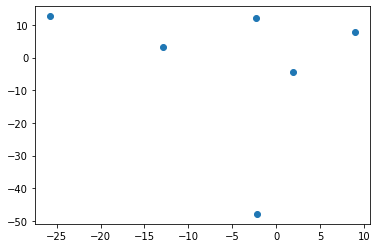

In [632]:
plt.scatter(data_new[:,0],data_new[:,1]) # 特征坐标点可视化

In [633]:
x_coord,y_coord = data_new[:,0],data_new[:,1]

In [646]:
x_min,y_min,x_max,y_max = min(x_coord),min(y_coord),max(x_coord),max(y_coord)

In [647]:
x_pixel = (1 + 8*((x_coord - x_min))/(x_max - x_min))  # 进行归一化，调整坐标范围，不出现负值
y_pixel = (1 + 8*((y_coord - y_min))/(y_max - y_min)) 

In [648]:
round_x_pixel = np.array([int(np.round(x)) for x in x_pixel]) #坐标点取整
round_y_pixel = np.array([int(np.round(y)) for y in y_pixel])

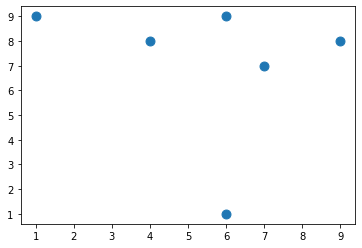

In [649]:
plt.scatter(round_x_pixel,round_y_pixel,s=80)

In [650]:
data = pd.read_excel('Chinese Coal data for coke quality prediction_total table (2026.2.19).xlsx') 

In [651]:
cols = ['Mad','Ad','Vdaf','St,d','G','Y']
data_selected = data[cols]
#data = data_selected.dropna()
imputer = KNNImputer(n_neighbors=7)
data = imputer.fit_transform(data_selected)
data = pd.DataFrame(data, columns=cols)

In [652]:
data

,Mad,Ad,Vdaf,"St,d",G,Y
0,0.72,10.50,25.82,0.490000,89.65,24.50
1,0.68,10.45,24.24,0.410000,87.35,17.00
2,0.70,9.28,22.78,1.670000,83.00,21.50
3,0.94,9.65,30.47,0.370000,89.80,19.50
4,1.09,8.78,31.52,0.360000,88.60,19.50
...,...,...,...,...,...,...
843,2.18,9.48,31.34,0.530000,90.00,17.51
844,0.26,9.12,18.61,1.432857,74.00,10.00
845,0.50,10.13,20.47,1.261429,79.00,16.00
846,0.60,10.72,26.82,0.934286,90.00,21.00


In [653]:
data = (data - data.min()) / (data.max() - data.min()) #normalize the data

In [654]:
# 训练并检测异常值
outliers = iso.fit_predict(data)

# 删除异常值
data_clean = data[outliers == 1]

print("原始数据数量:", len(data))
print("删除异常值后:", len(data_clean))
print("删除异常值数量:", len(data) - len(data_clean))

# 更新data
data = data_clean

原始数据数量: 848
删除异常值后: 805
删除异常值数量: 43


In [655]:
data = pd.DataFrame(data)

In [667]:
sample = data.iloc[:,:].values[60]

In [668]:
sample

array([0.20387818, 0.35343384, 0.86035706, 0.07110092, 0.70604082,
       0.36125139])

In [671]:
def save_coal_image():
    for i in range(0,data.iloc[:,:].values.shape[0]):
        sample = data.iloc[:,:].values[i]
        zero = np.zeros((9,9)) #创建空矩阵
        k = 0
        for l,m in zip(round_x_pixel,round_y_pixel): #遍历特征点在图上的坐标
            if k<sample.shape[0]:
                zero[m-1][l-1] = sample[k] #将特征数值映射到图像上去
                k+=1
        plt.figure(figsize=(5,5)) 
        ax = sns.heatmap(zero, center=0,vmin=0.0, vmax=1,cbar=False) #创建热力图，颜色深浅代表值的大小
        ax.set(xticklabels=[])
        ax.set(yticklabels=[])
        ax.tick_params(left=False) 
        ax.tick_params(bottom=False) 
        plt.gca().xaxis.set_major_locator(plt.NullLocator())
        plt.gca().yaxis.set_major_locator(plt.NullLocator())
        plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0, hspace = 0, wspace = 0)
        plt.margins(0,0)
        file_name = 'Coal_images(2026_03_15)_coals/' + str(i) + '.jpg' #保存图像数据
        print(file_name)
        plt.savefig(file_name, dpi=50, pad_inches = 0)

Coal_images(2026_03_15)_coals/0.jpg
Coal_images(2026_03_15)_coals/1.jpg
Coal_images(2026_03_15)_coals/2.jpg
Coal_images(2026_03_15)_coals/3.jpg
Coal_images(2026_03_15)_coals/4.jpg
Coal_images(2026_03_15)_coals/5.jpg
Coal_images(2026_03_15)_coals/6.jpg
Coal_images(2026_03_15)_coals/7.jpg
Coal_images(2026_03_15)_coals/8.jpg
Coal_images(2026_03_15)_coals/9.jpg
Coal_images(2026_03_15)_coals/10.jpg
Coal_images(2026_03_15)_coals/11.jpg
Coal_images(2026_03_15)_coals/12.jpg
Coal_images(2026_03_15)_coals/13.jpg
Coal_images(2026_03_15)_coals/14.jpg
Coal_images(2026_03_15)_coals/15.jpg
Coal_images(2026_03_15)_coals/16.jpg
Coal_images(2026_03_15)_coals/17.jpg
Coal_images(2026_03_15)_coals/18.jpg
Coal_images(2026_03_15)_coals/19.jpg


/tmp/ipykernel_342913/418779037.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(figsize=(5,5))


Coal_images(2026_03_15)_coals/20.jpg
Coal_images(2026_03_15)_coals/21.jpg
Coal_images(2026_03_15)_coals/22.jpg
Coal_images(2026_03_15)_coals/23.jpg
Coal_images(2026_03_15)_coals/24.jpg
Coal_images(2026_03_15)_coals/25.jpg
Coal_images(2026_03_15)_coals/26.jpg
Coal_images(2026_03_15)_coals/27.jpg
Coal_images(2026_03_15)_coals/28.jpg
Coal_images(2026_03_15)_coals/29.jpg
Coal_images(2026_03_15)_coals/30.jpg
Coal_images(2026_03_15)_coals/31.jpg
Coal_images(2026_03_15)_coals/32.jpg
Coal_images(2026_03_15)_coals/33.jpg
Coal_images(2026_03_15)_coals/34.jpg
Coal_images(2026_03_15)_coals/35.jpg
Coal_images(2026_03_15)_coals/36.jpg
Coal_images(2026_03_15)_coals/37.jpg
Coal_images(2026_03_15)_coals/38.jpg
Coal_images(2026_03_15)_coals/39.jpg
Coal_images(2026_03_15)_coals/40.jpg
Coal_images(2026_03_15)_coals/41.jpg
Coal_images(2026_03_15)_coals/42.jpg
Coal_images(2026_03_15)_coals/43.jpg
Coal_images(2026_03_15)_coals/44.jpg
Coal_images(2026_03_15)_coals/45.jpg
Coal_images(2026_03_15)_coals/46.jpg
C

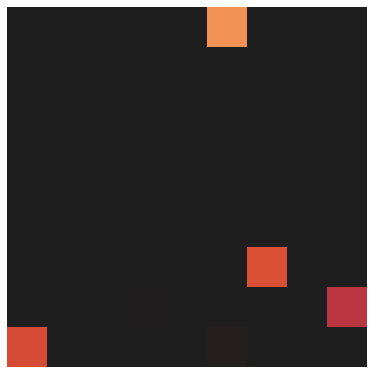

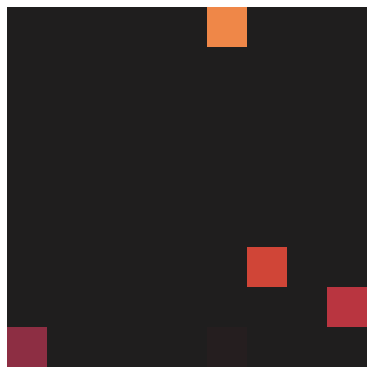

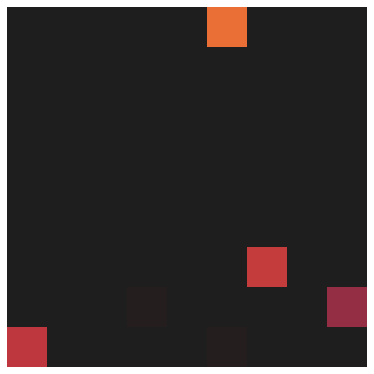

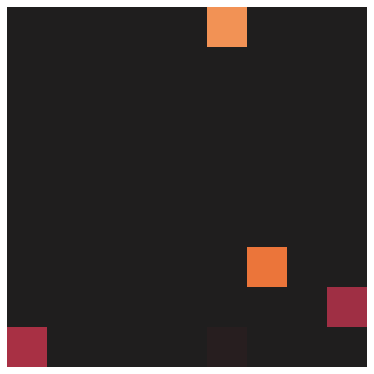

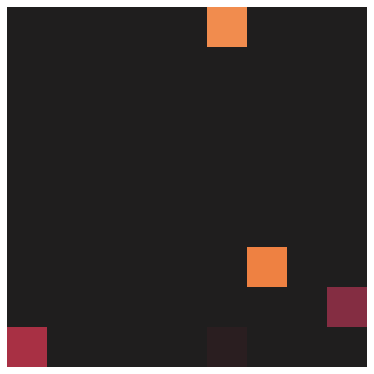

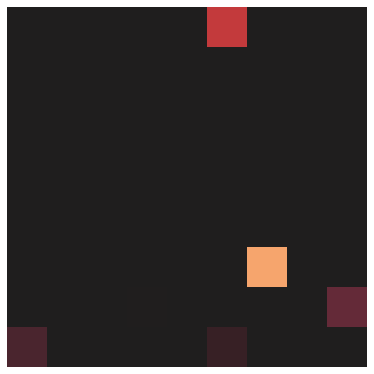

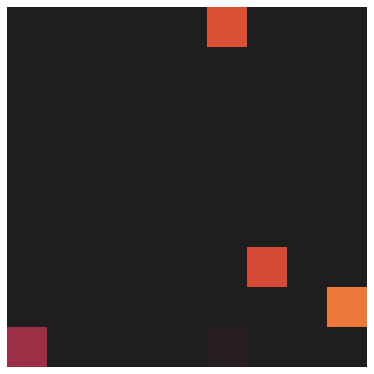

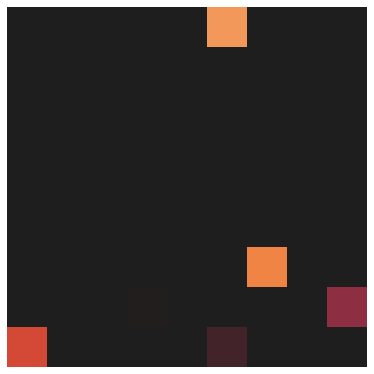

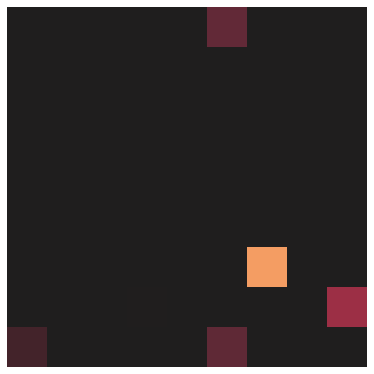

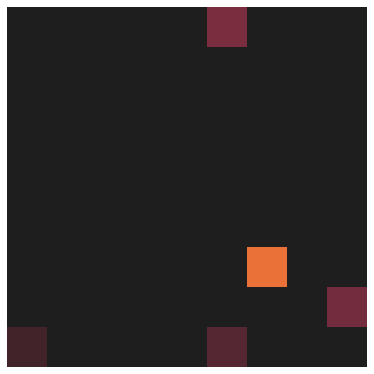

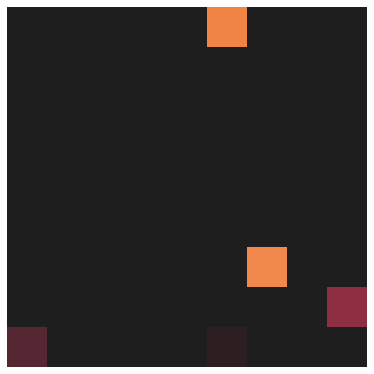

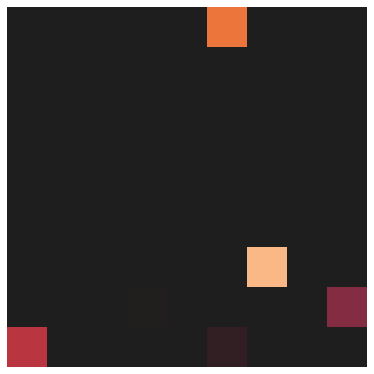

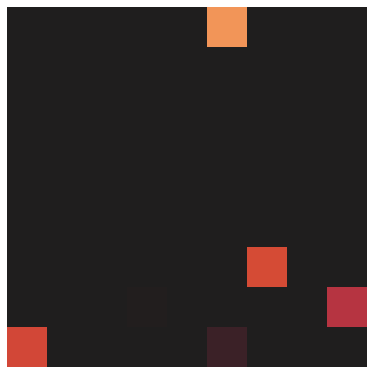

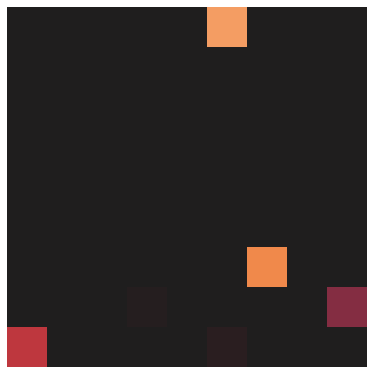

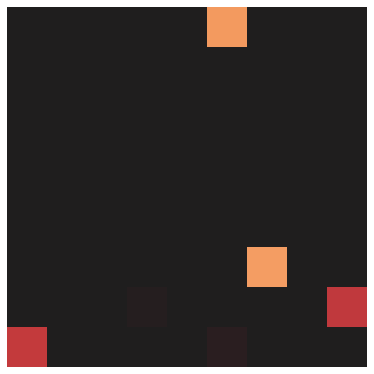

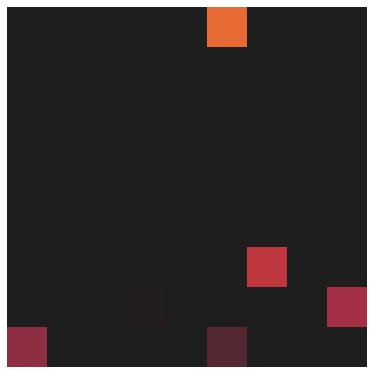

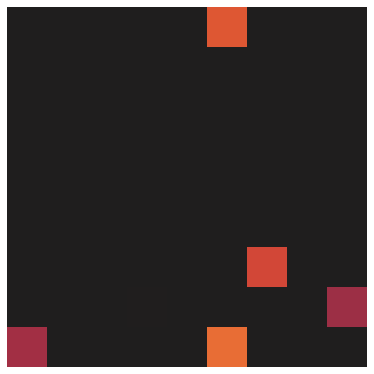

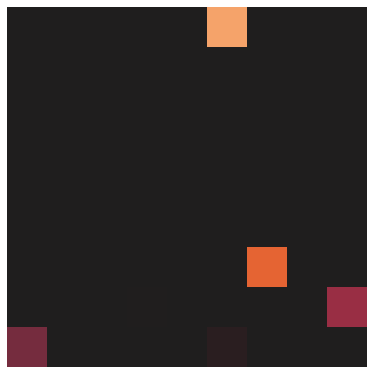

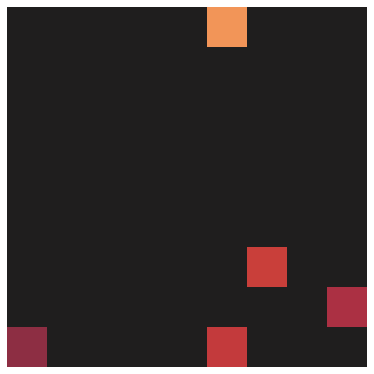

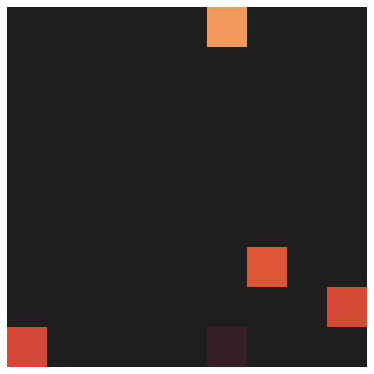

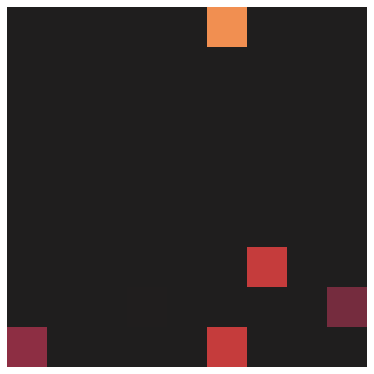

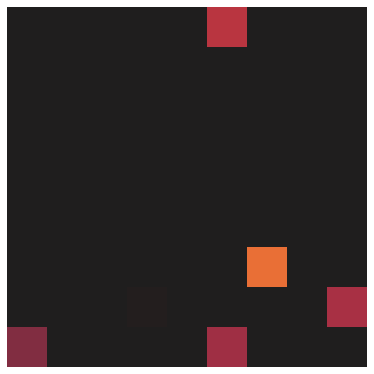

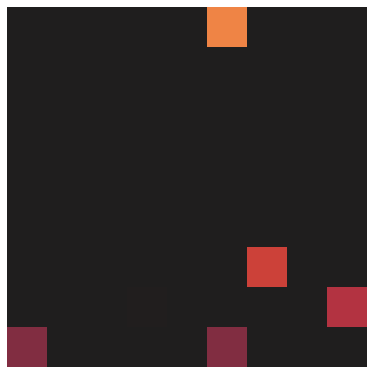

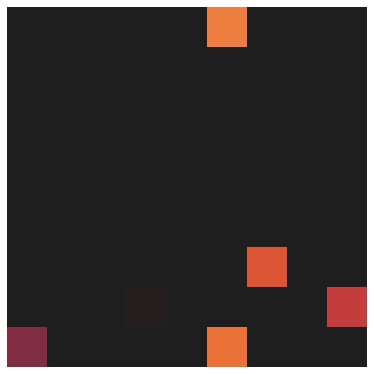

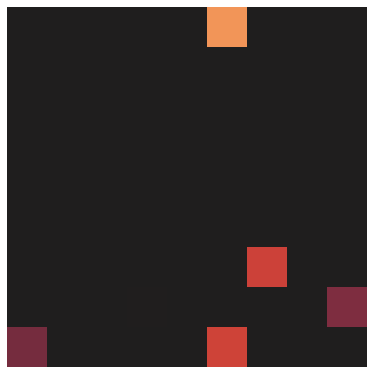

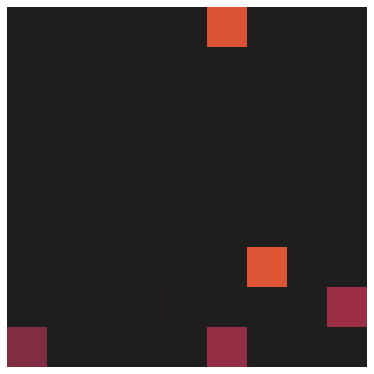

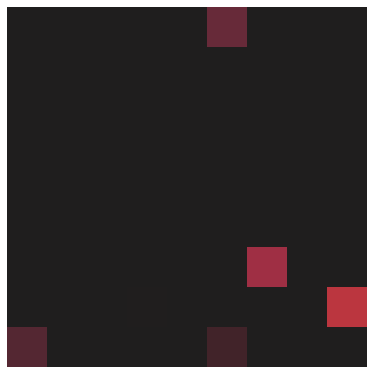

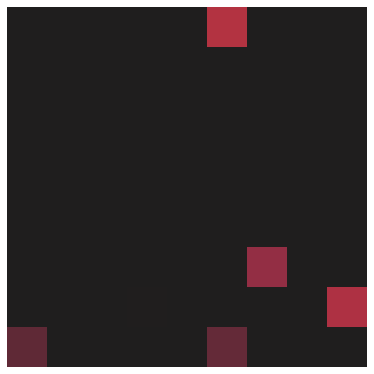

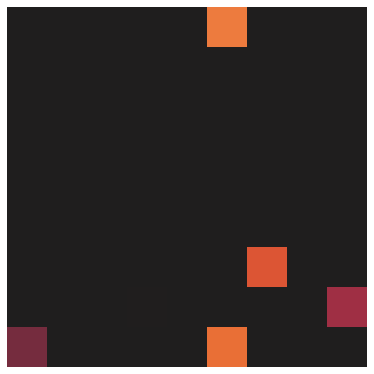

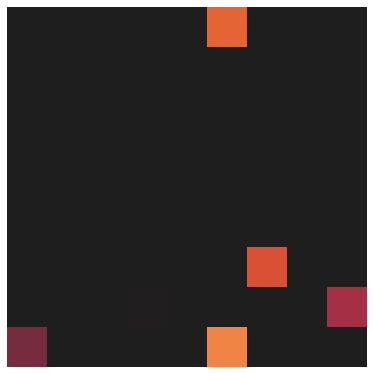

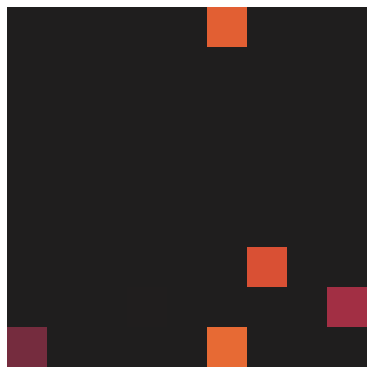

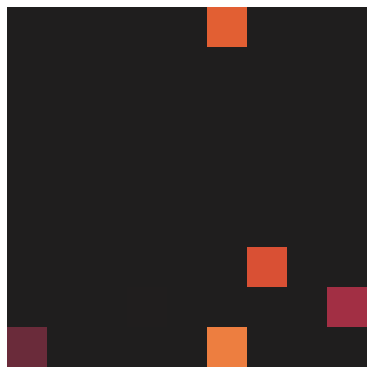

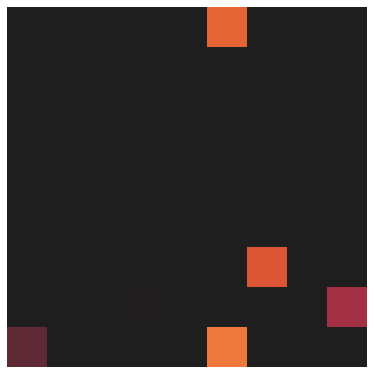

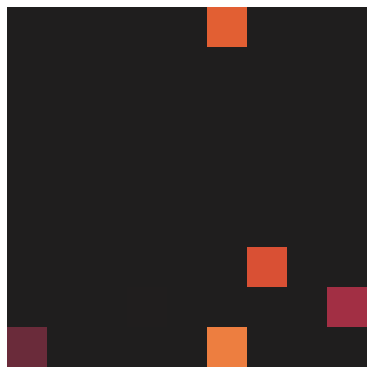

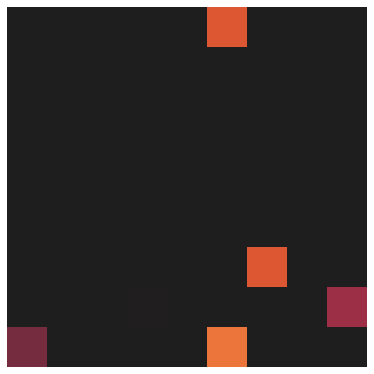

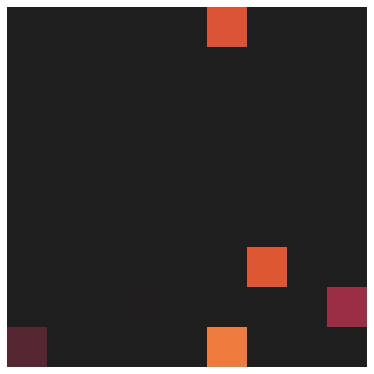

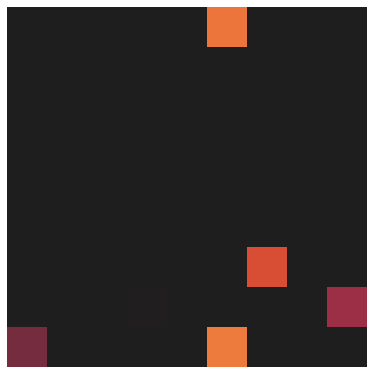

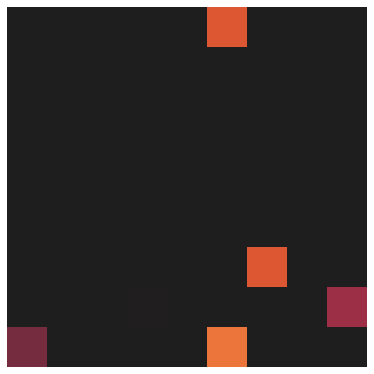

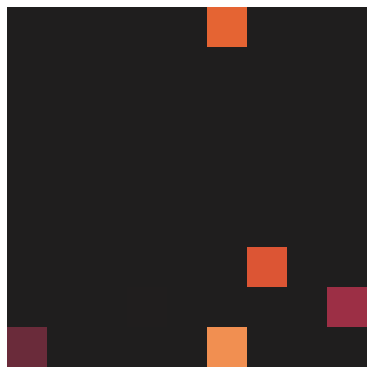

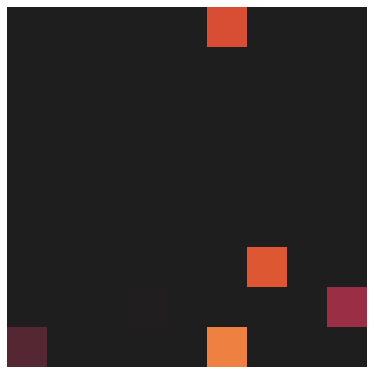

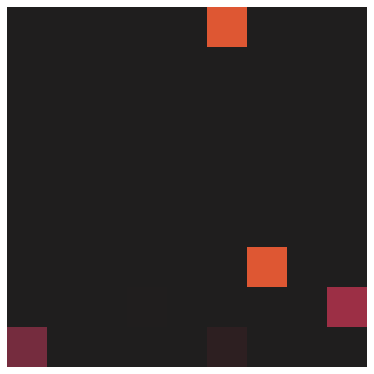

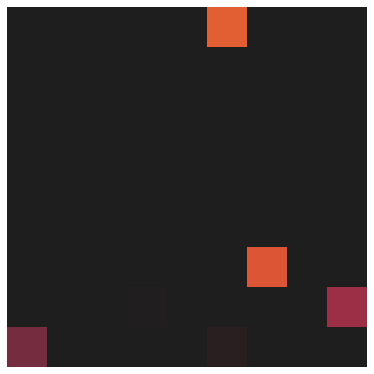

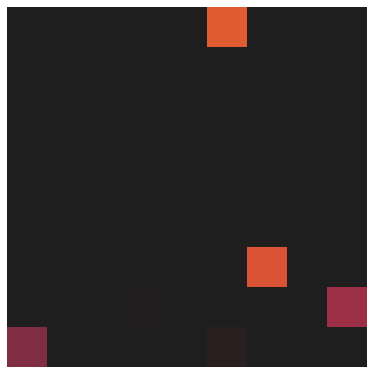

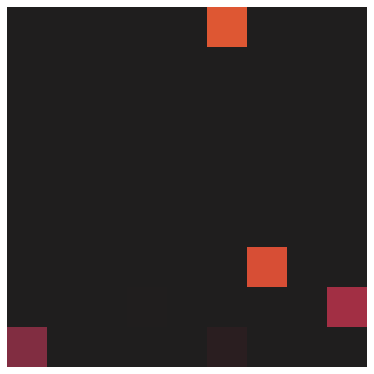

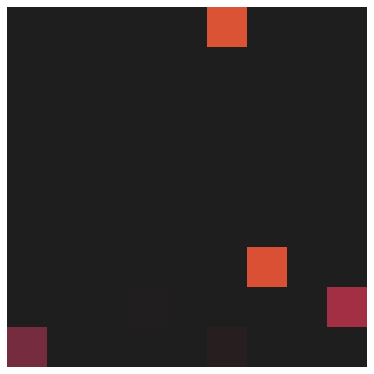

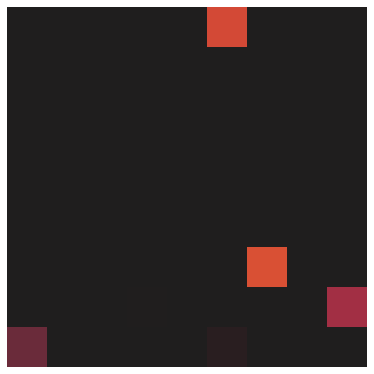

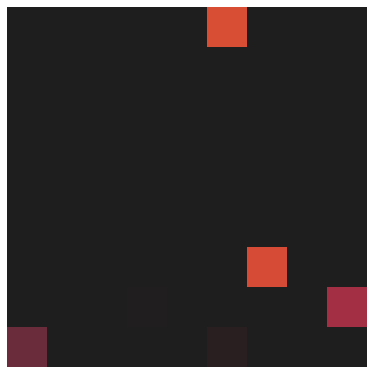

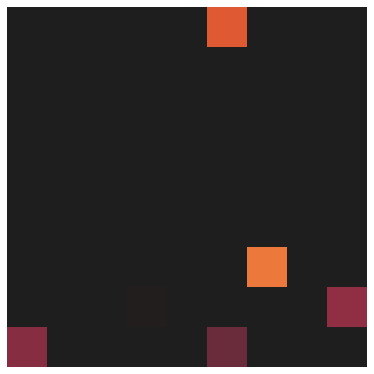

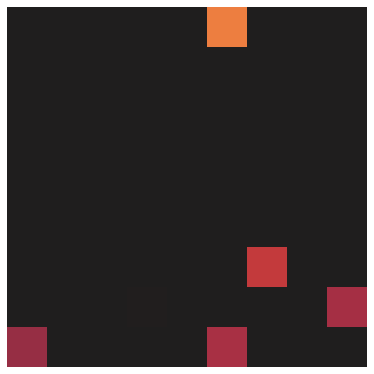

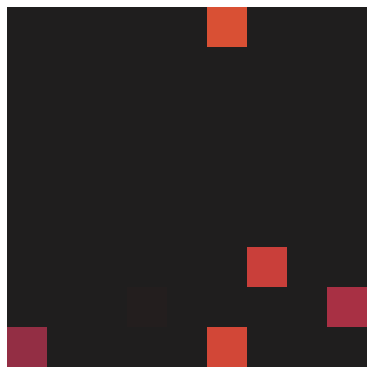

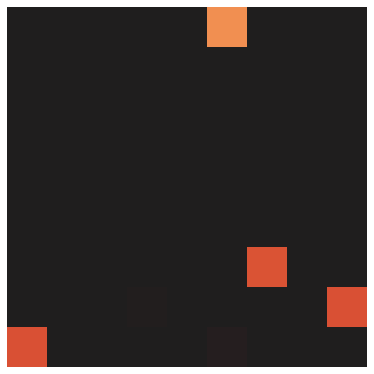

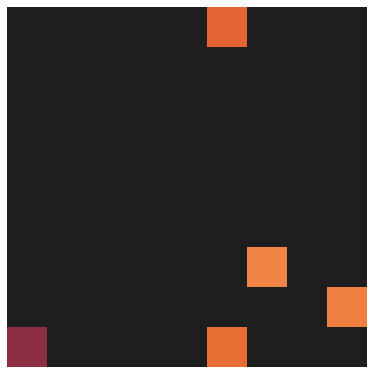

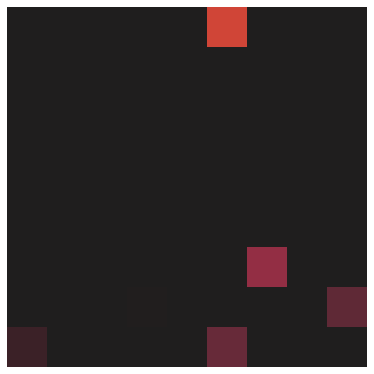

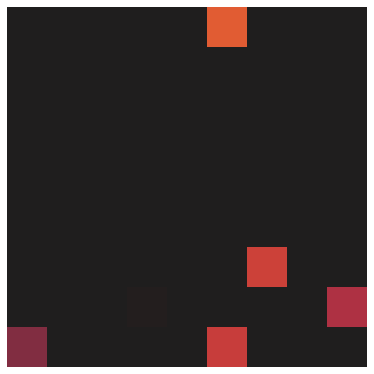

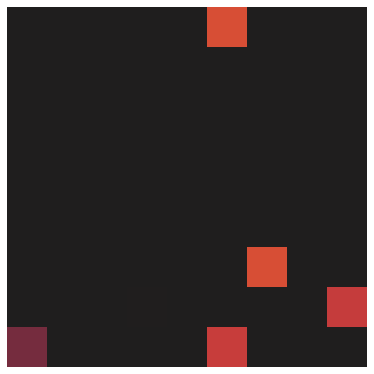

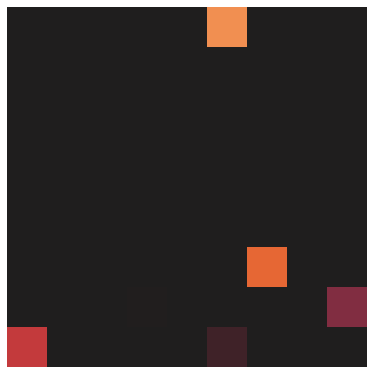

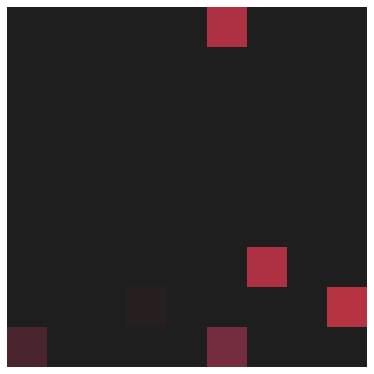

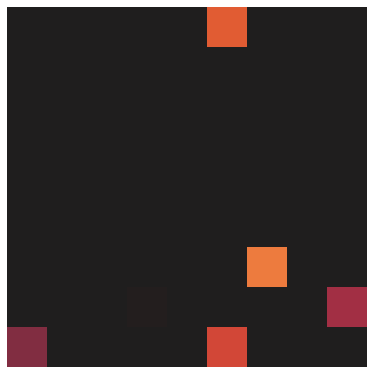

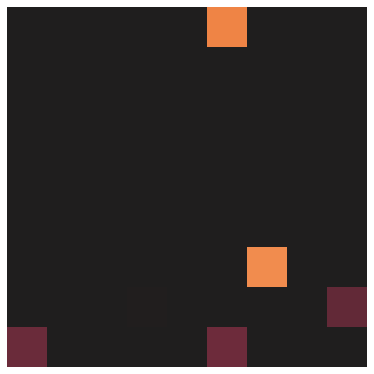

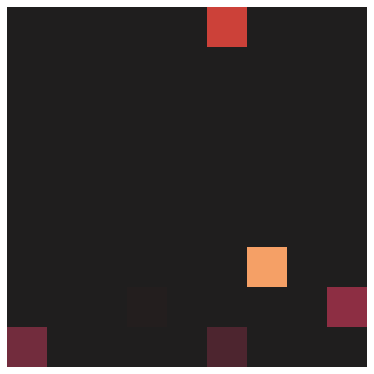

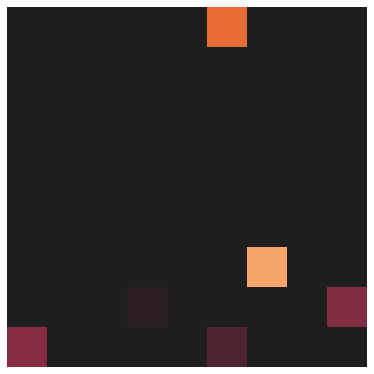

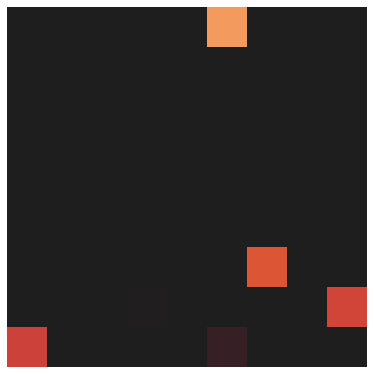

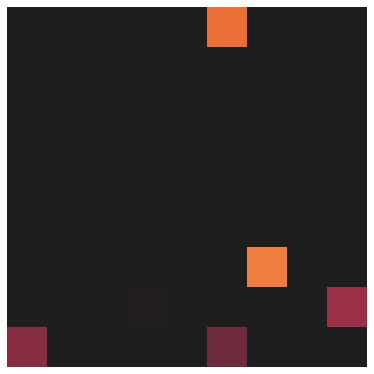

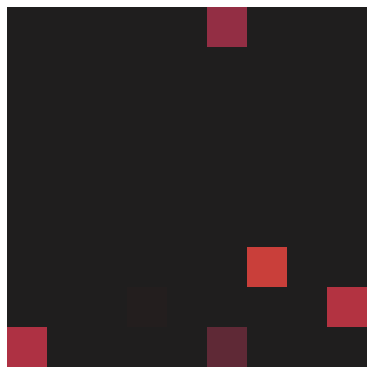

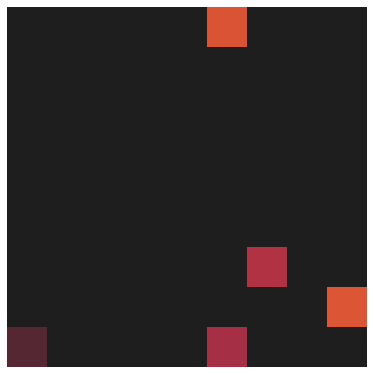

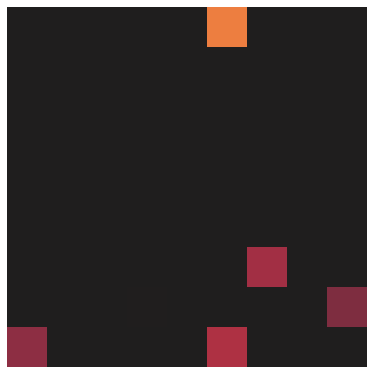

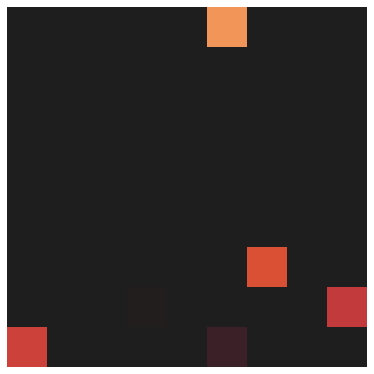

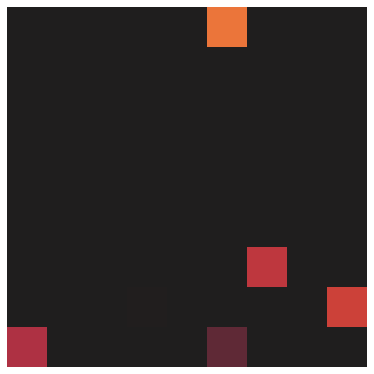

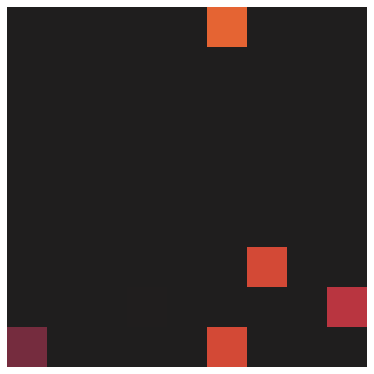

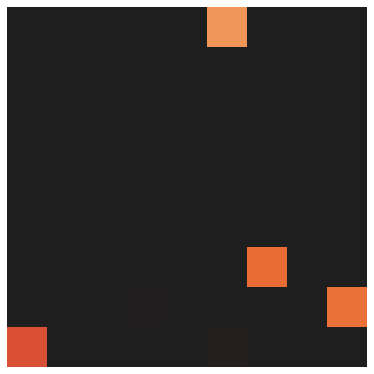

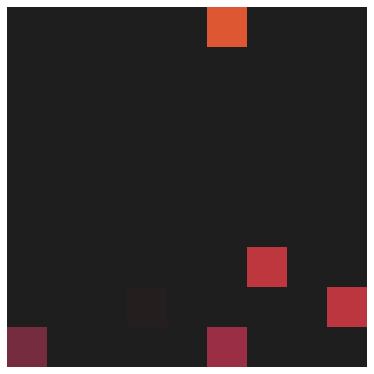

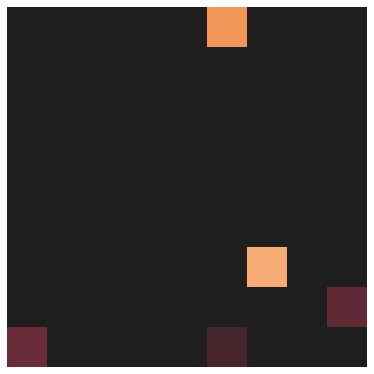

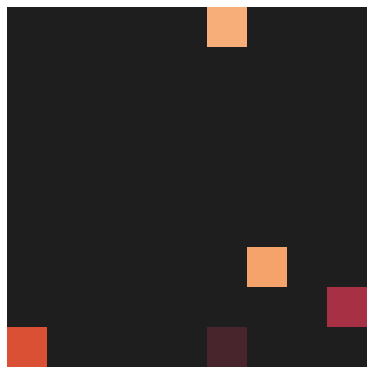

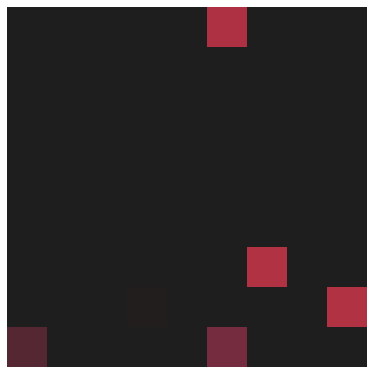

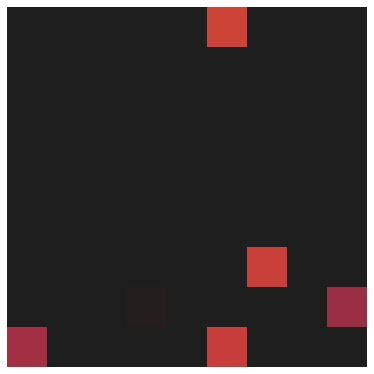

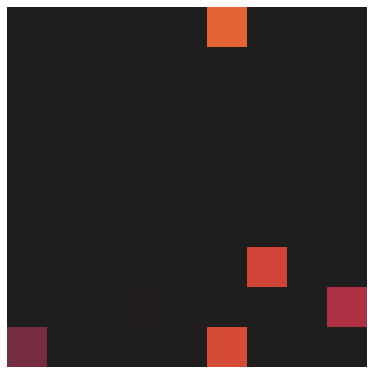

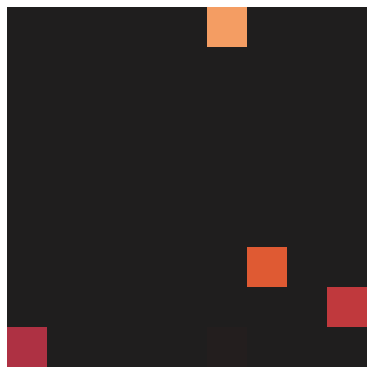

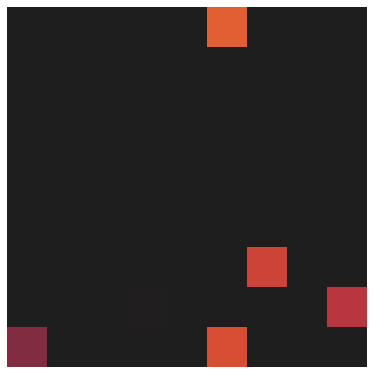

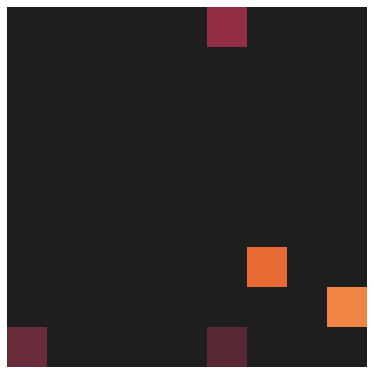

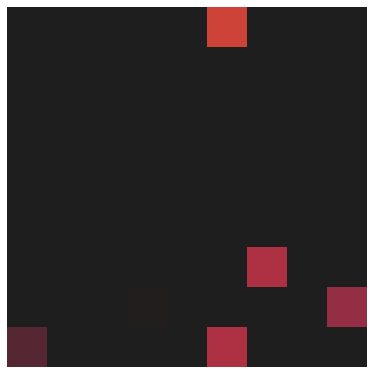

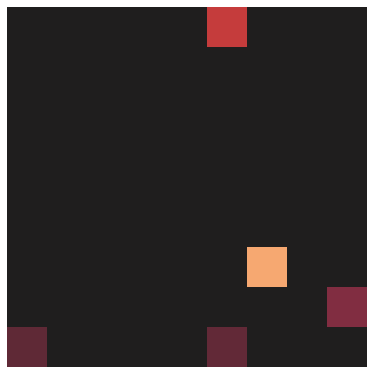

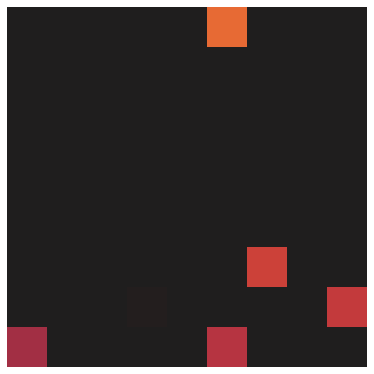

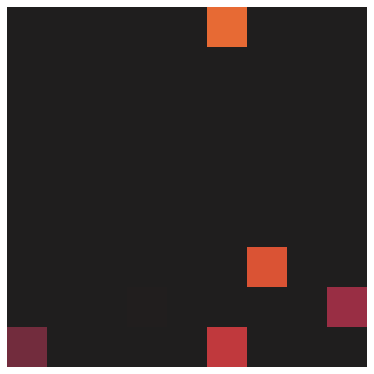

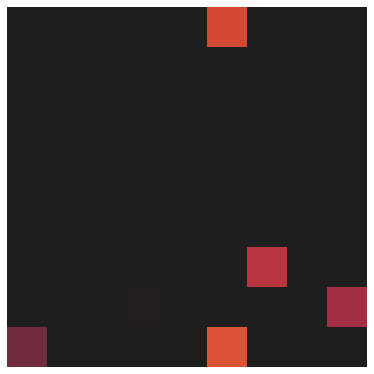

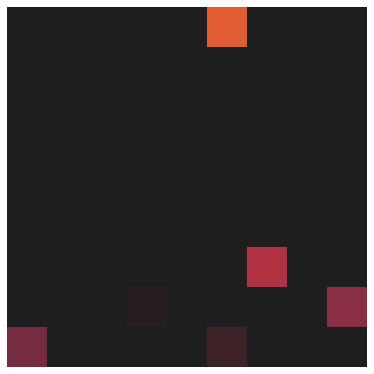

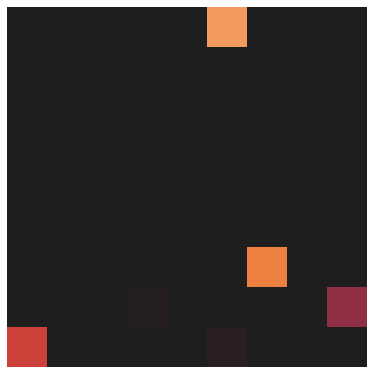

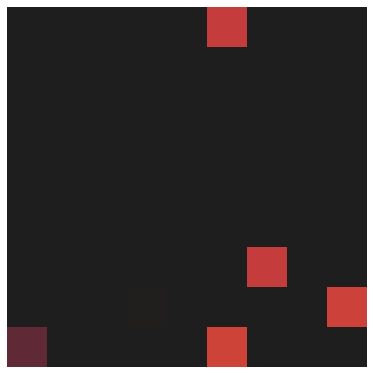

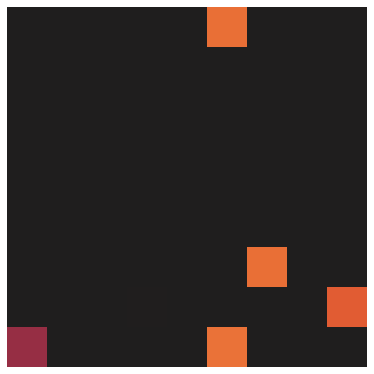

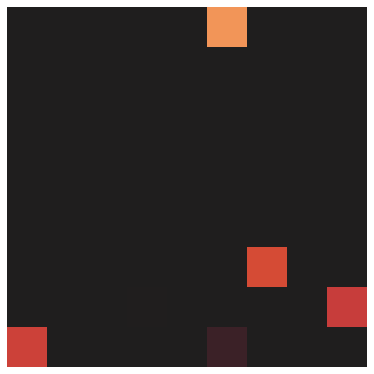

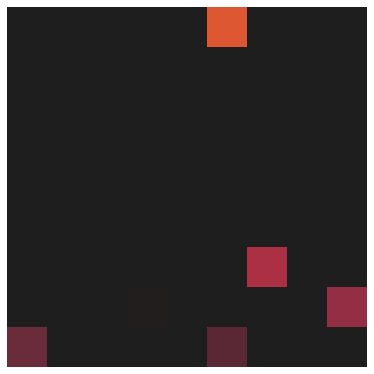

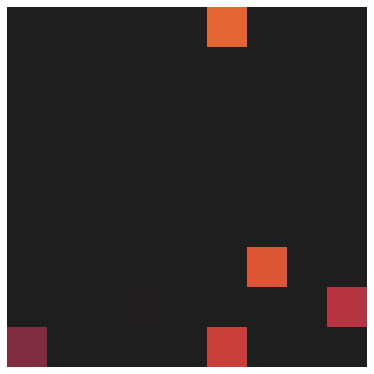

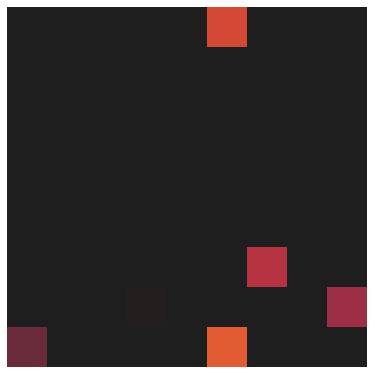

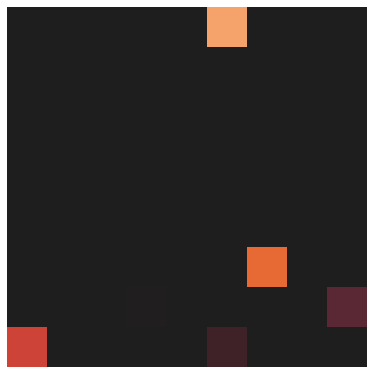

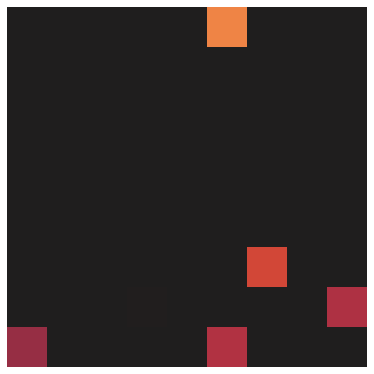

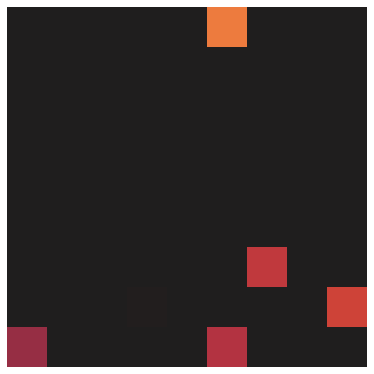

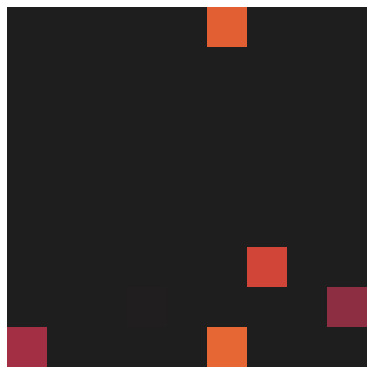

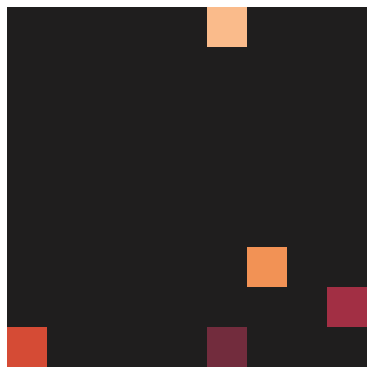

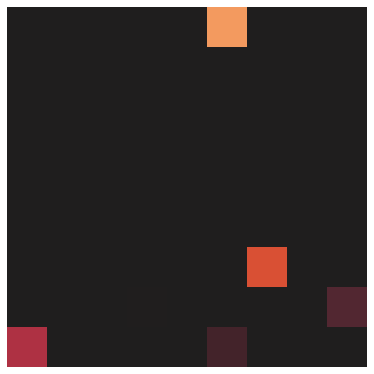

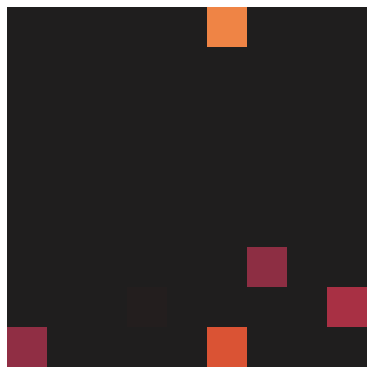

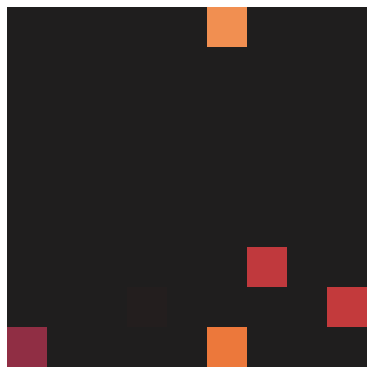

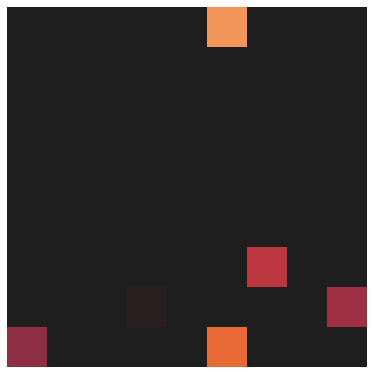

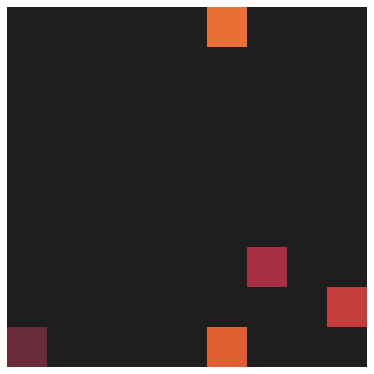

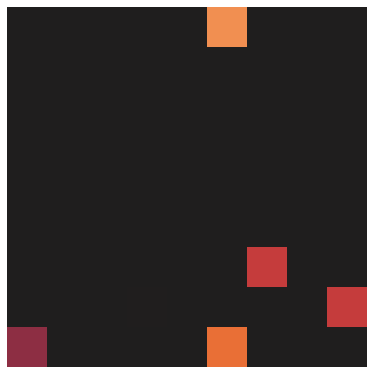

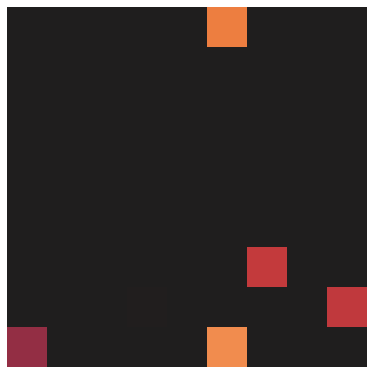

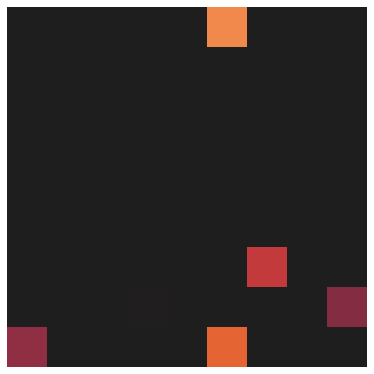

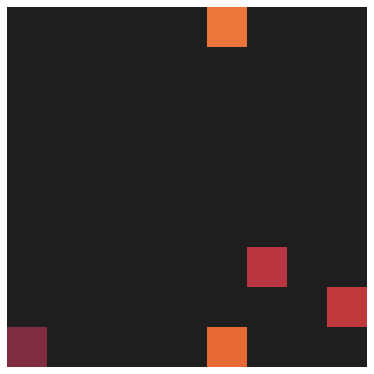

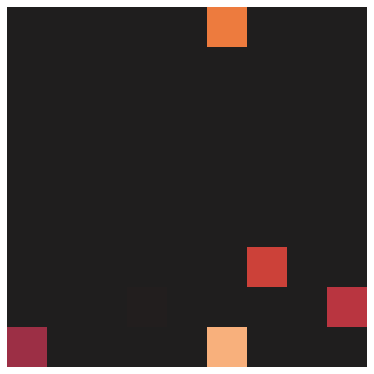

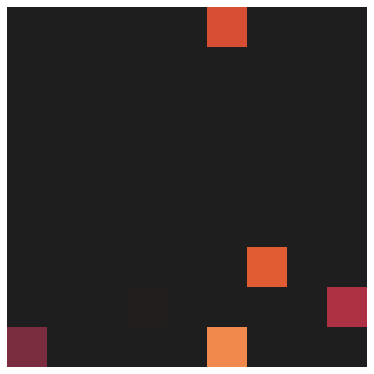

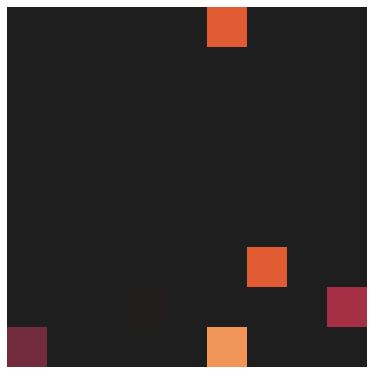

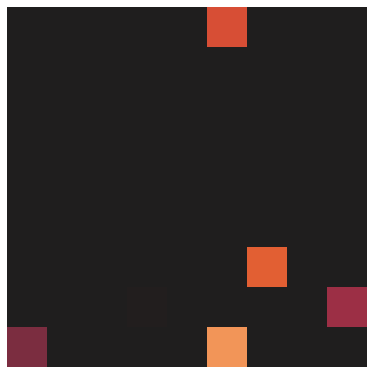

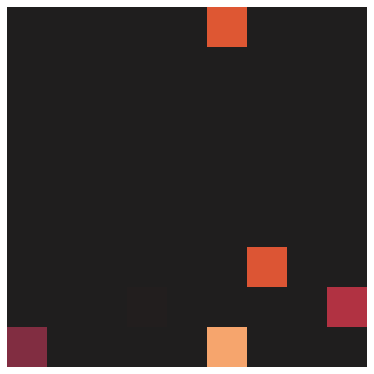

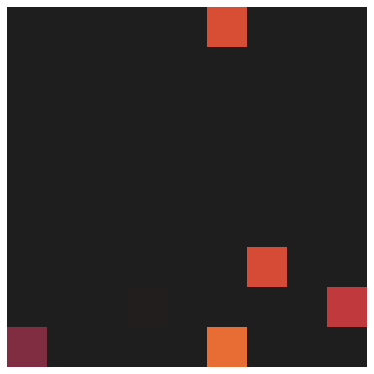

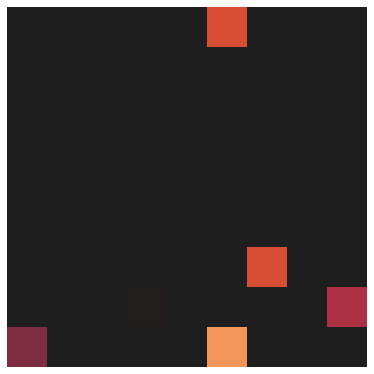

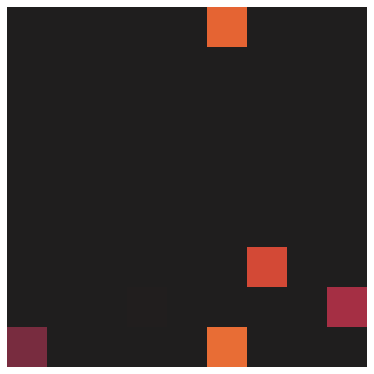

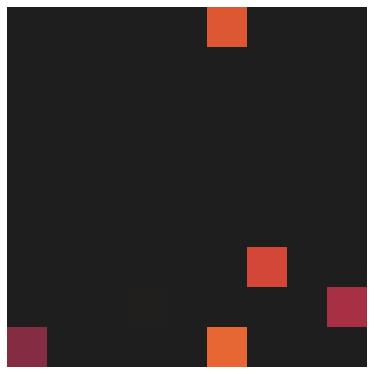

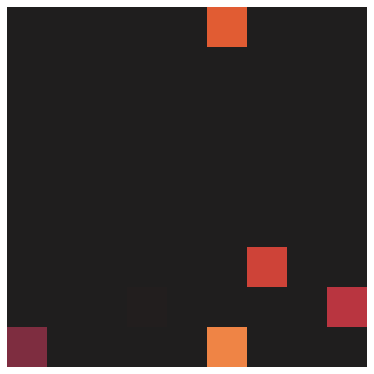

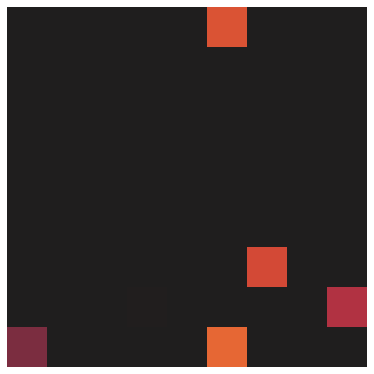

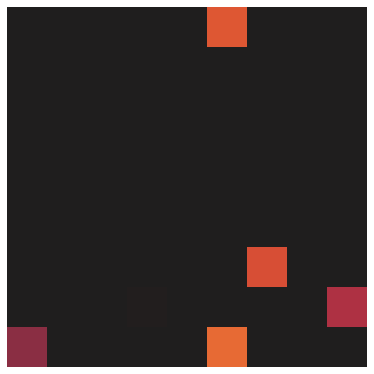

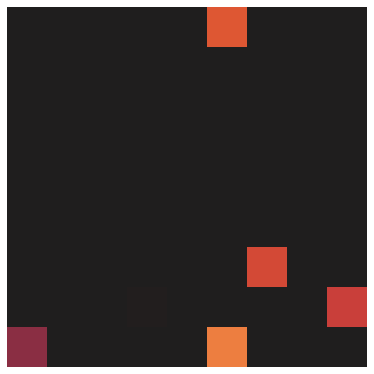

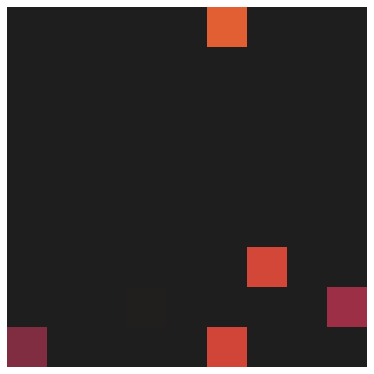

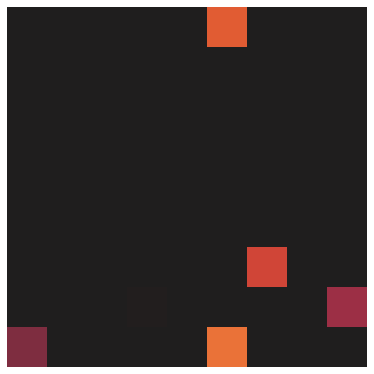

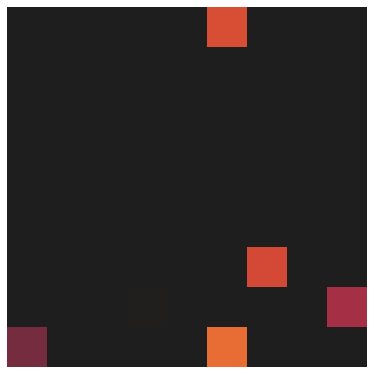

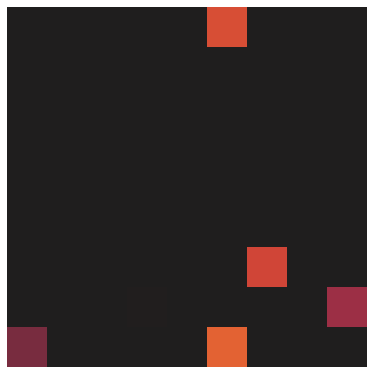

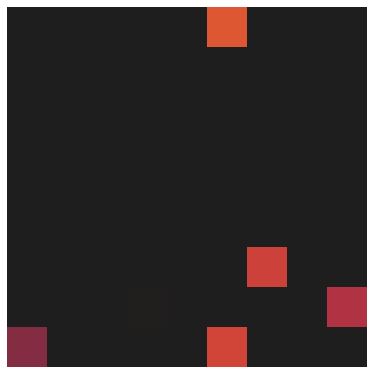

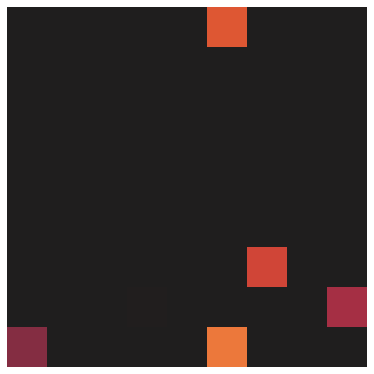

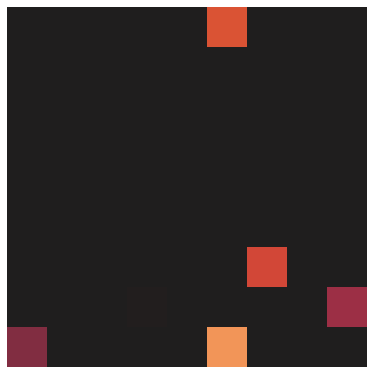

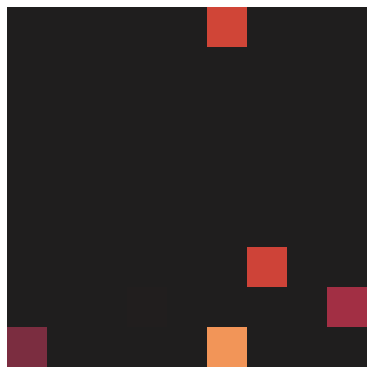

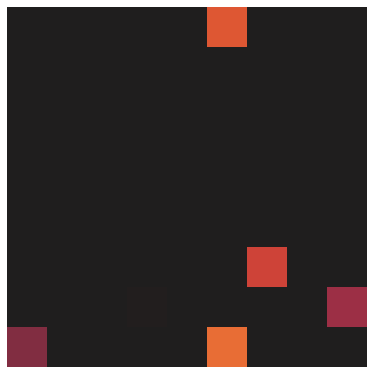

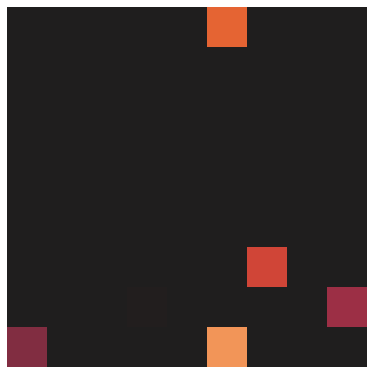

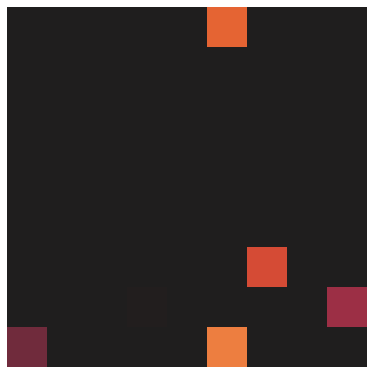

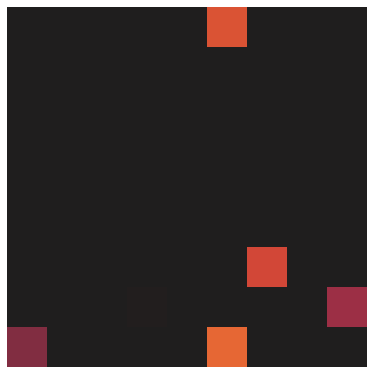

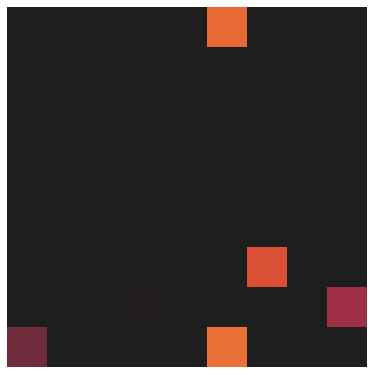

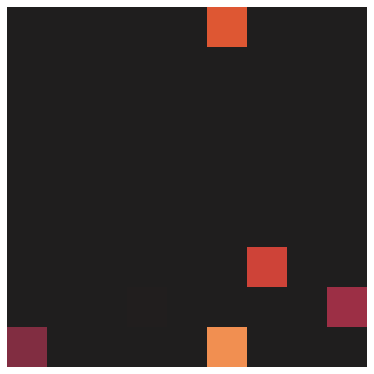

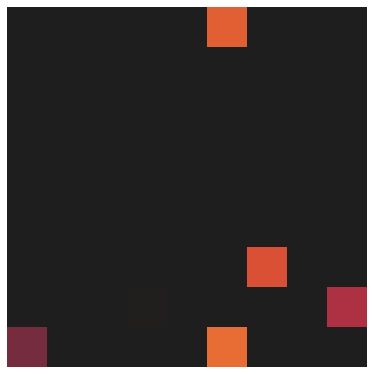

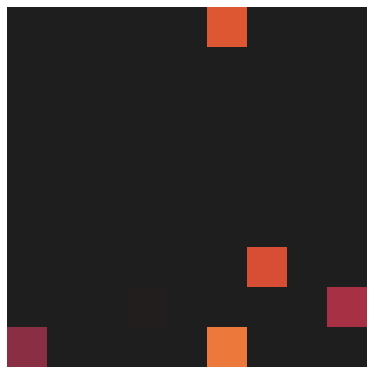

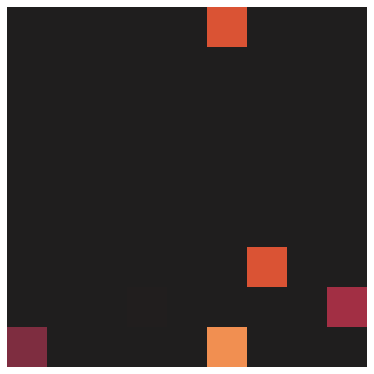

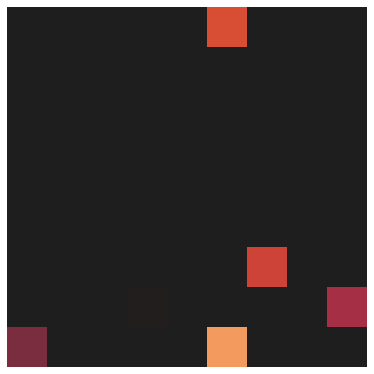

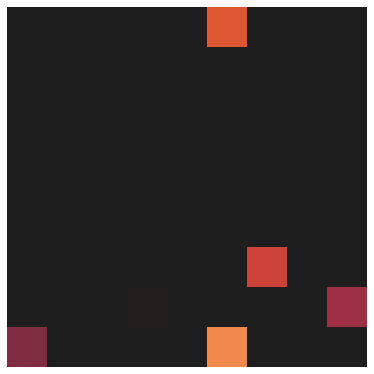

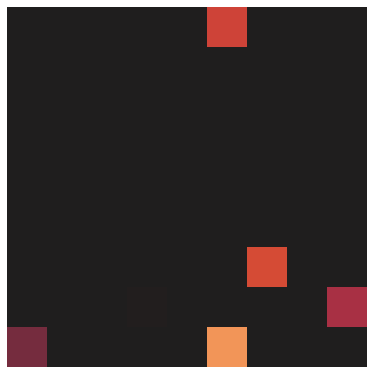

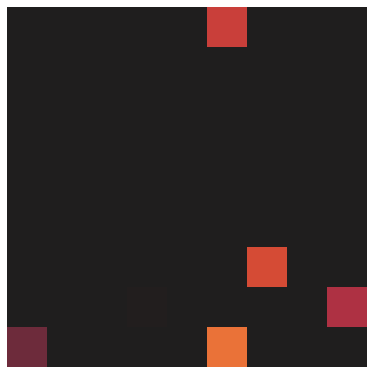

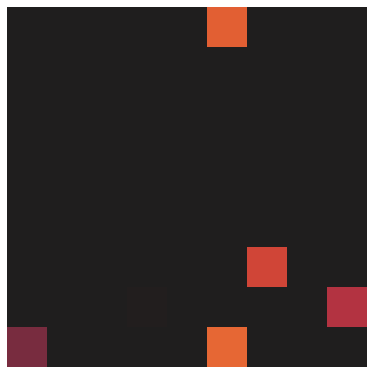

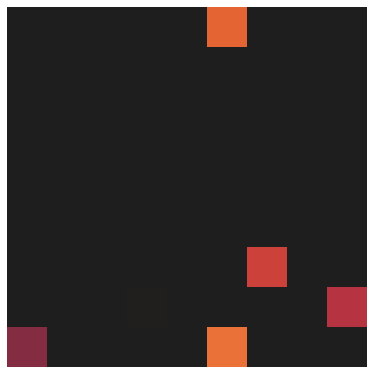

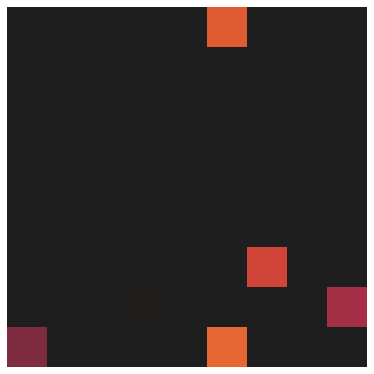

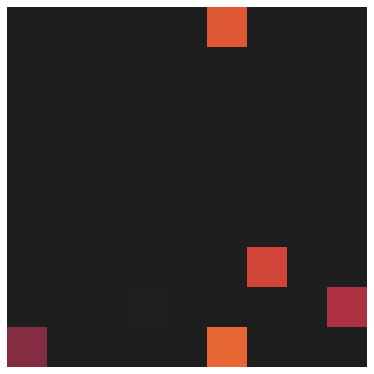

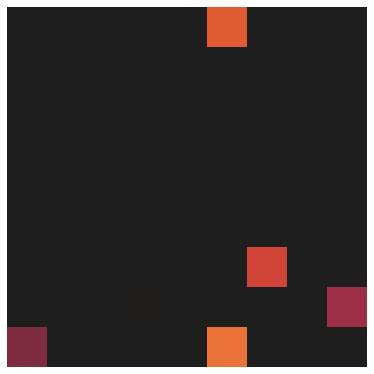

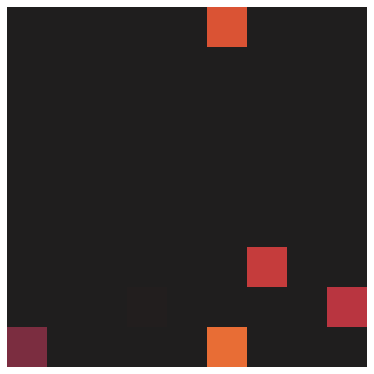

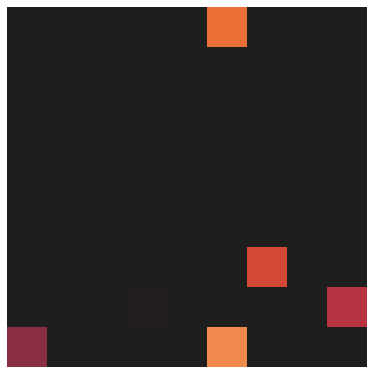

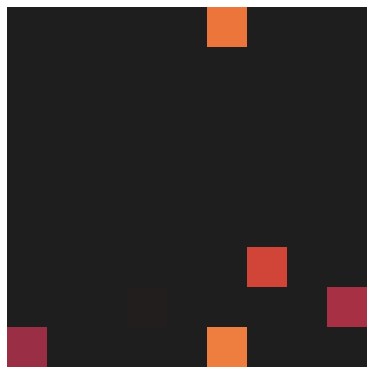

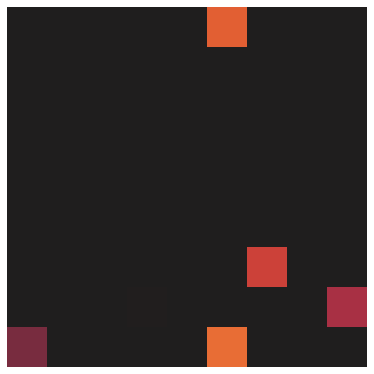

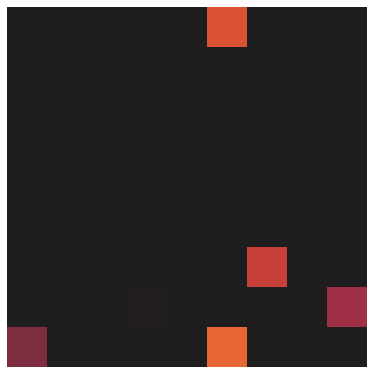

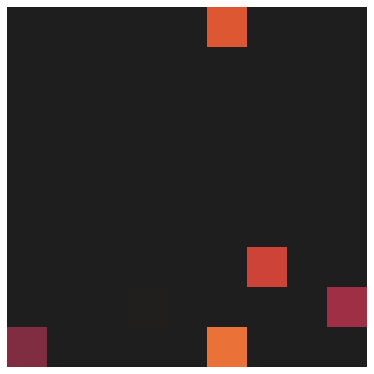

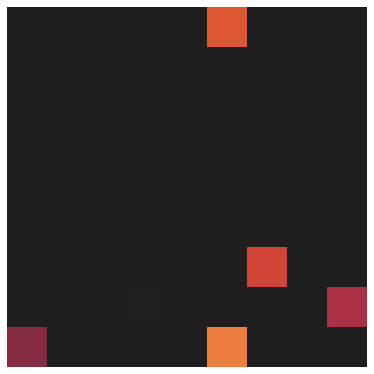

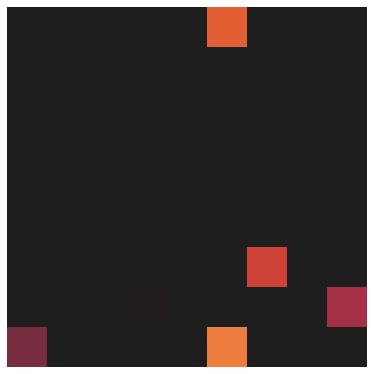

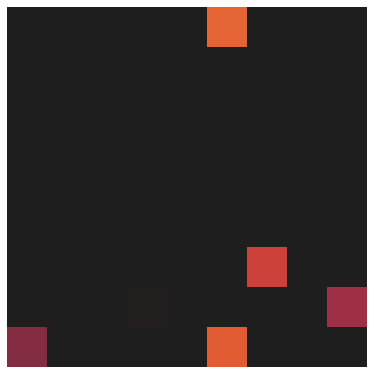

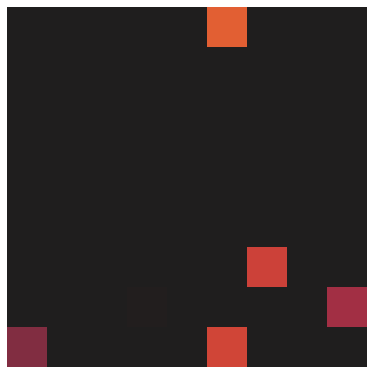

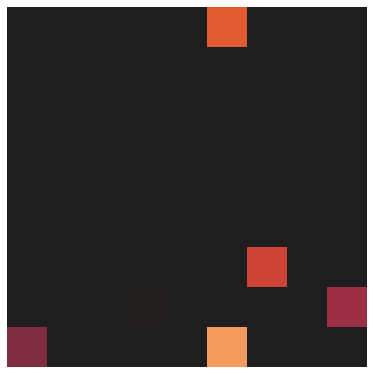

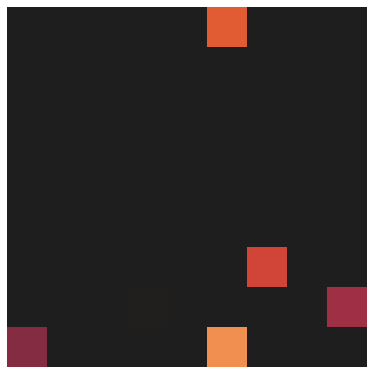

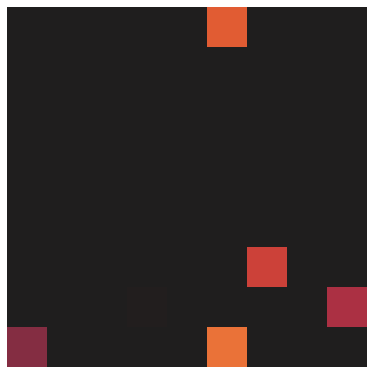

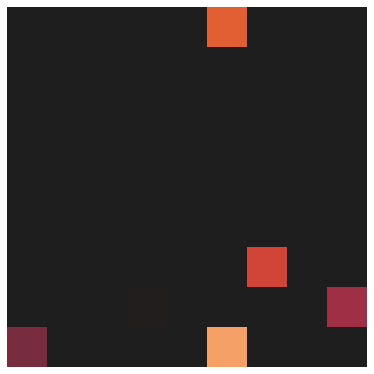

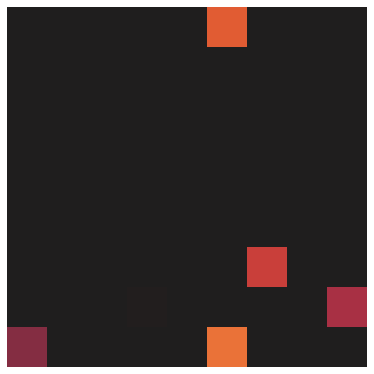

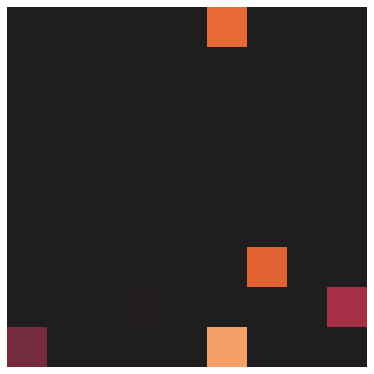

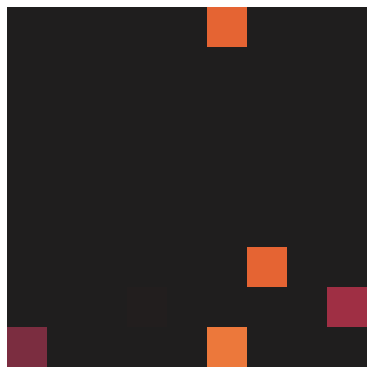

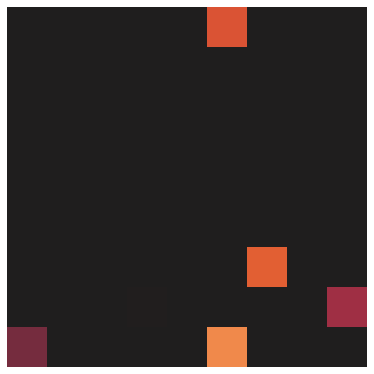

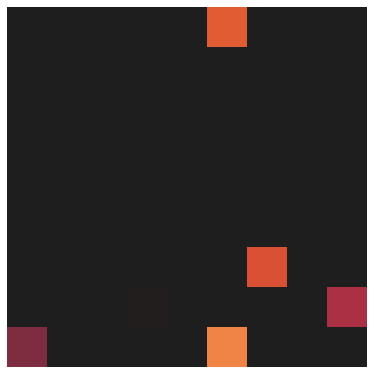

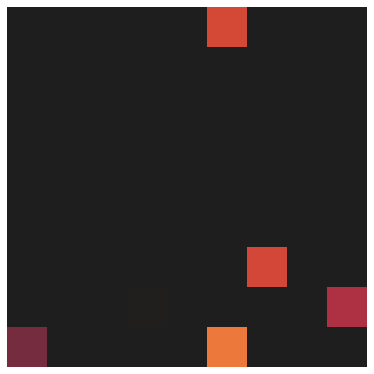

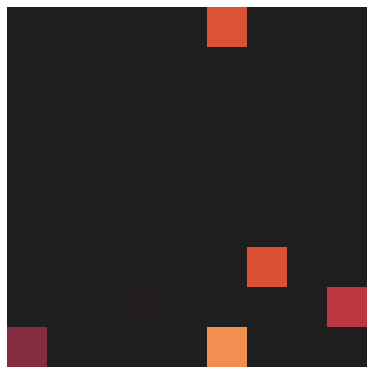

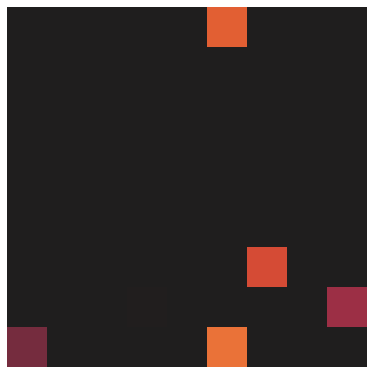

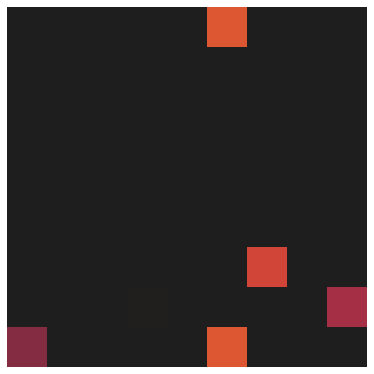

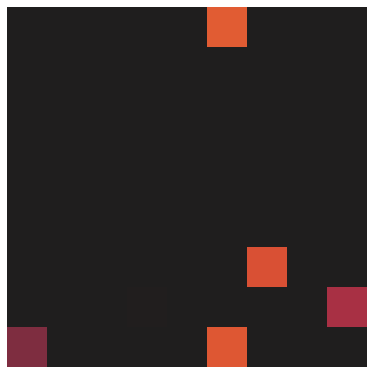

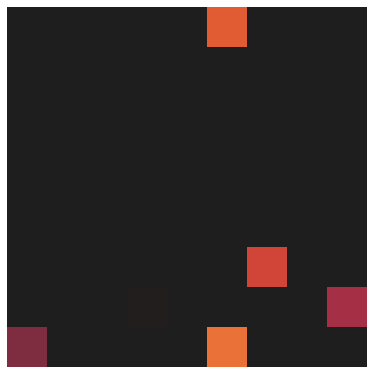

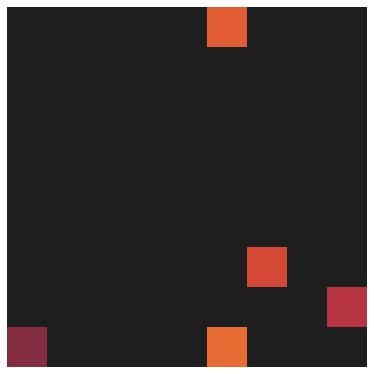

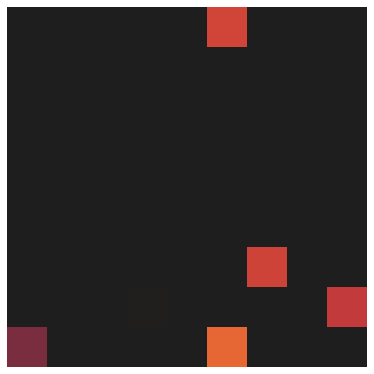

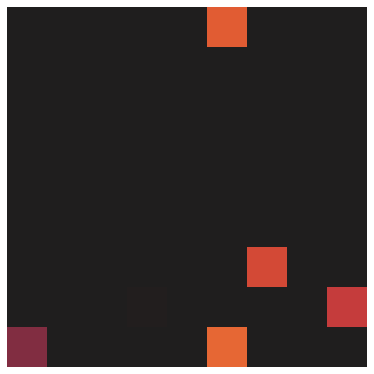

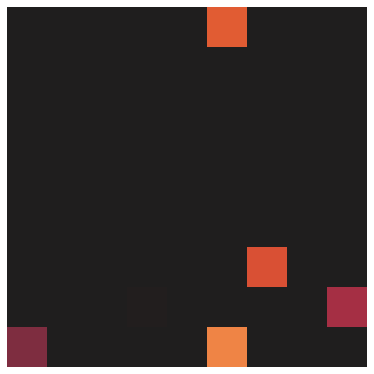

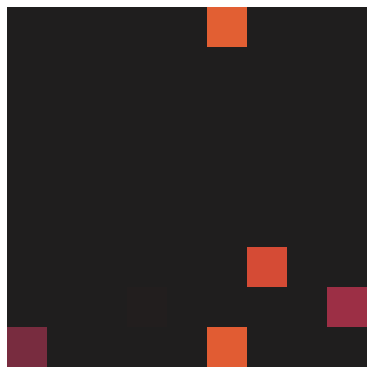

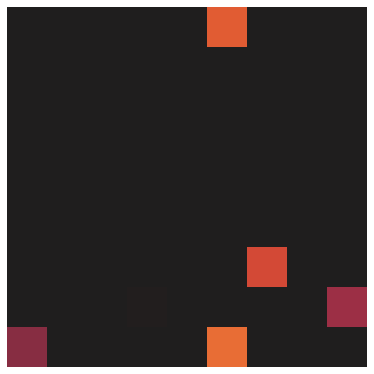

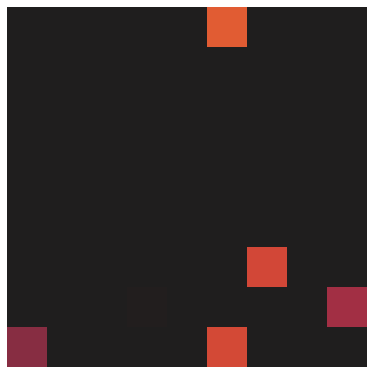

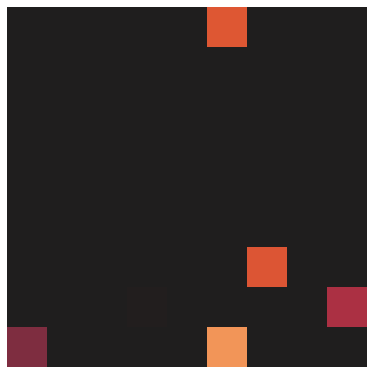

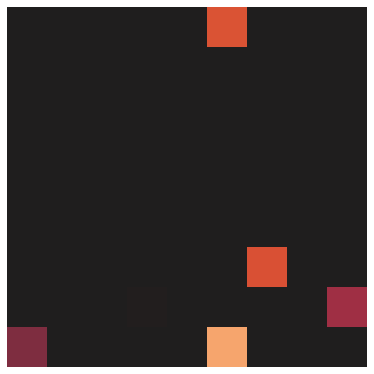

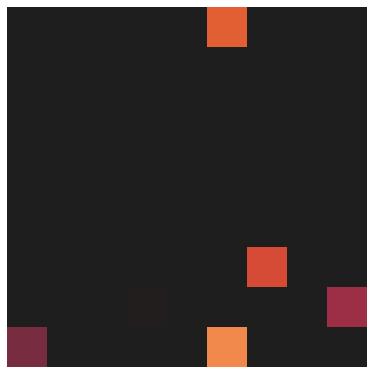

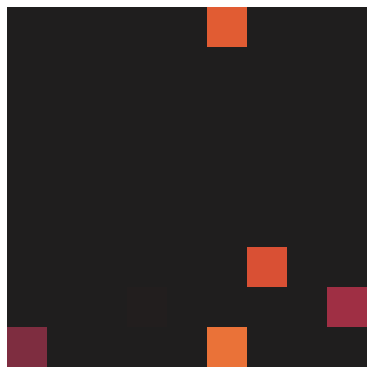

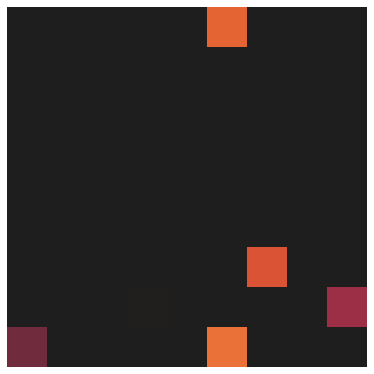

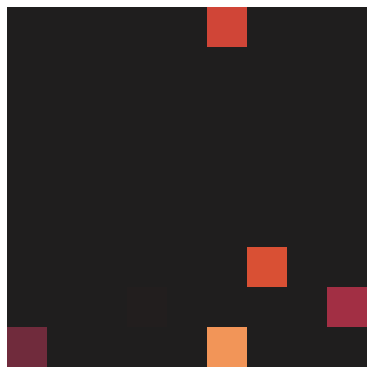

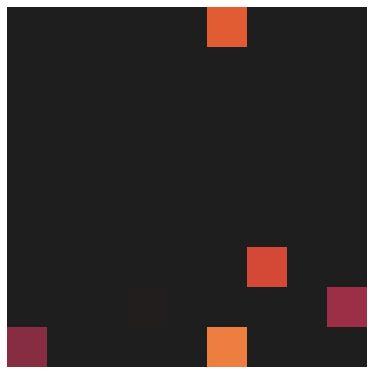

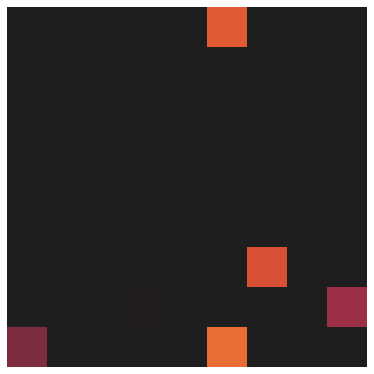

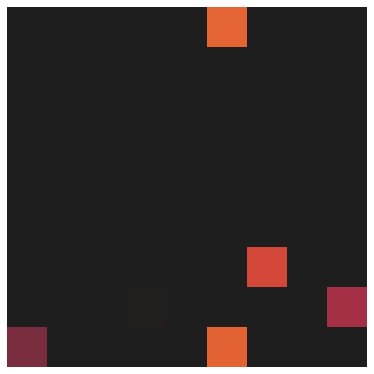

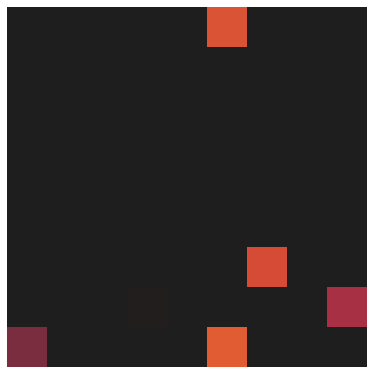

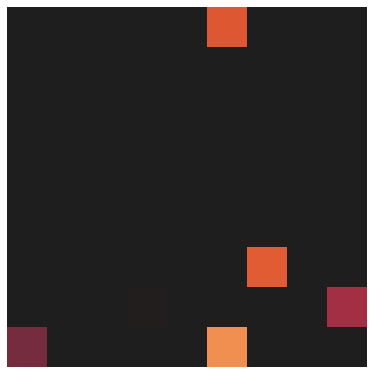

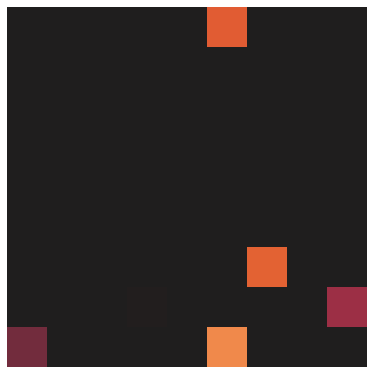

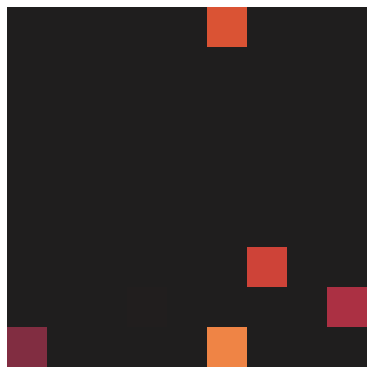

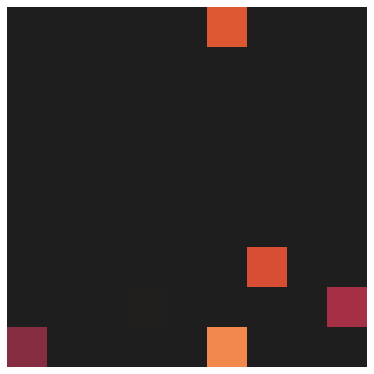

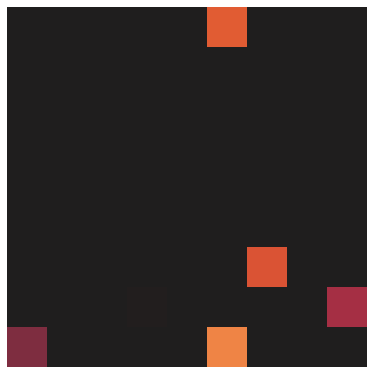

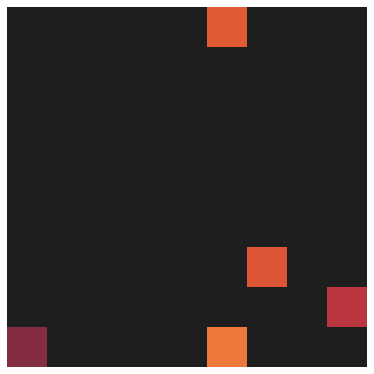

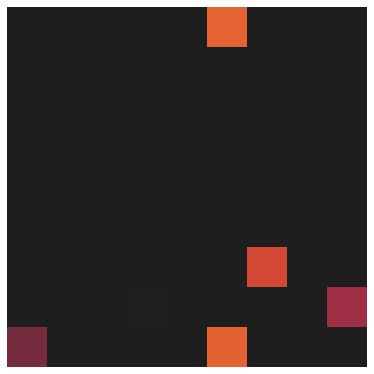

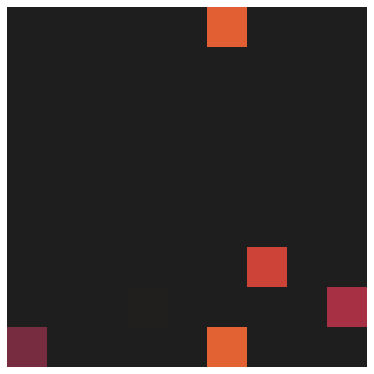

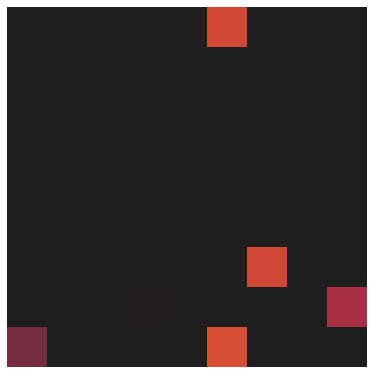

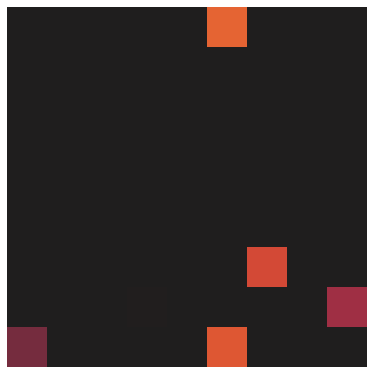

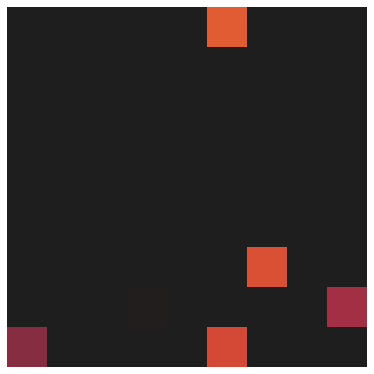

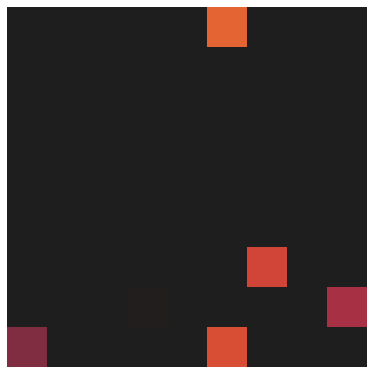

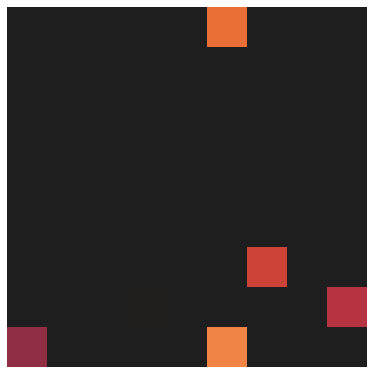

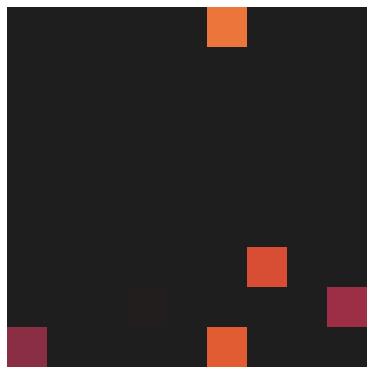

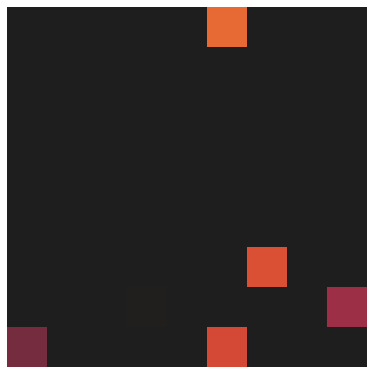

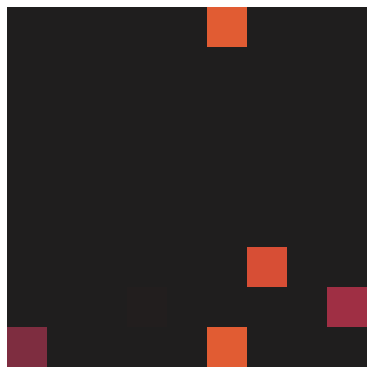

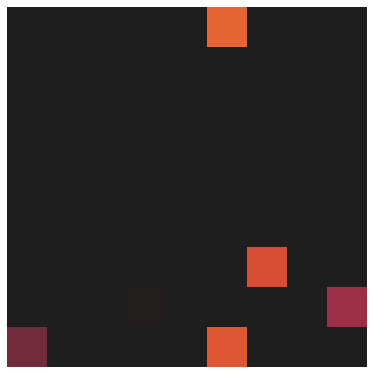

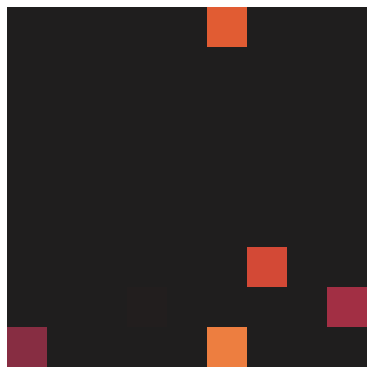

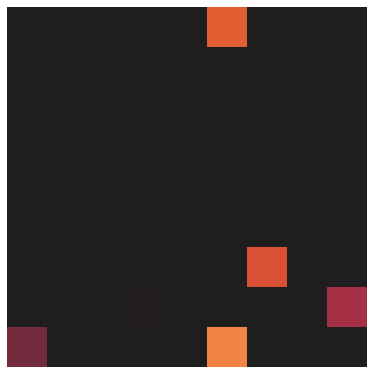

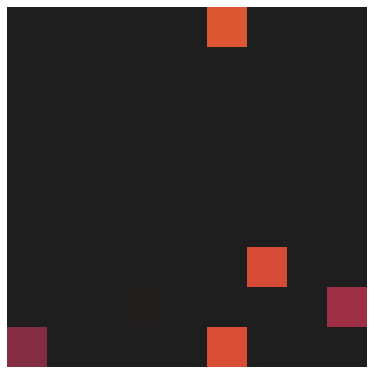

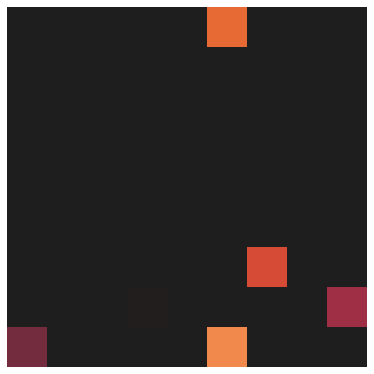

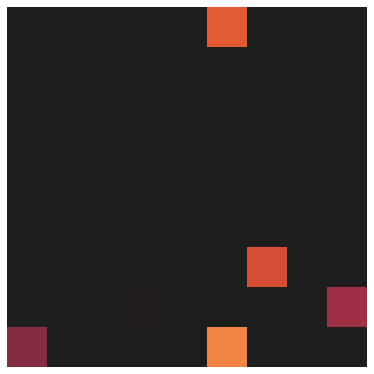

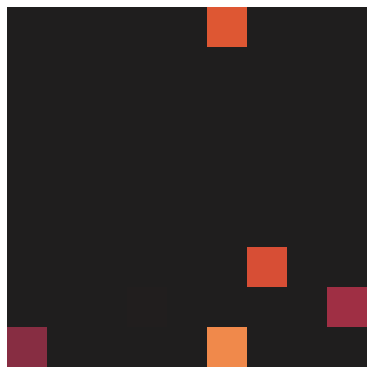

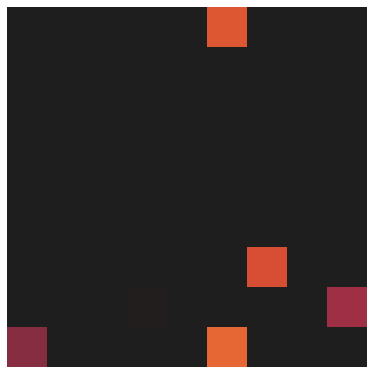

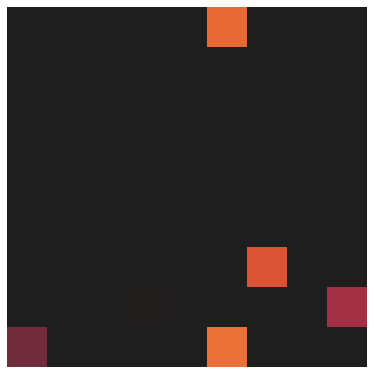

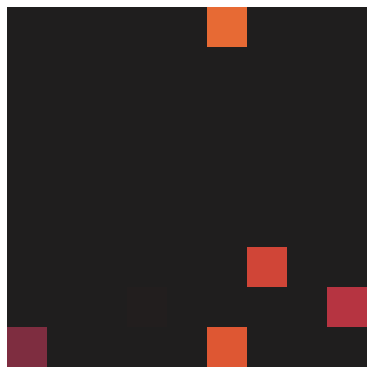

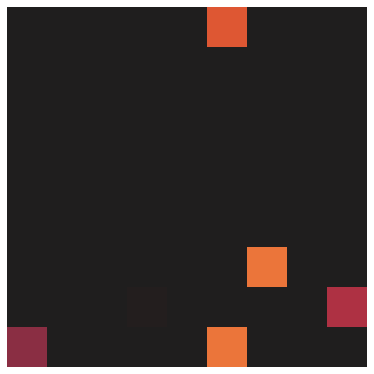

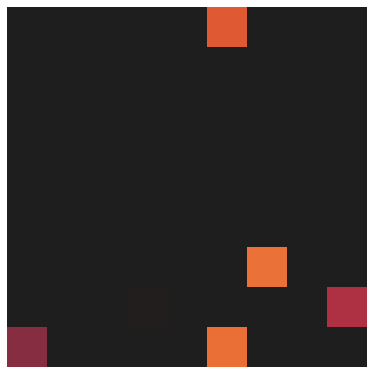

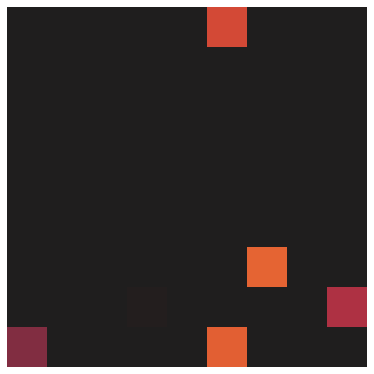

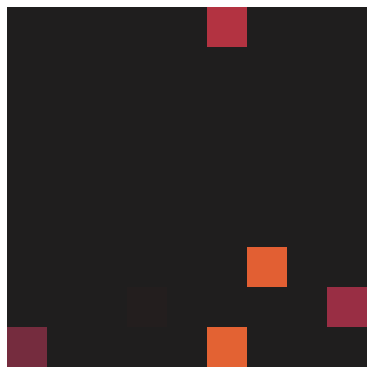

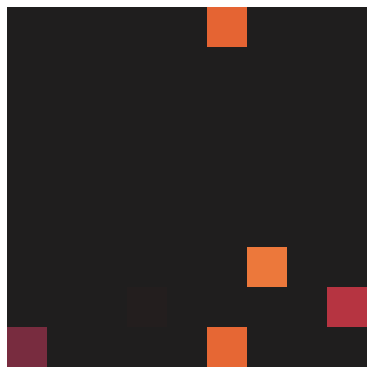

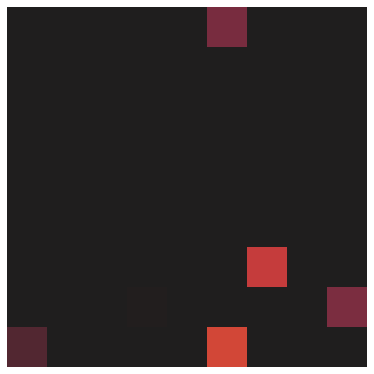

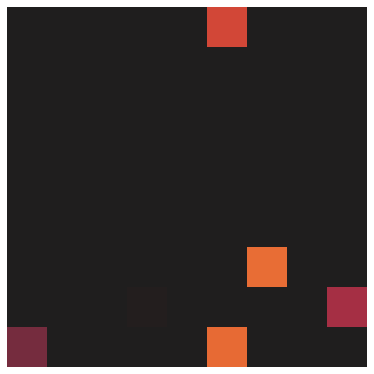

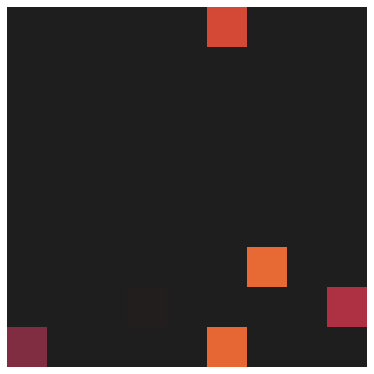

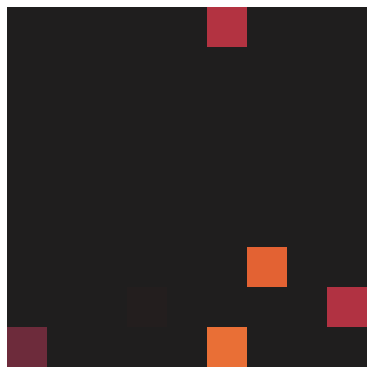

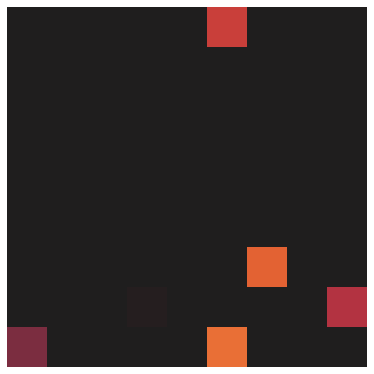

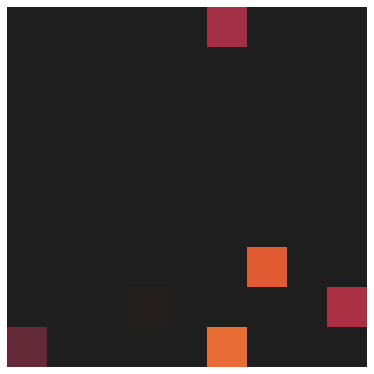

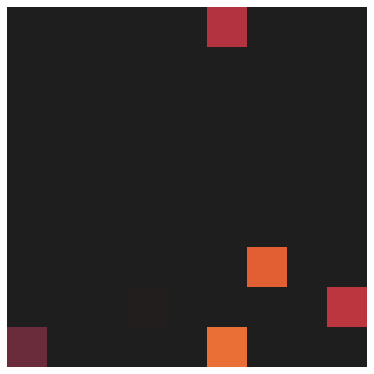

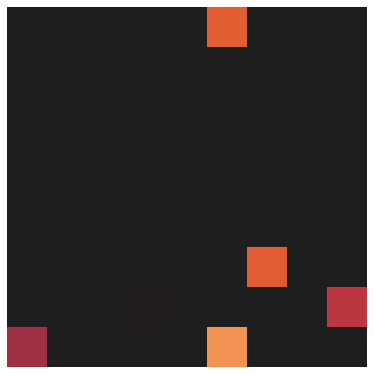

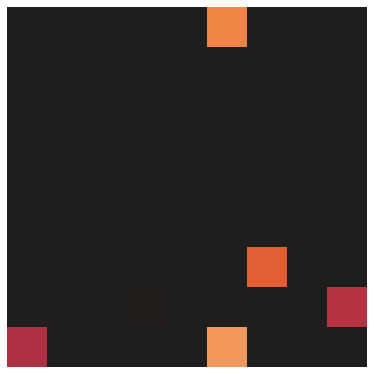

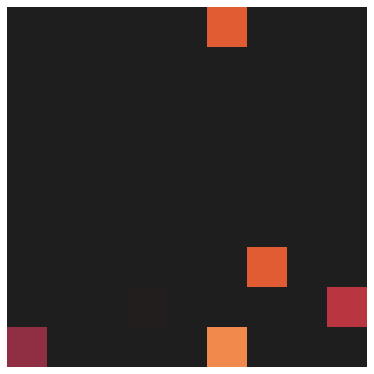

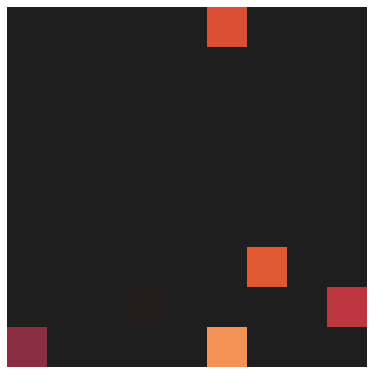

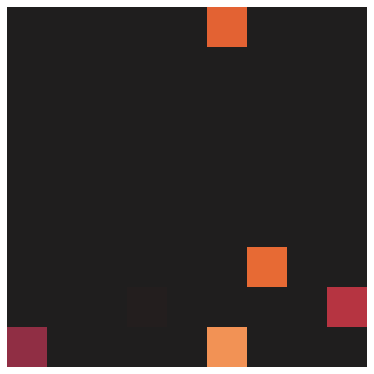

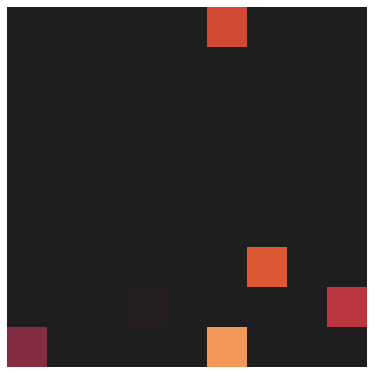

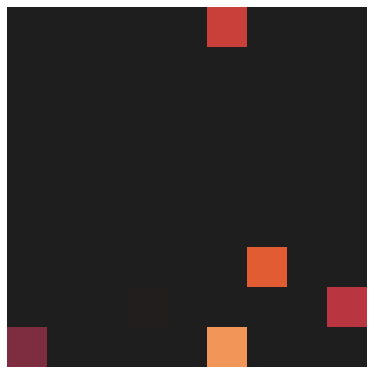

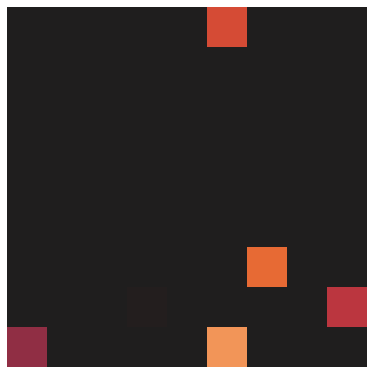

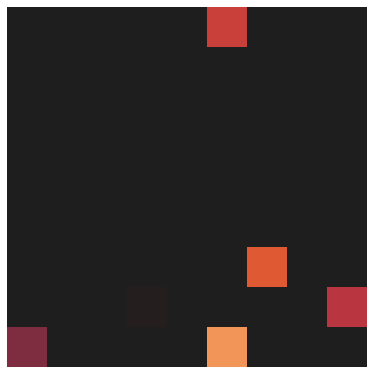

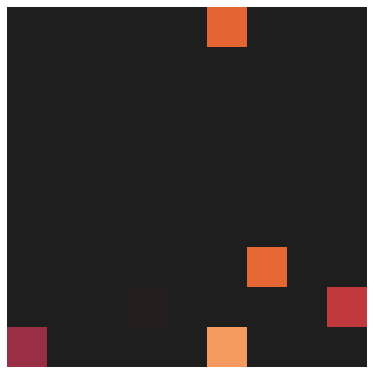

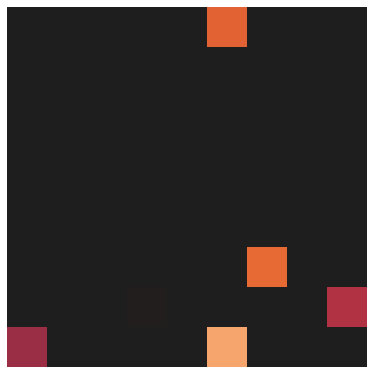

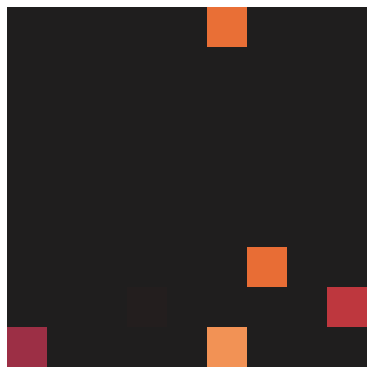

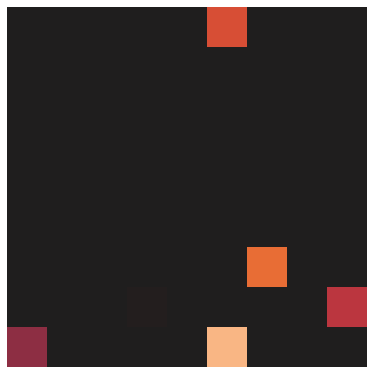

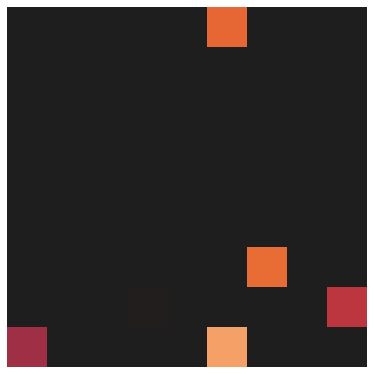

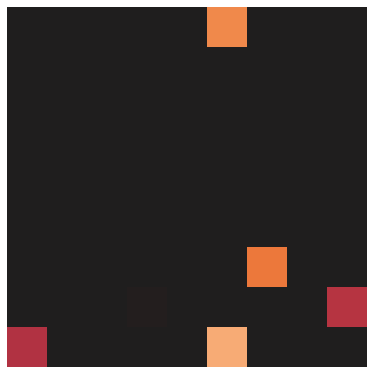

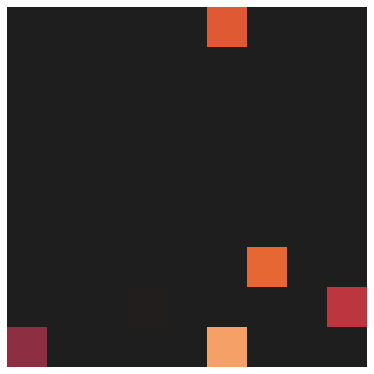

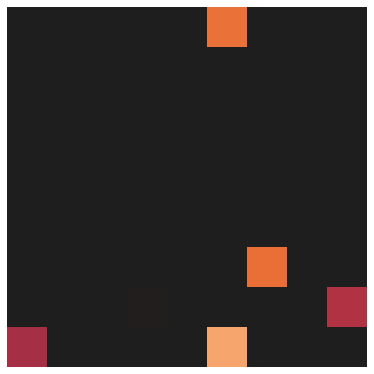

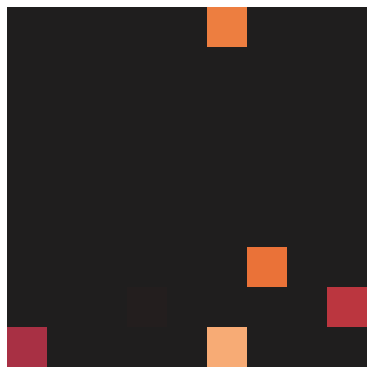

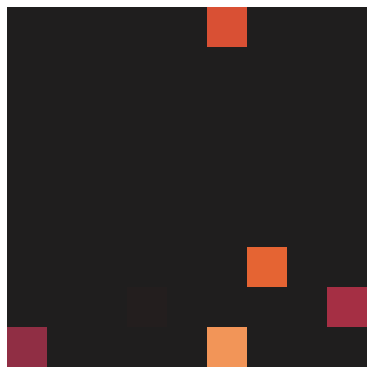

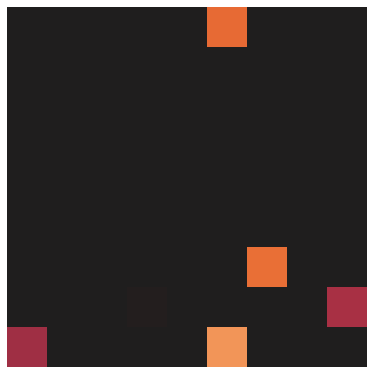

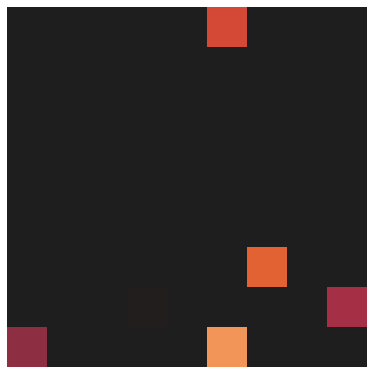

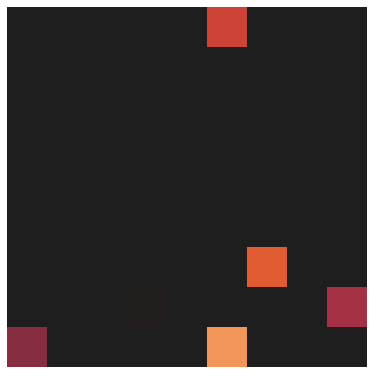

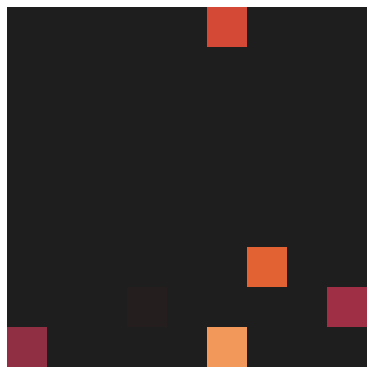

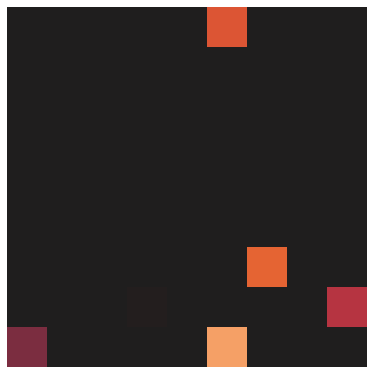

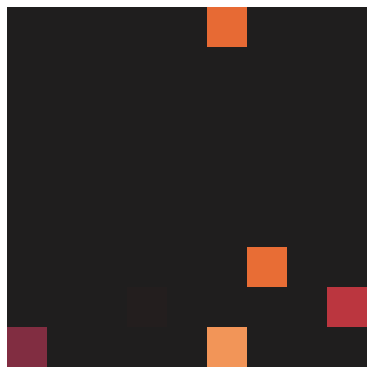

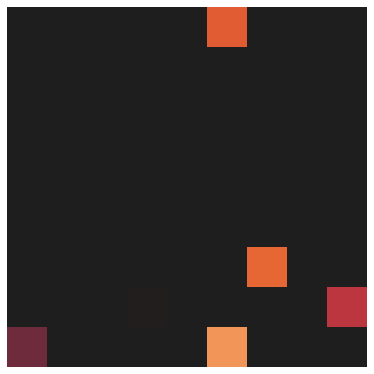

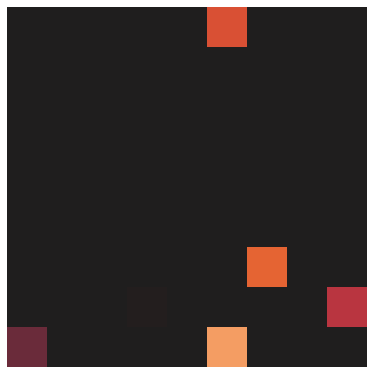

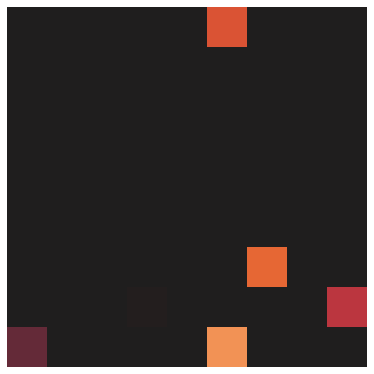

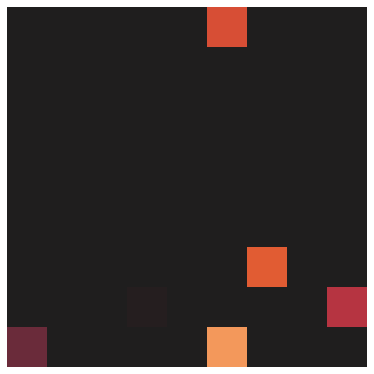

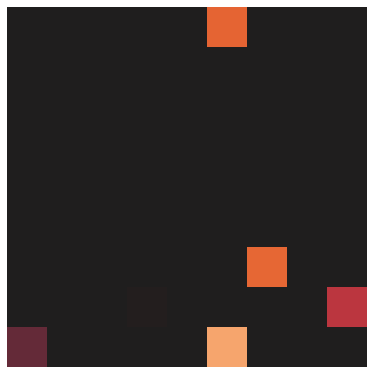

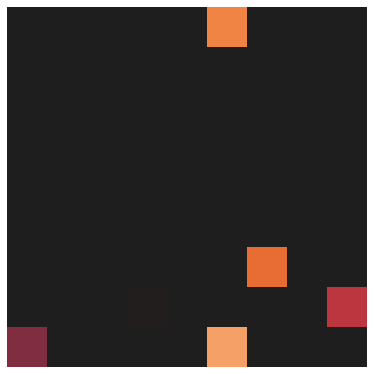

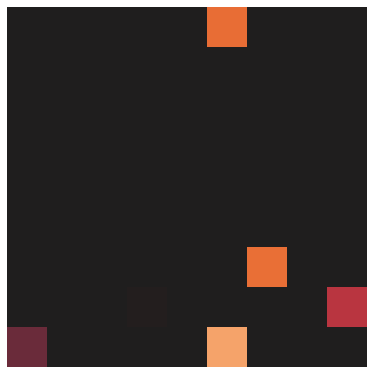

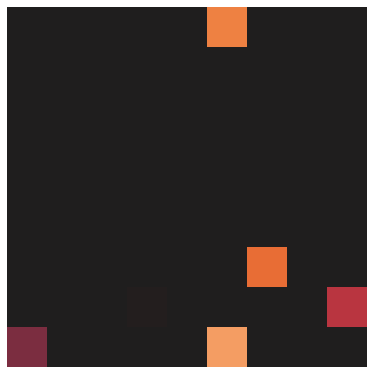

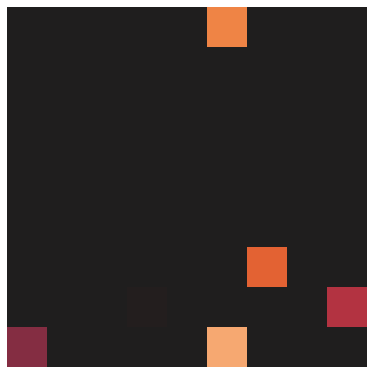

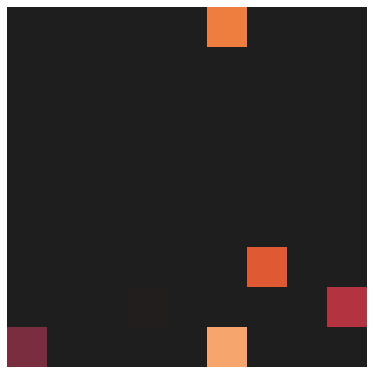

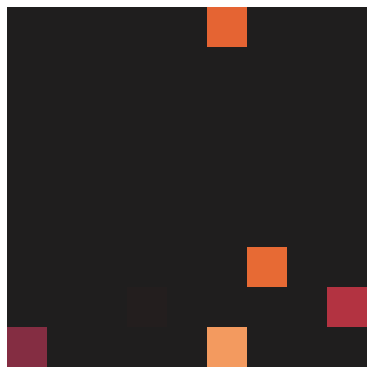

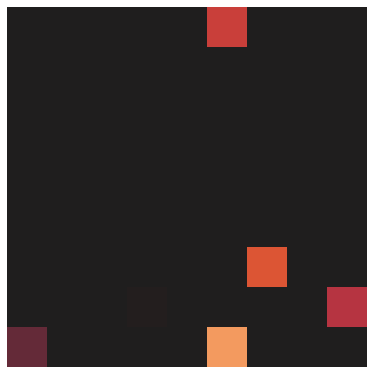

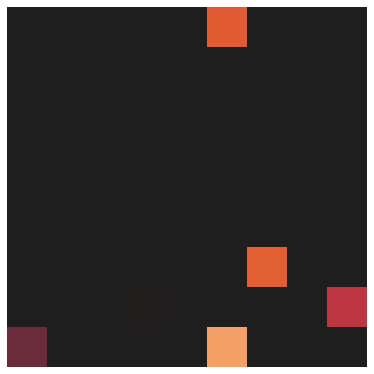

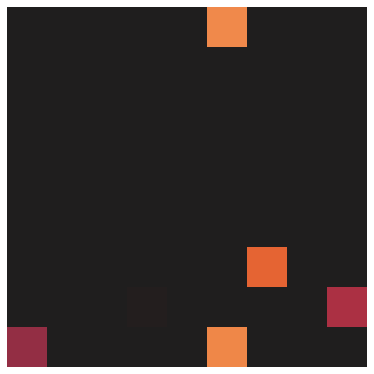

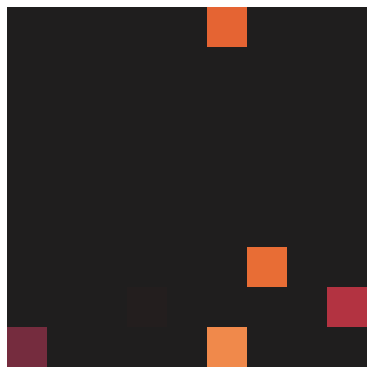

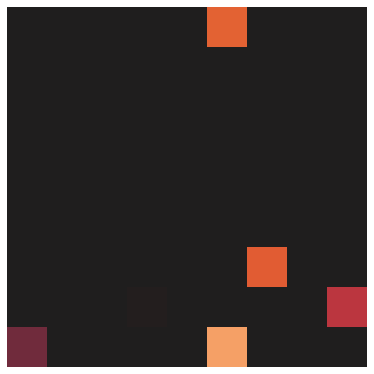

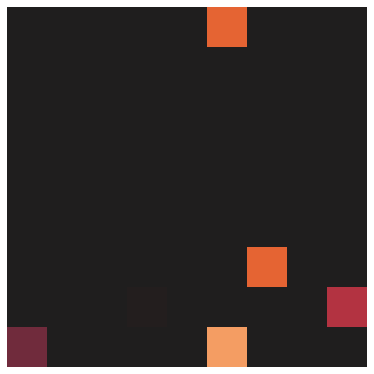

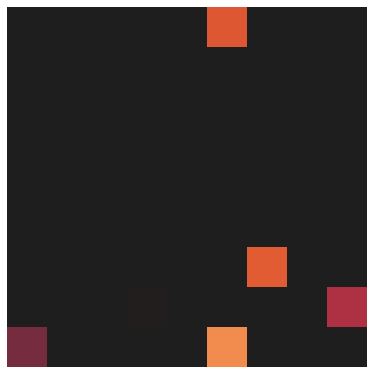

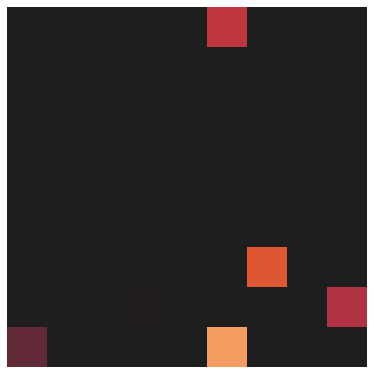

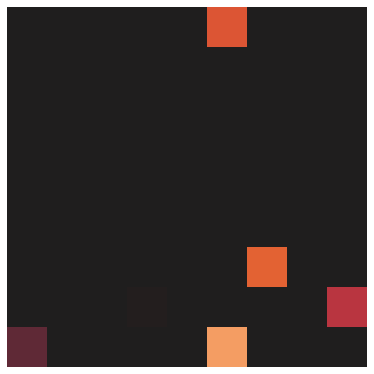

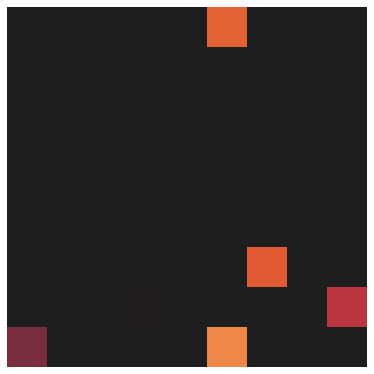

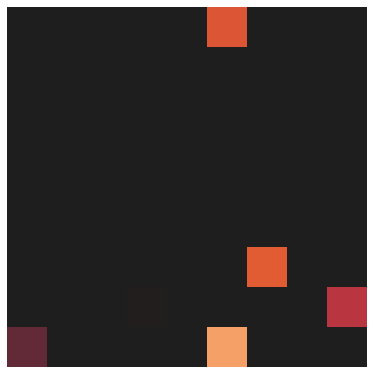

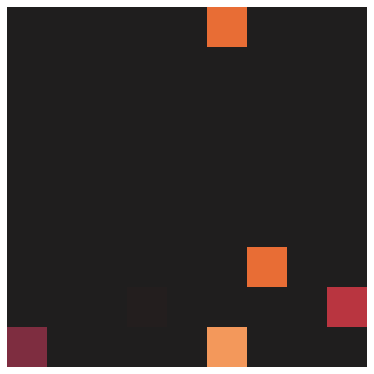

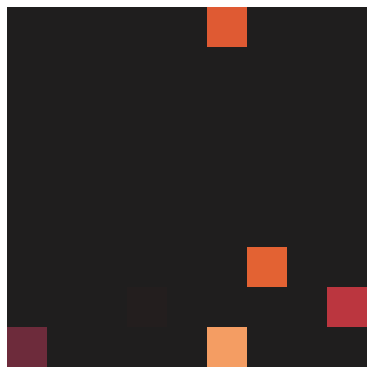

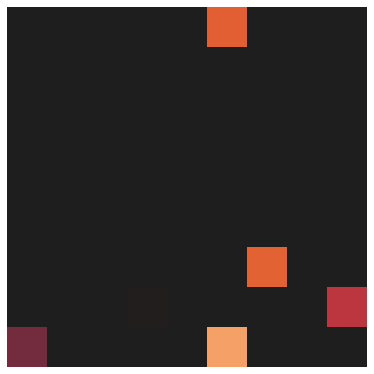

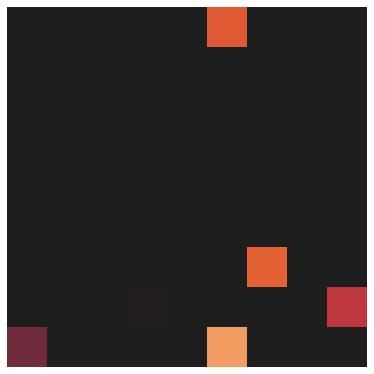

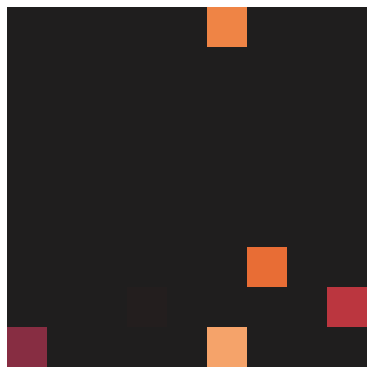

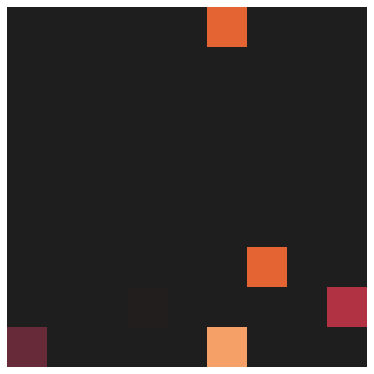

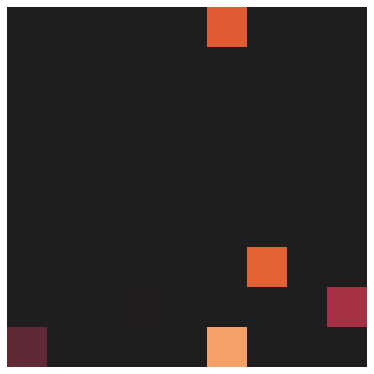

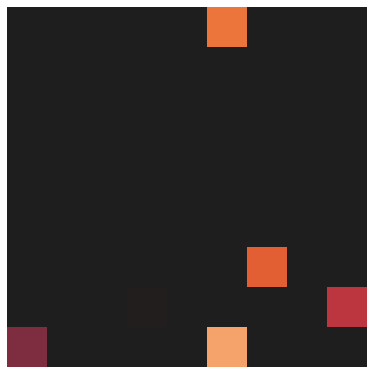

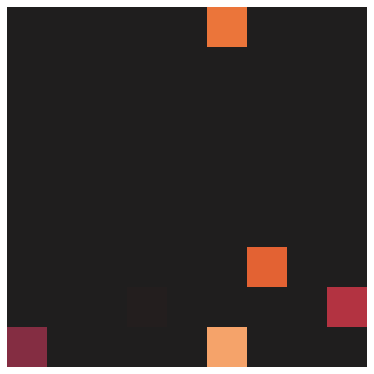

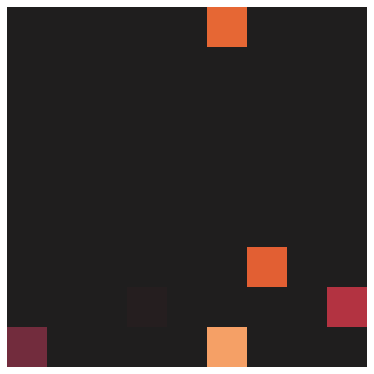

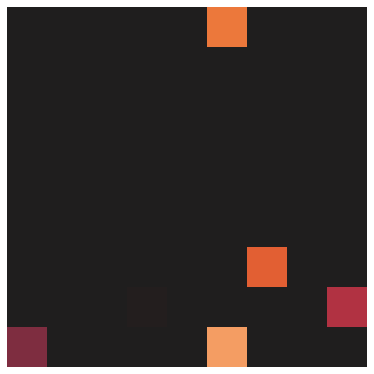

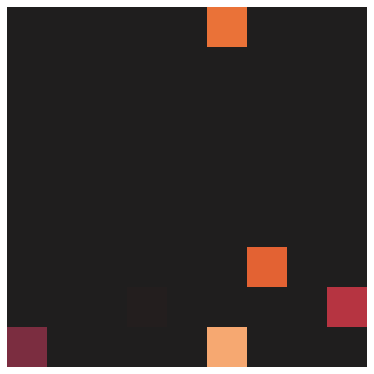

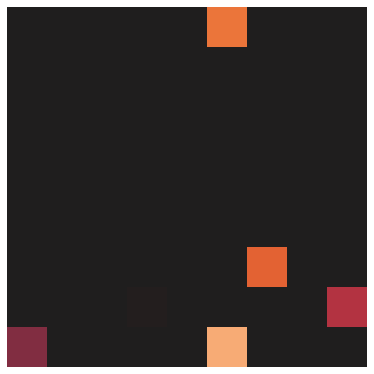

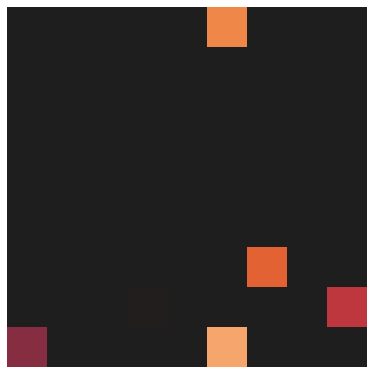

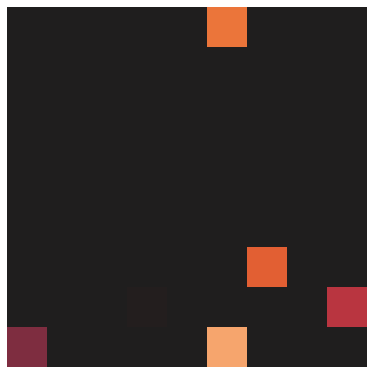

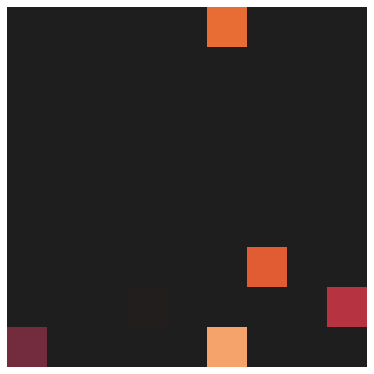

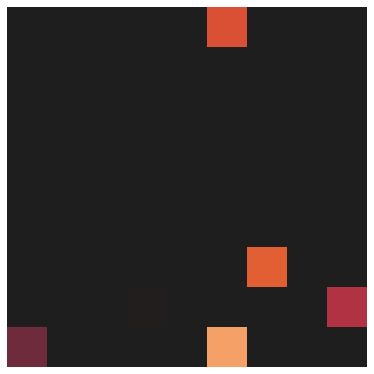

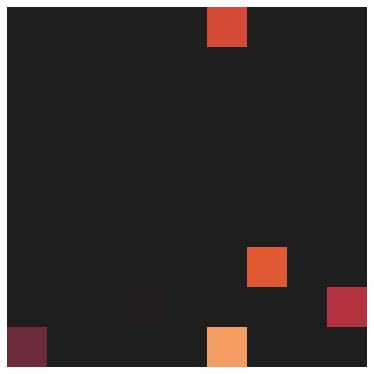

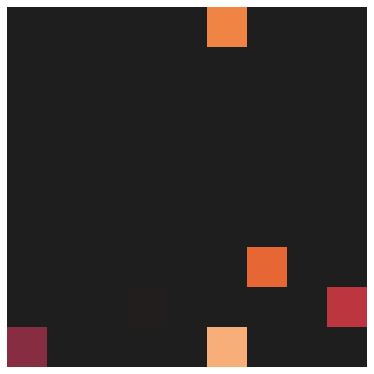

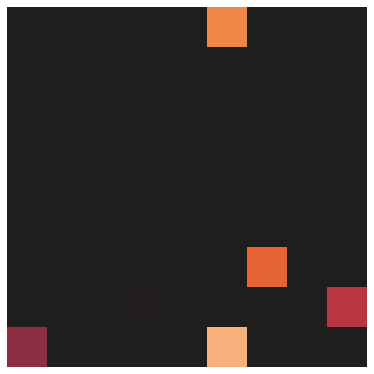

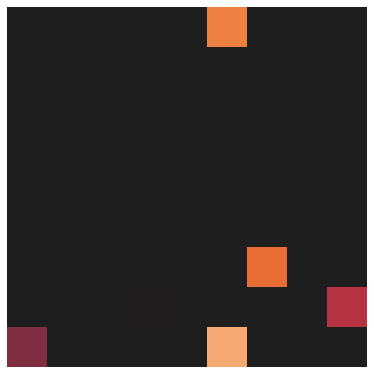

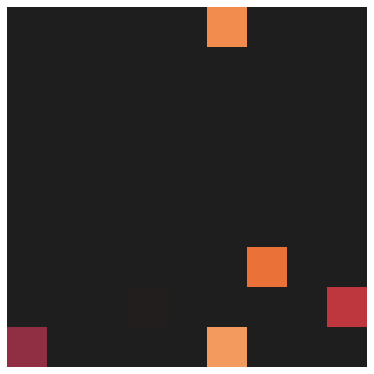

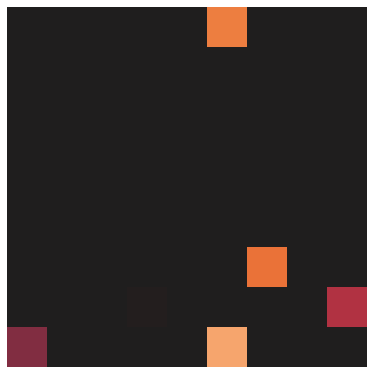

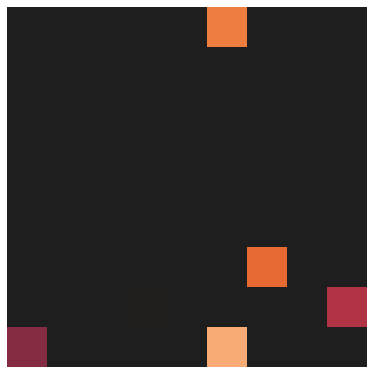

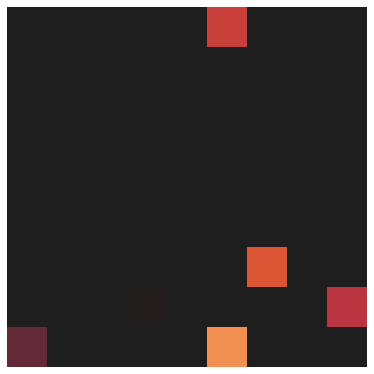

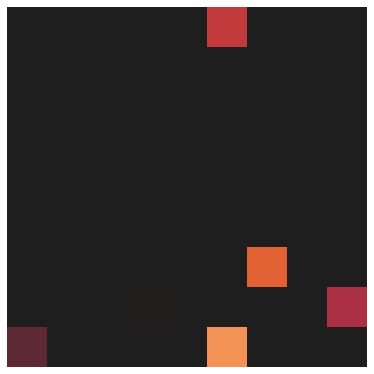

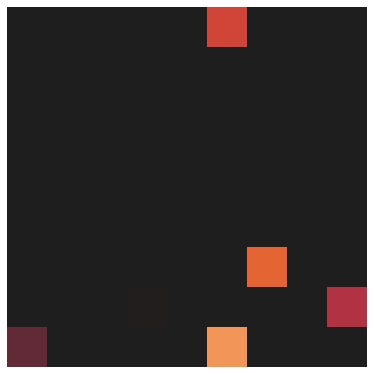

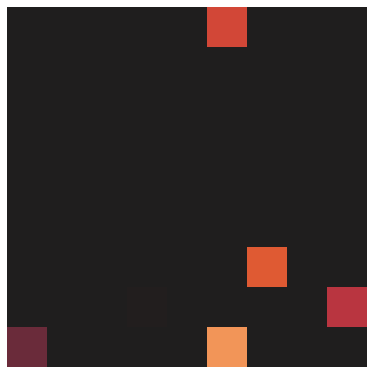

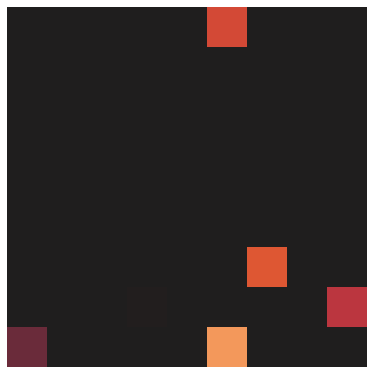

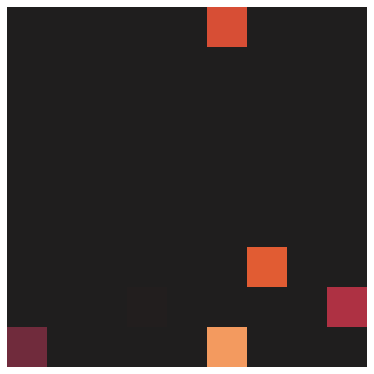

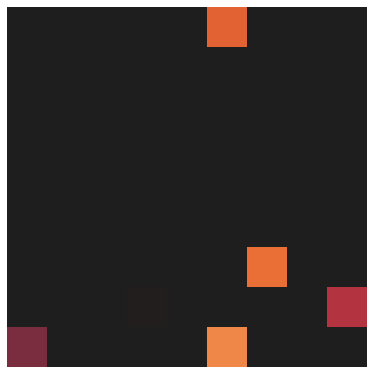

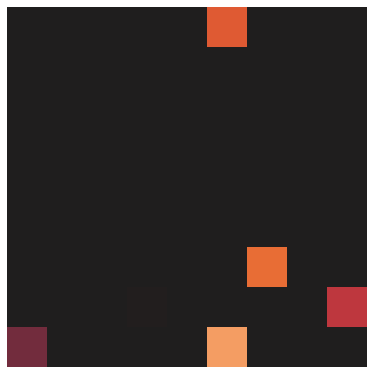

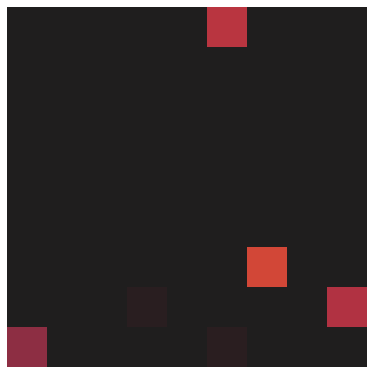

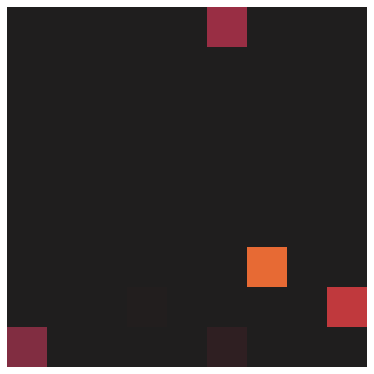

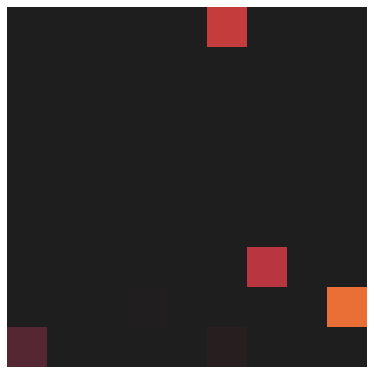

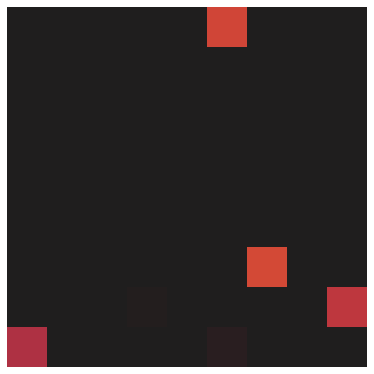

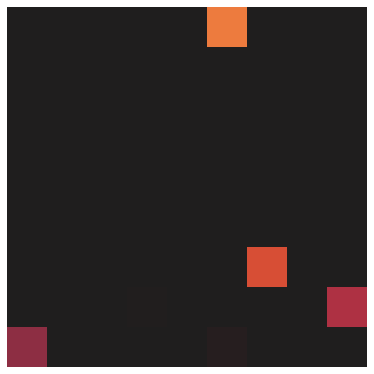

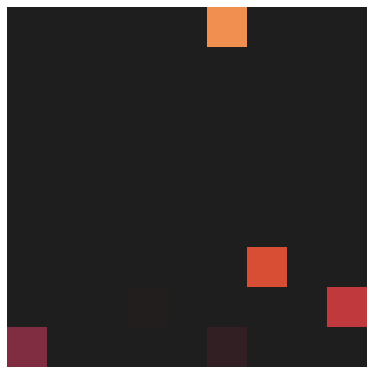

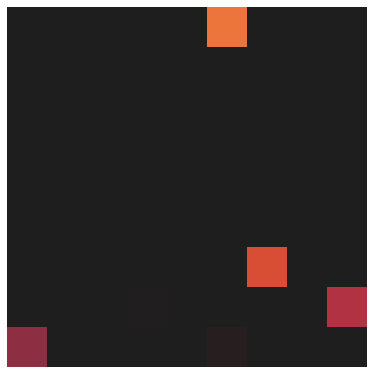

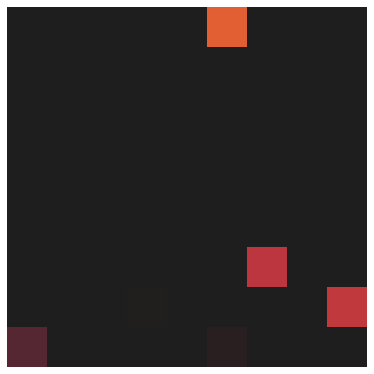

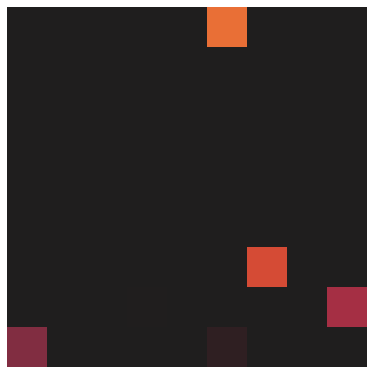

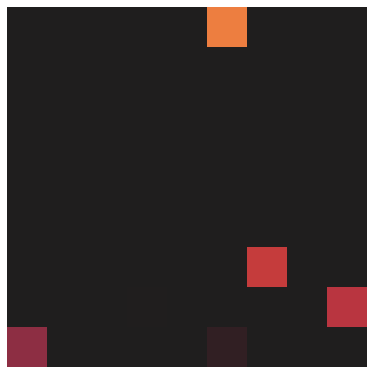

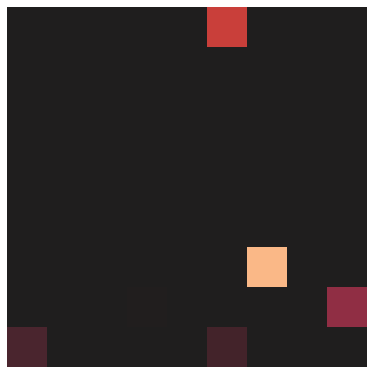

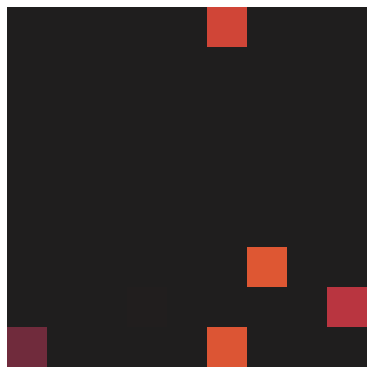

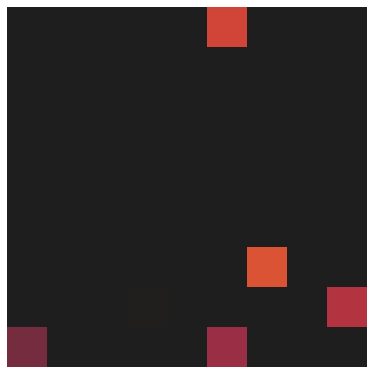

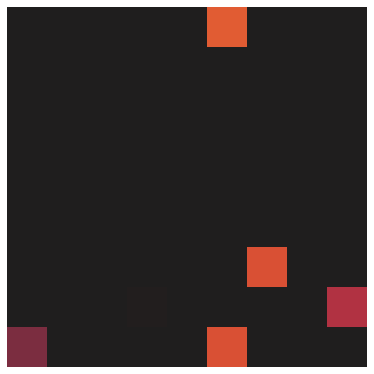

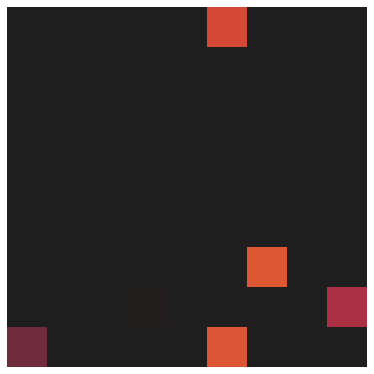

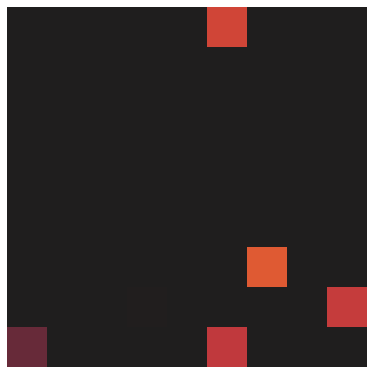

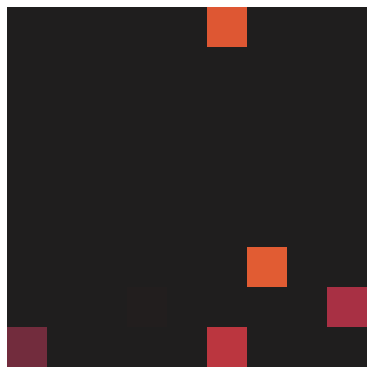

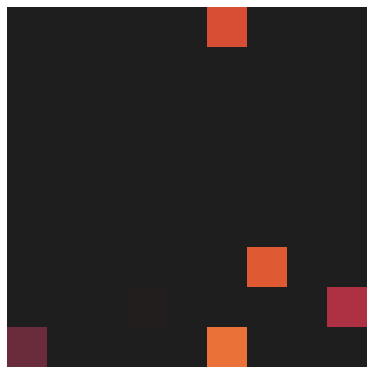

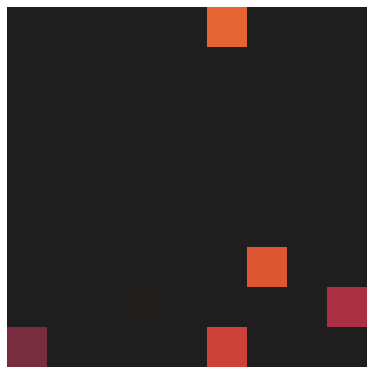

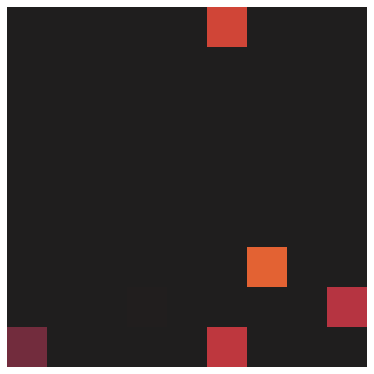

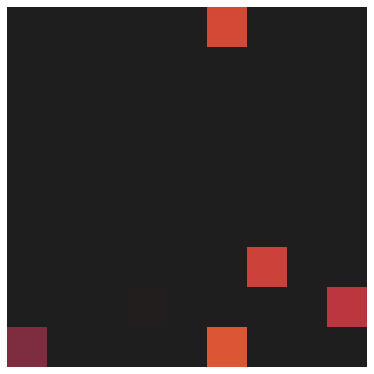

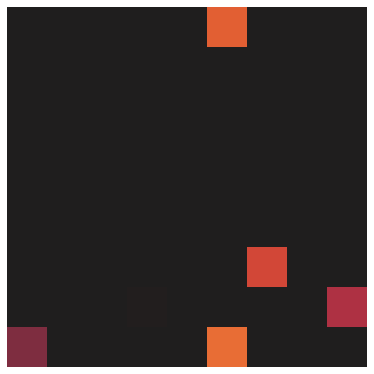

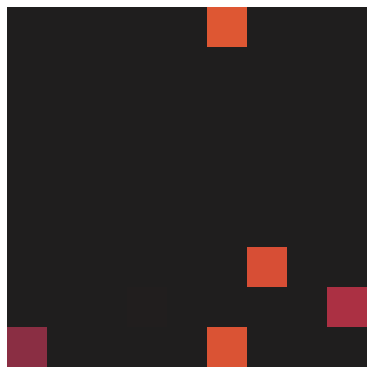

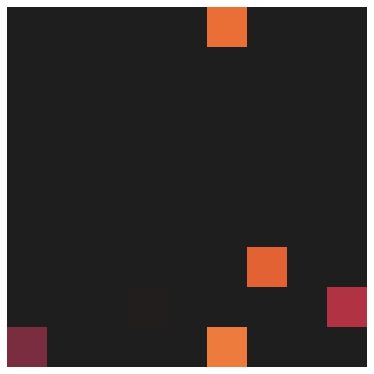

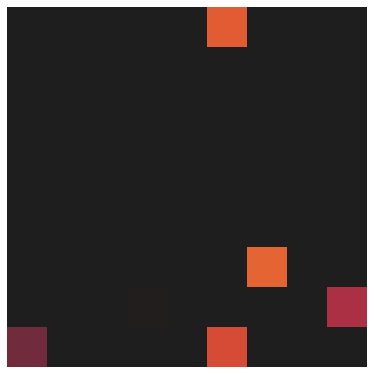

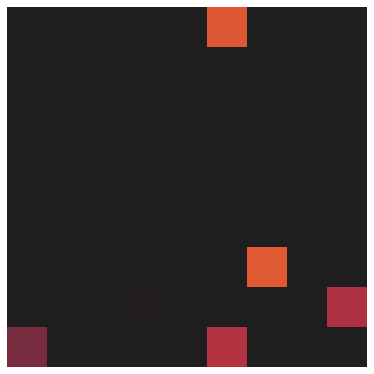

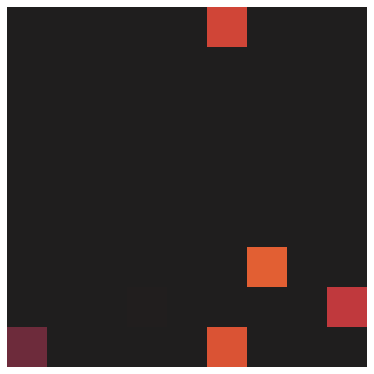

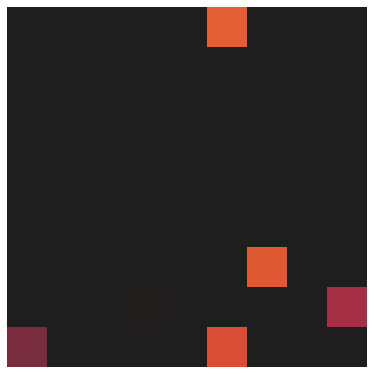

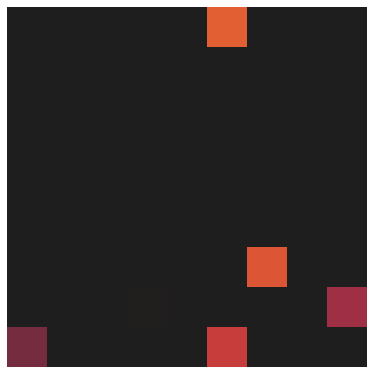

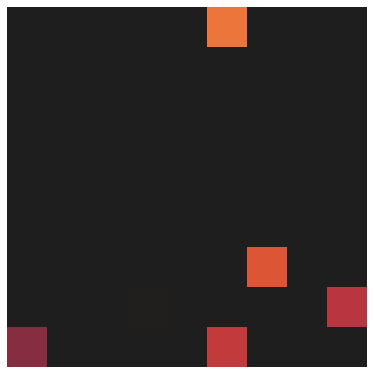

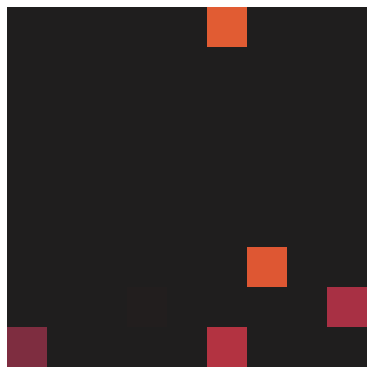

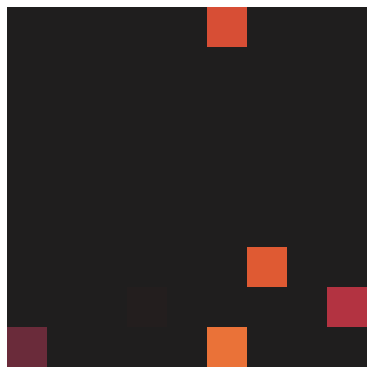

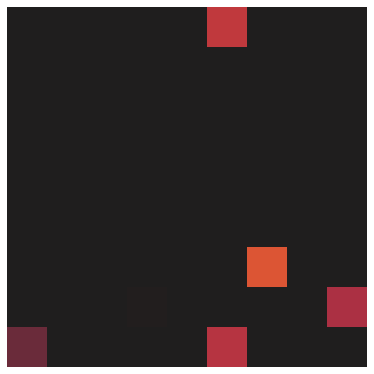

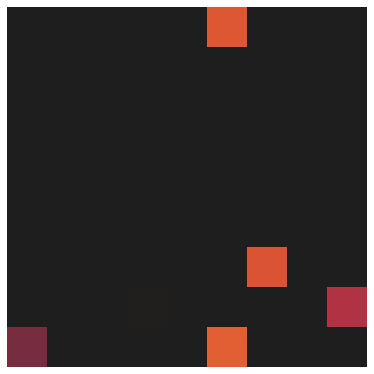

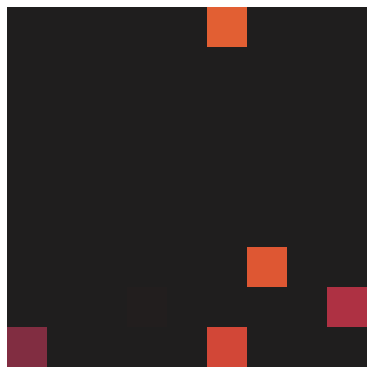

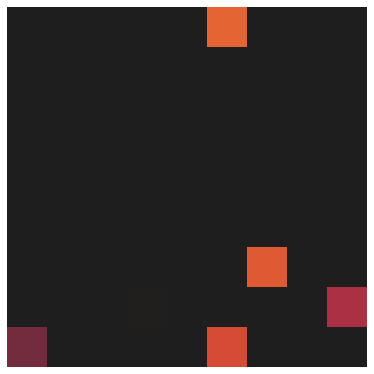

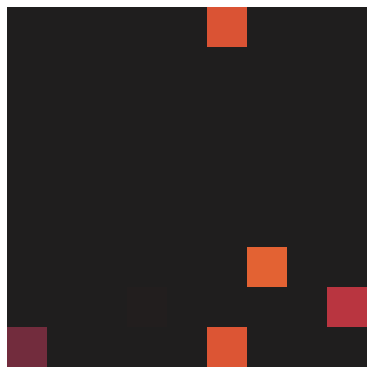

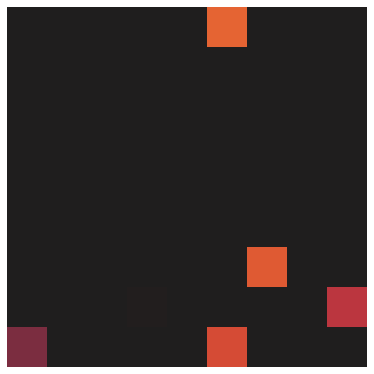

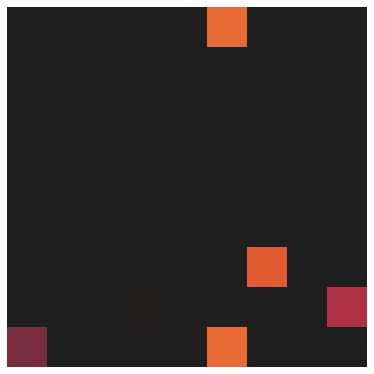

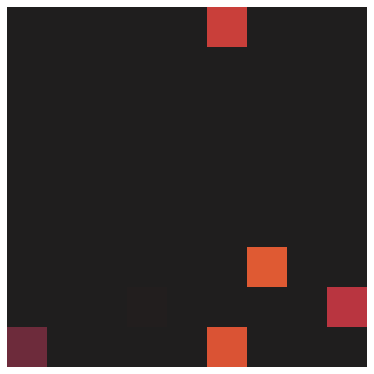

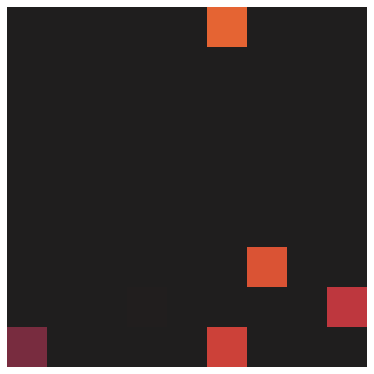

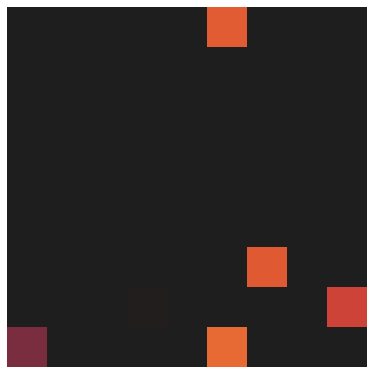

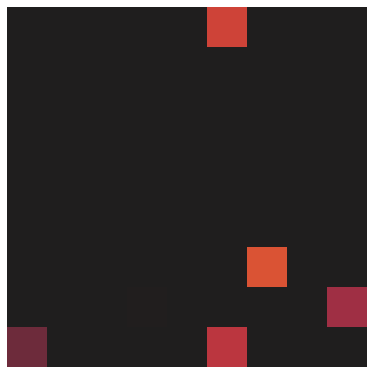

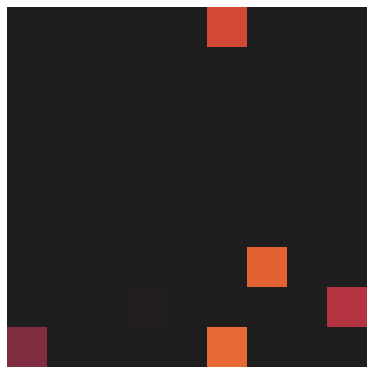

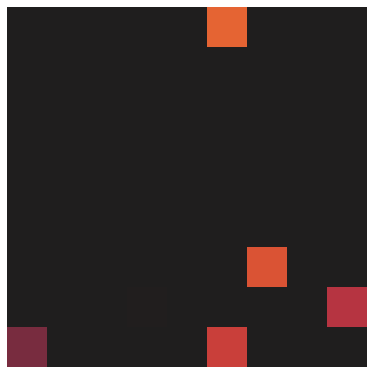

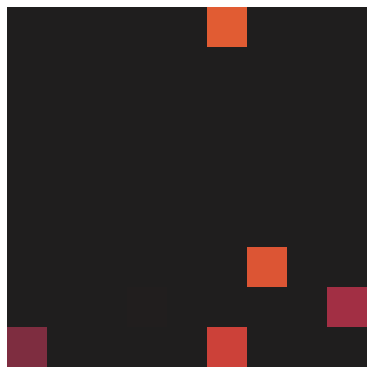

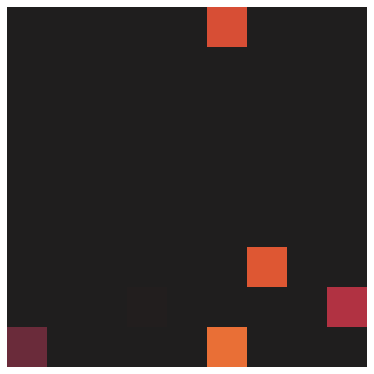

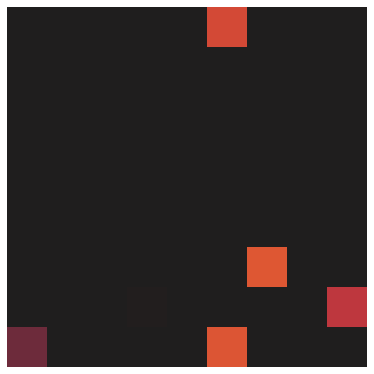

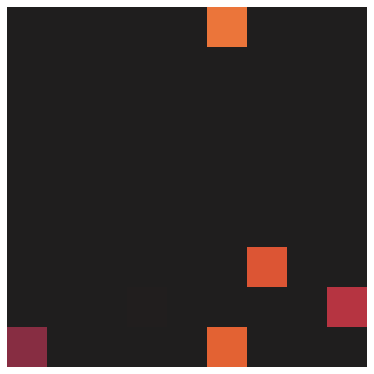

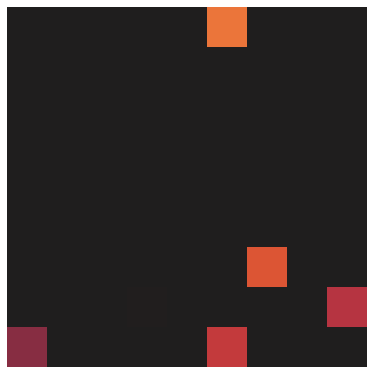

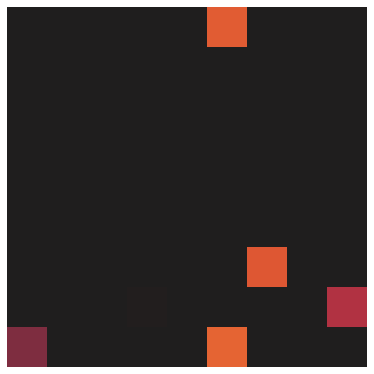

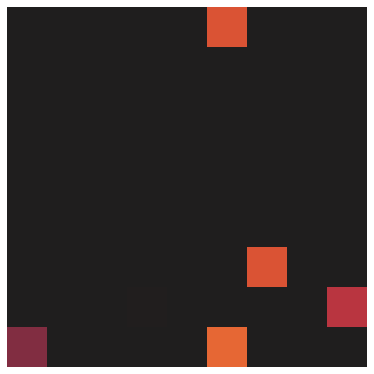

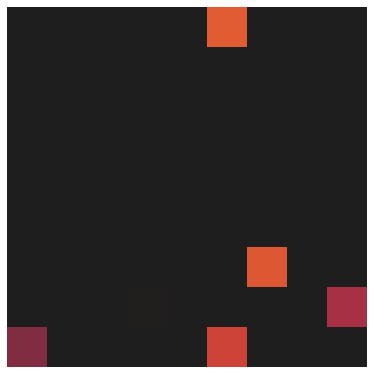

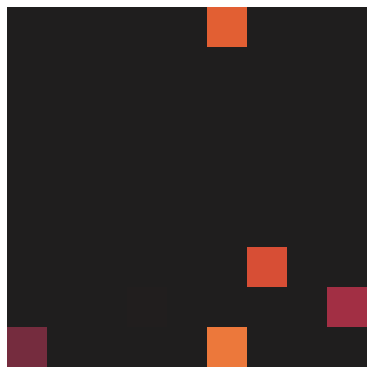

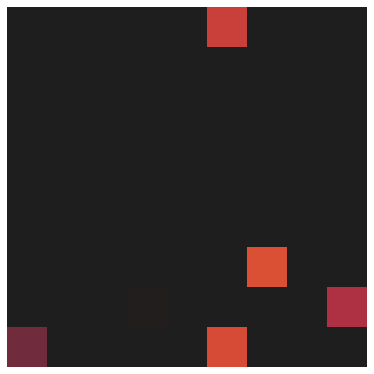

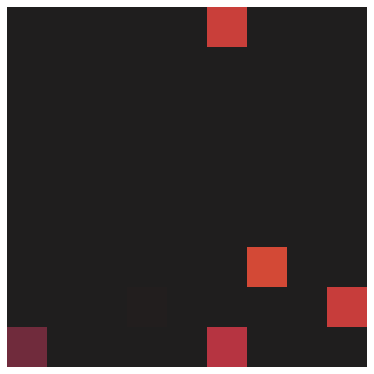

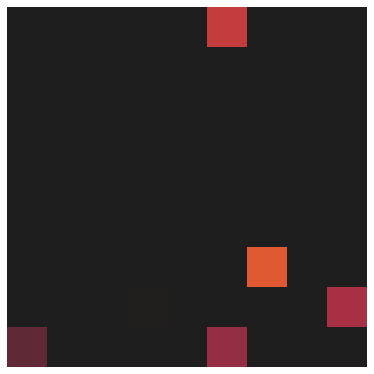

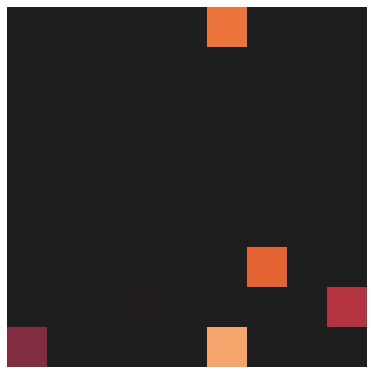

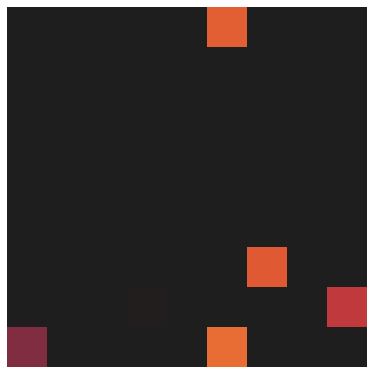

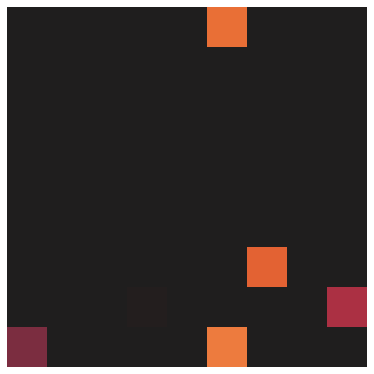

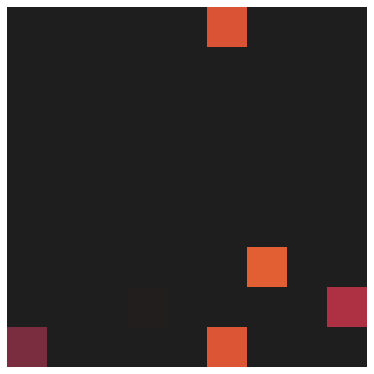

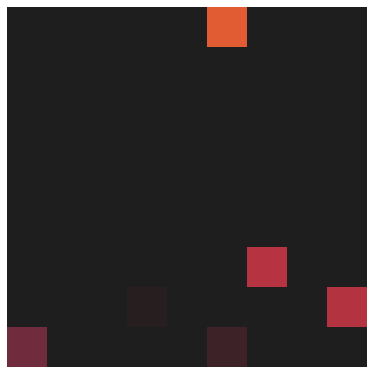

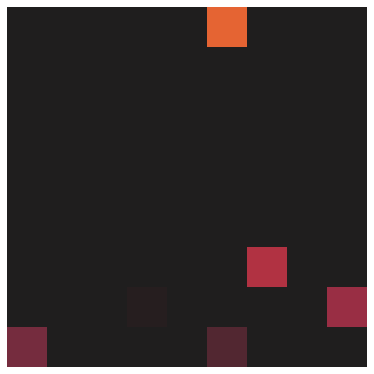

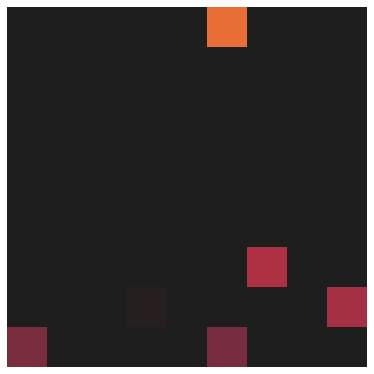

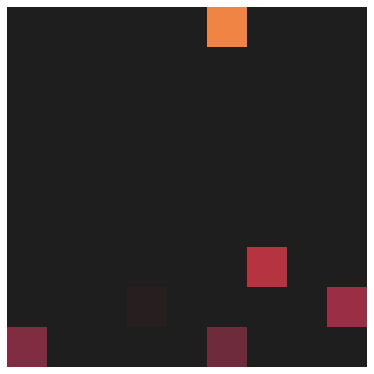

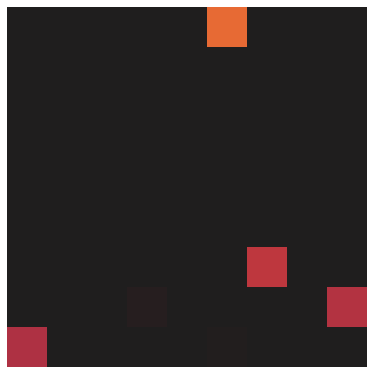

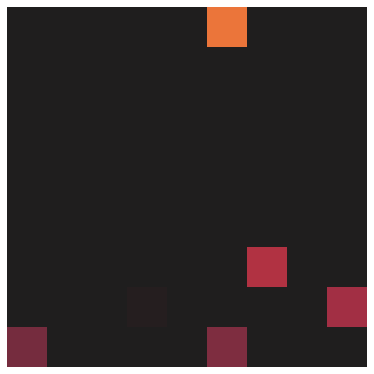

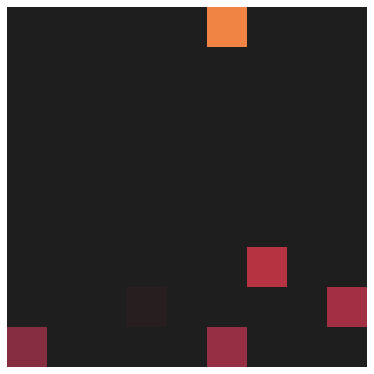

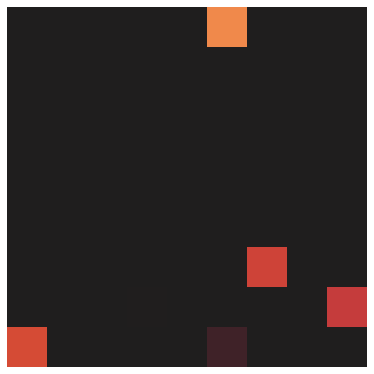

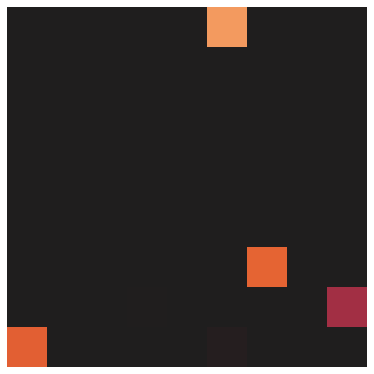

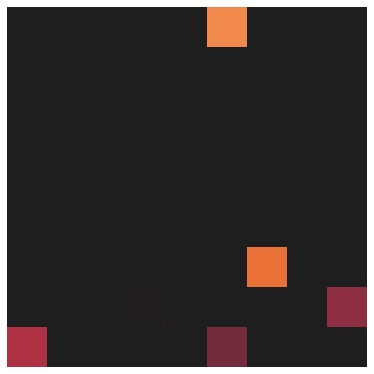

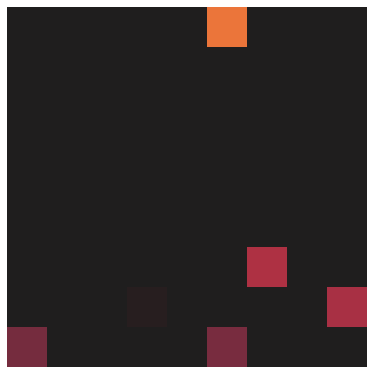

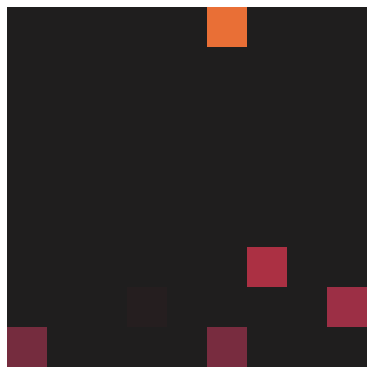

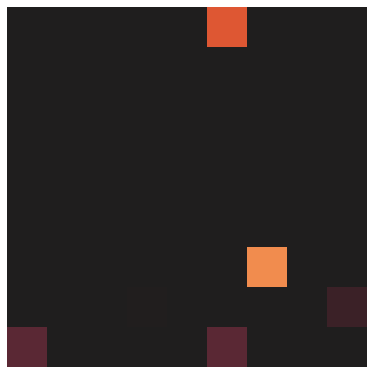

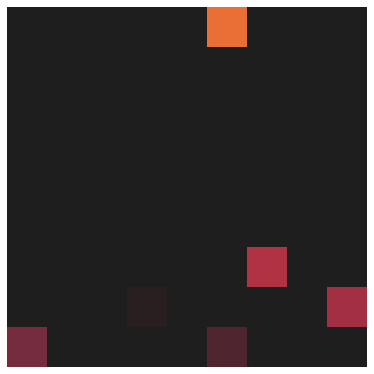

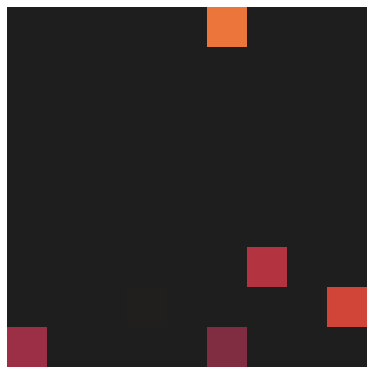

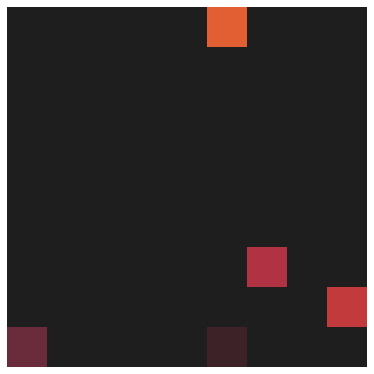

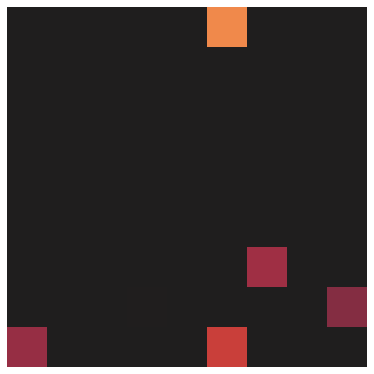

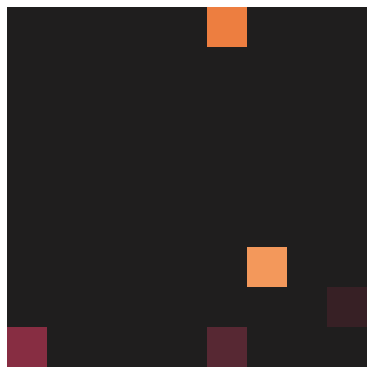

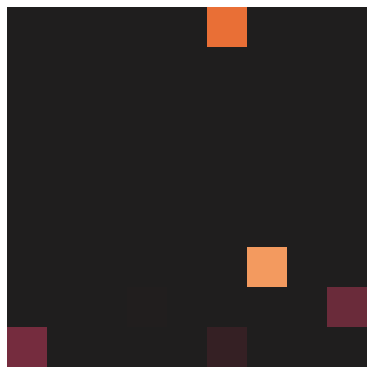

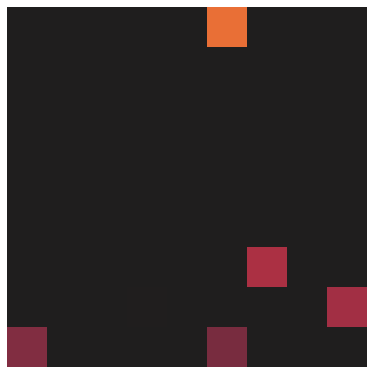

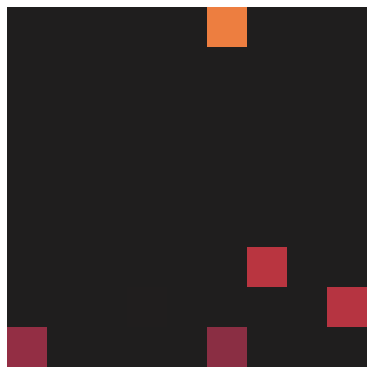

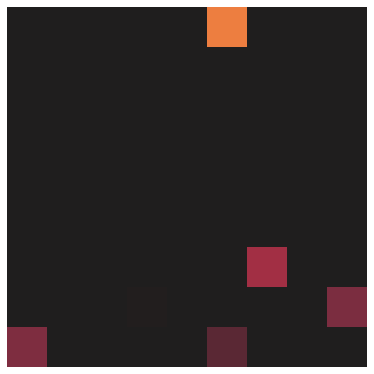

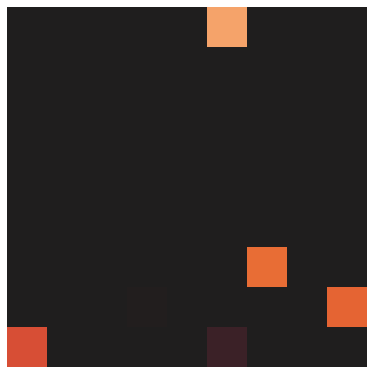

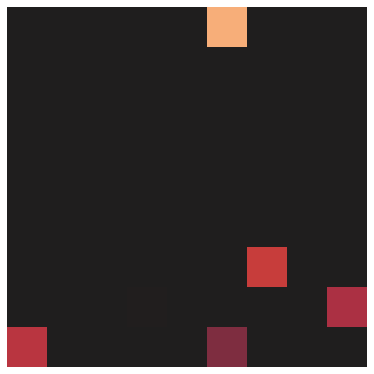

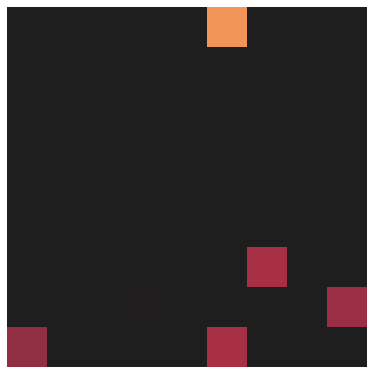

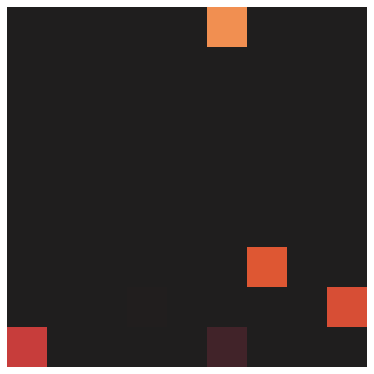

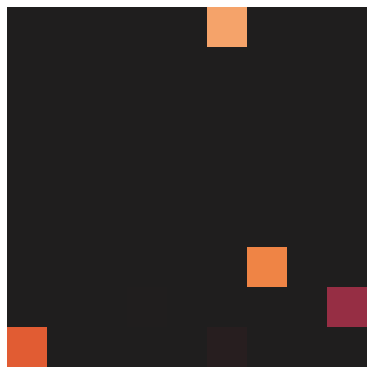

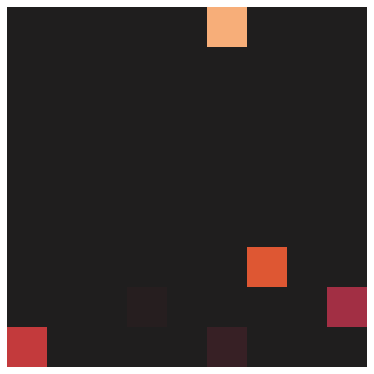

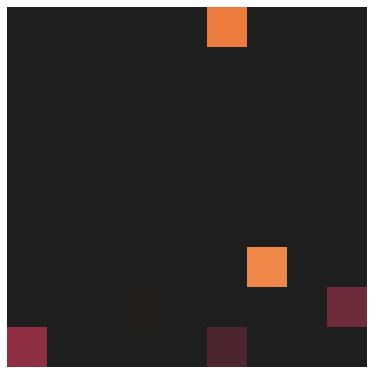

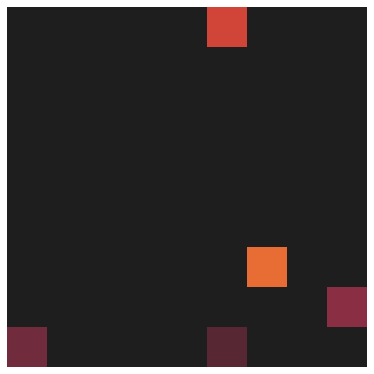

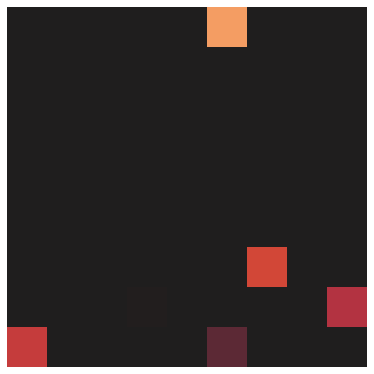

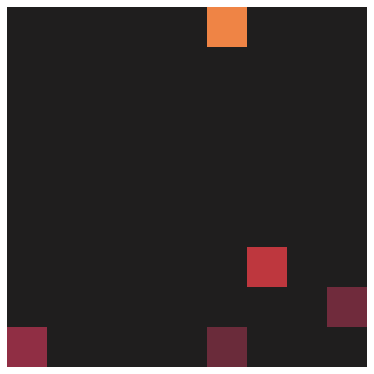

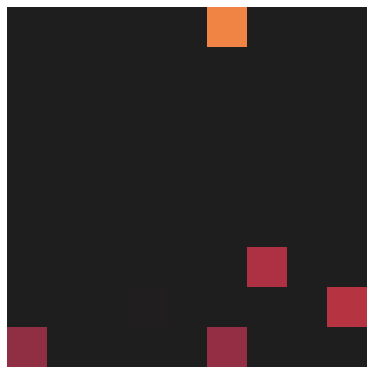

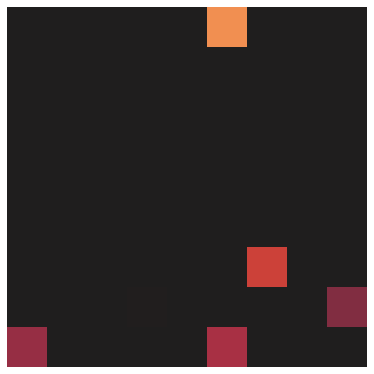

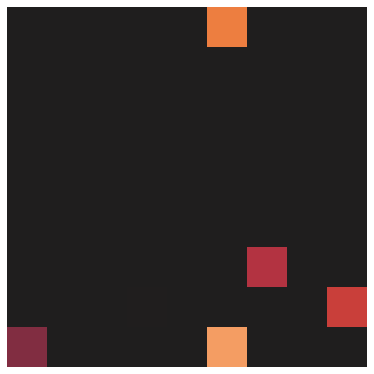

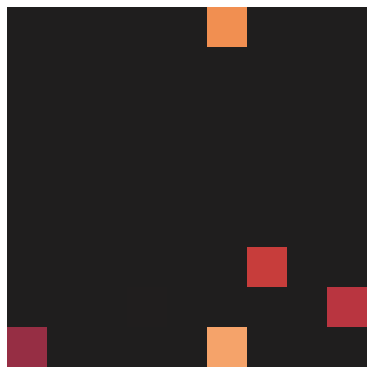

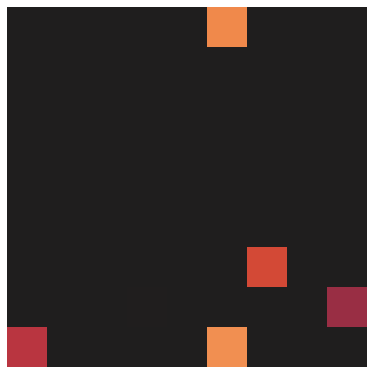

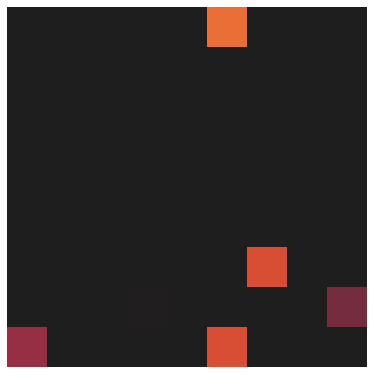

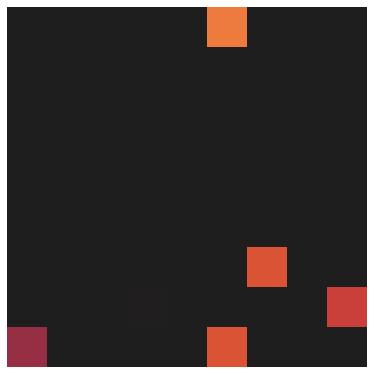

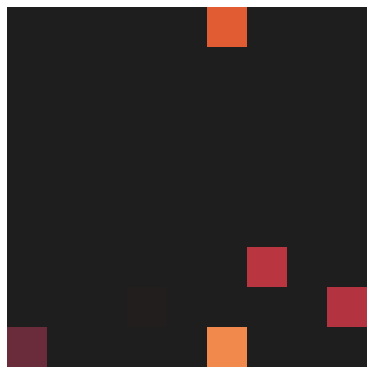

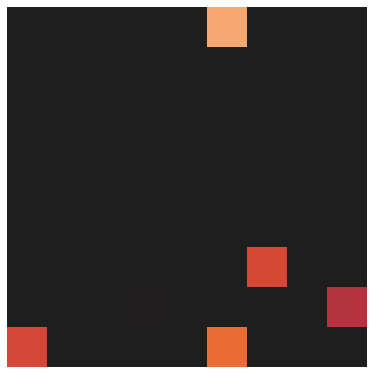

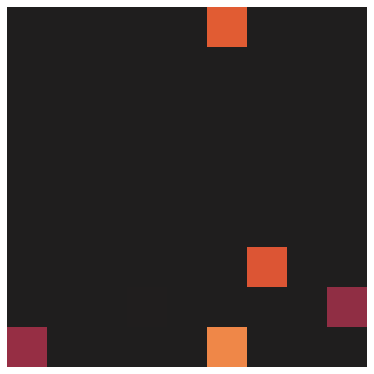

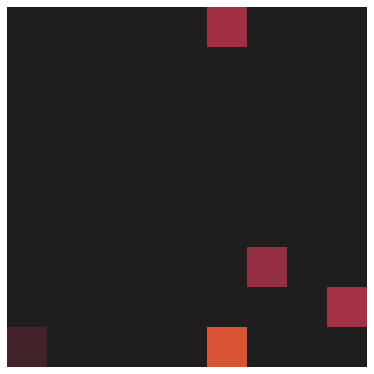

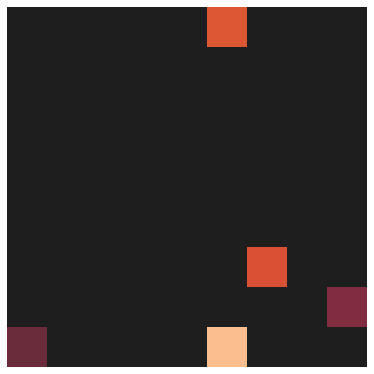

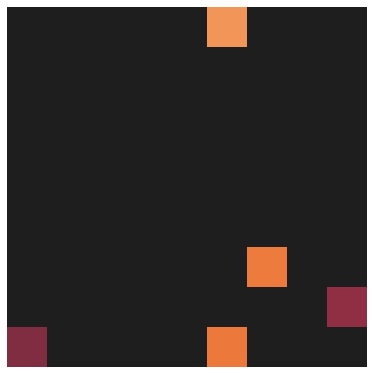

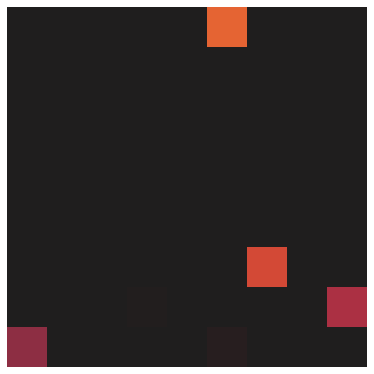

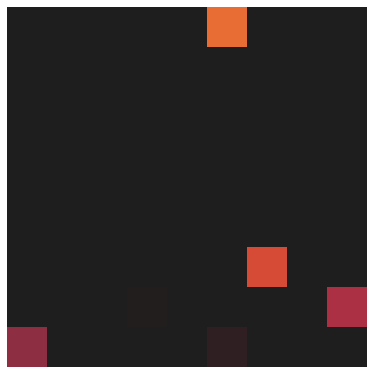

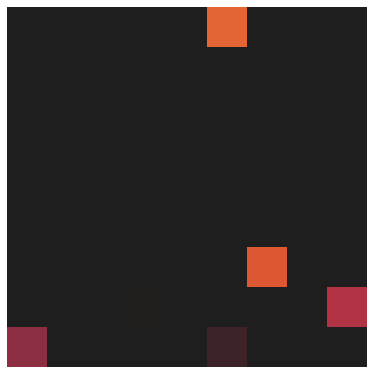

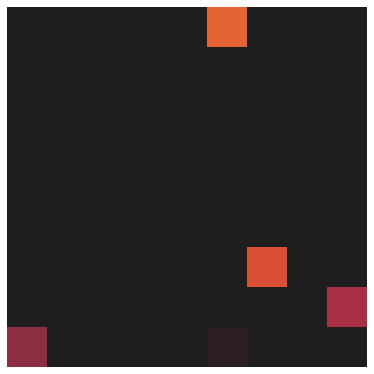

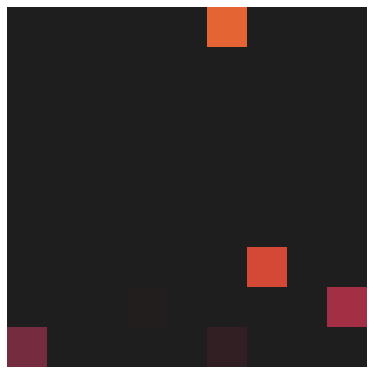

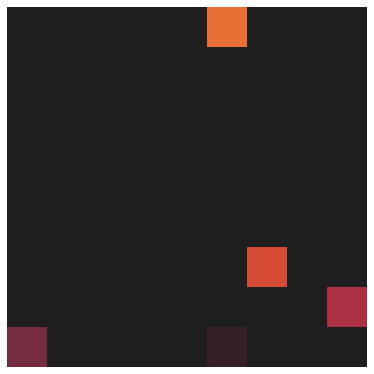

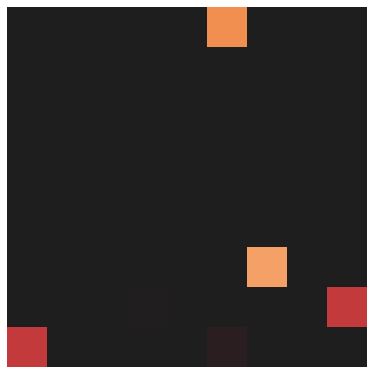

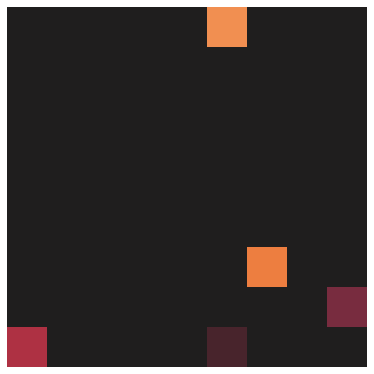

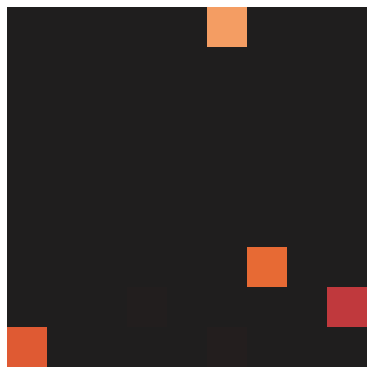

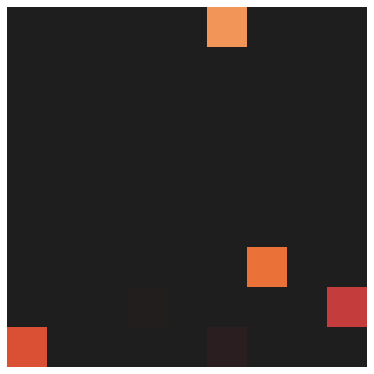

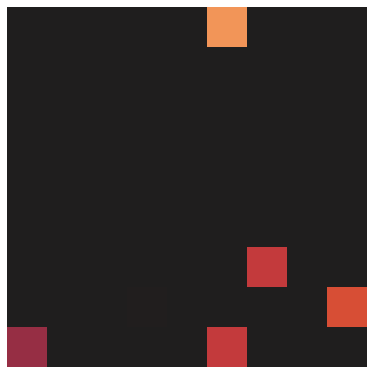

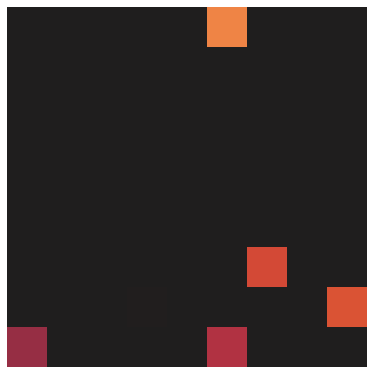

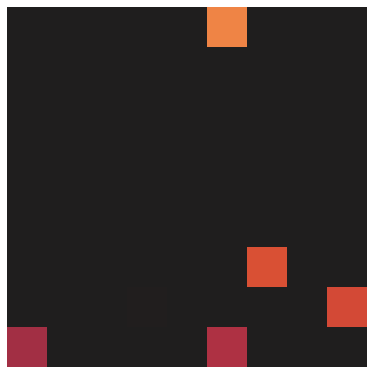

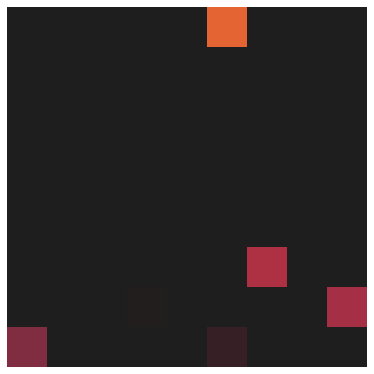

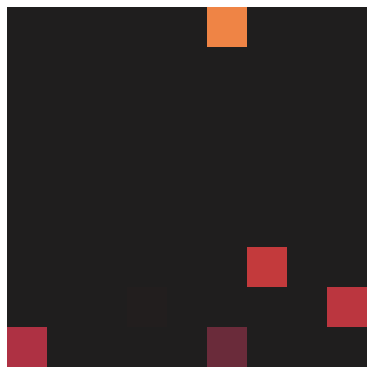

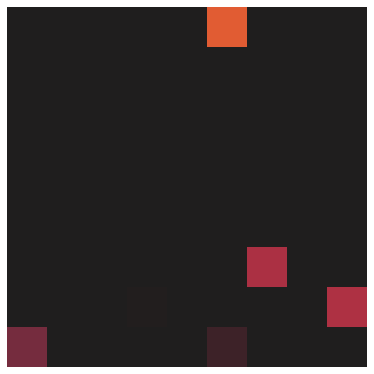

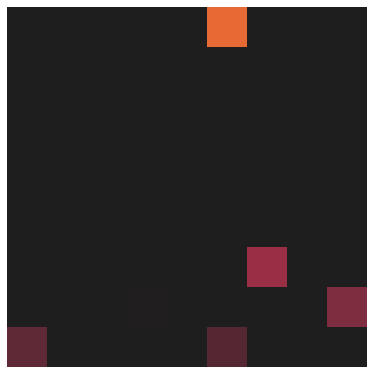

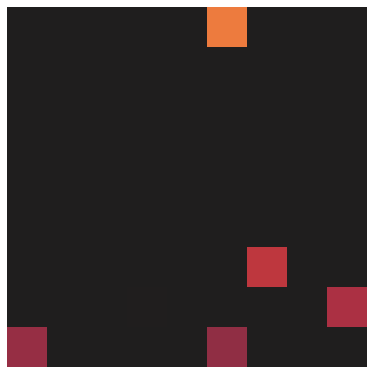

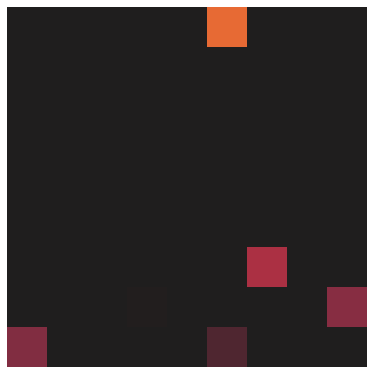

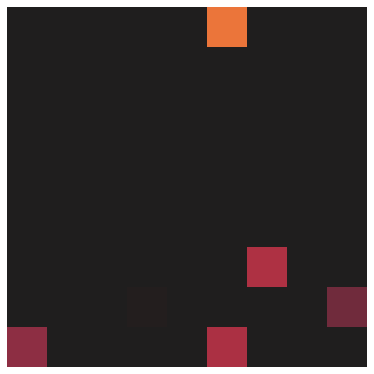

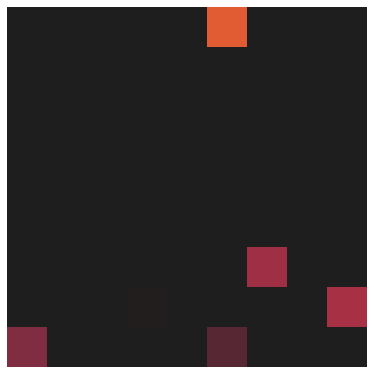

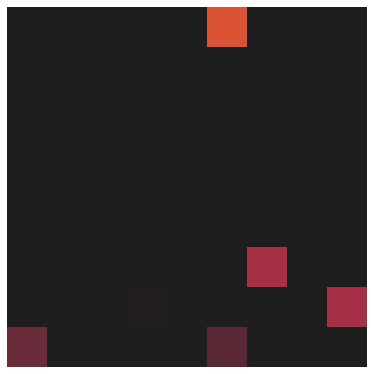

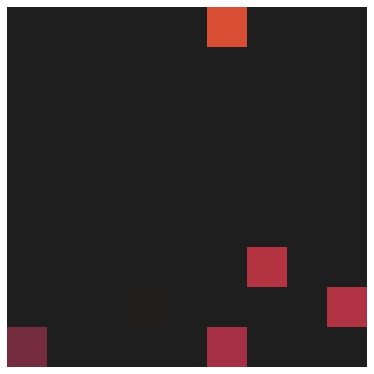

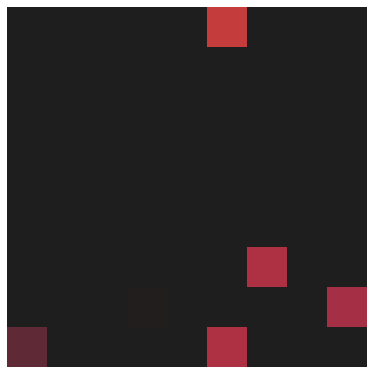

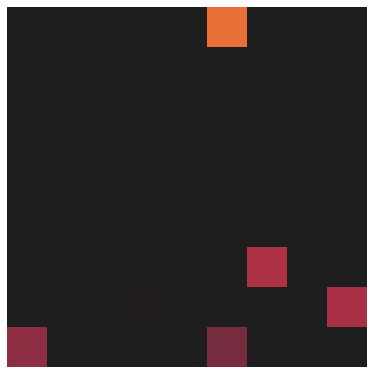

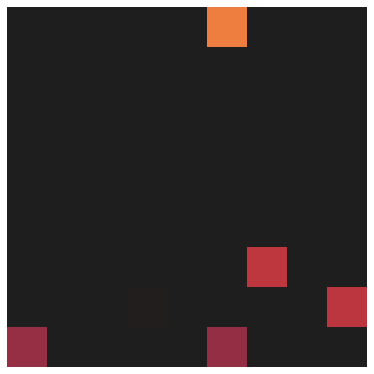

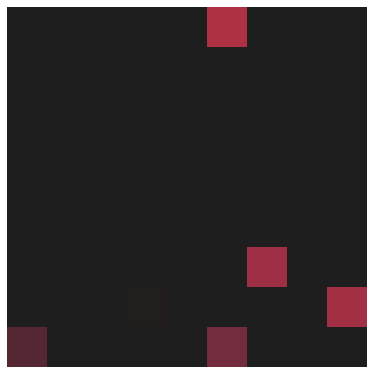

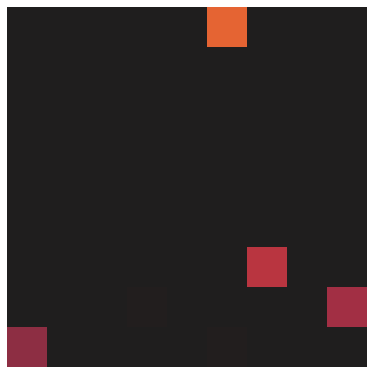

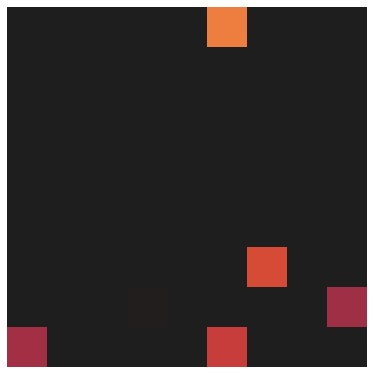

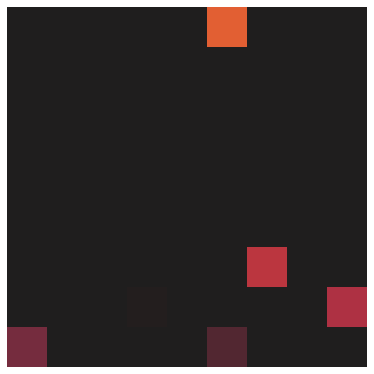

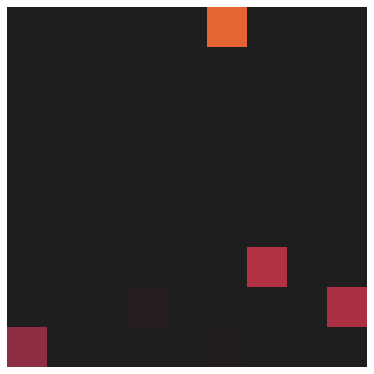

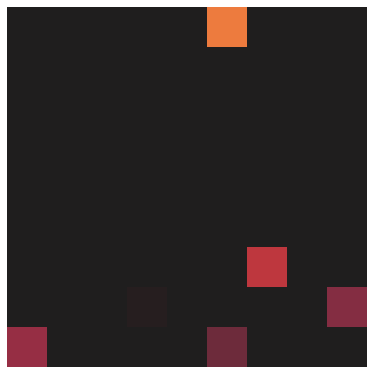

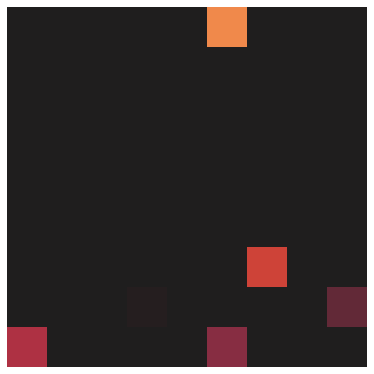

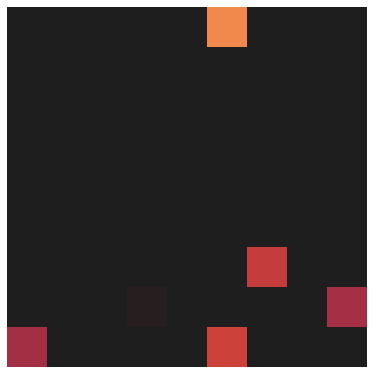

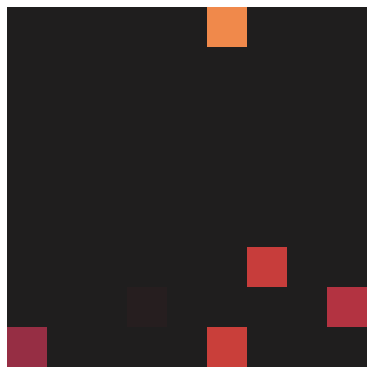

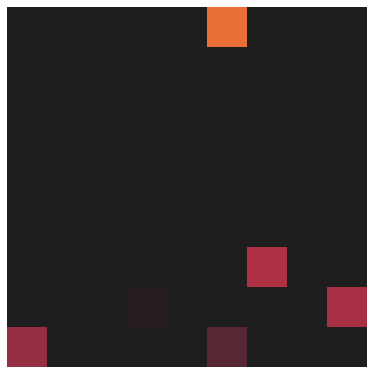

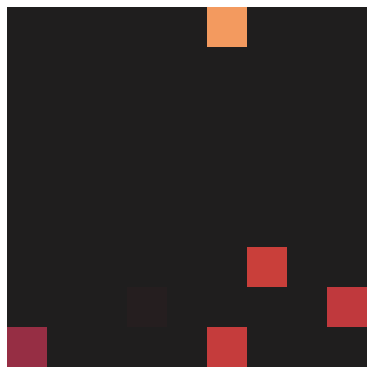

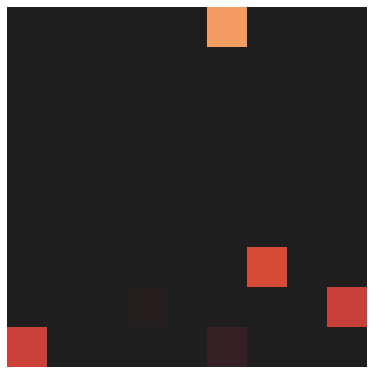

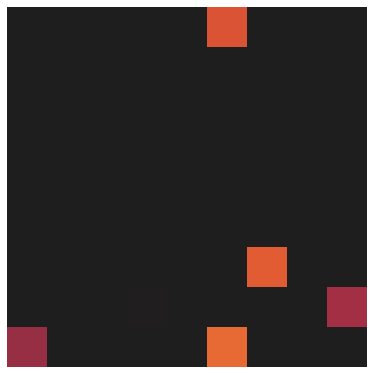

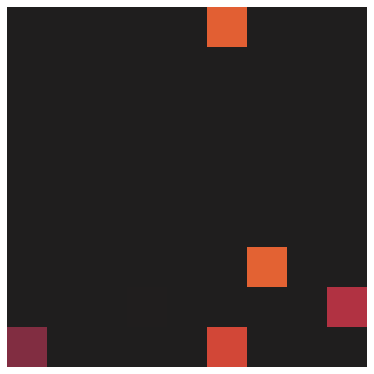

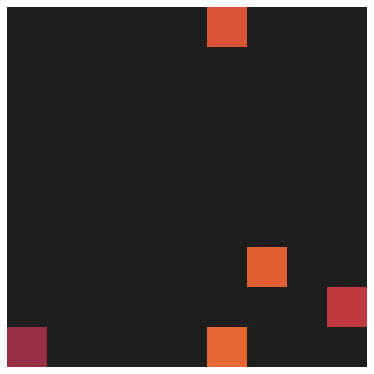

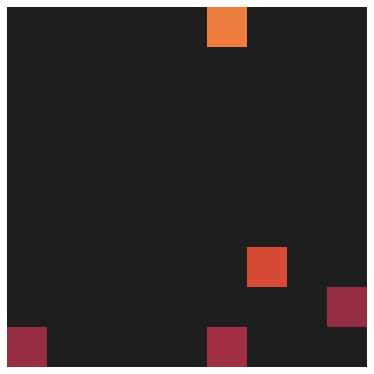

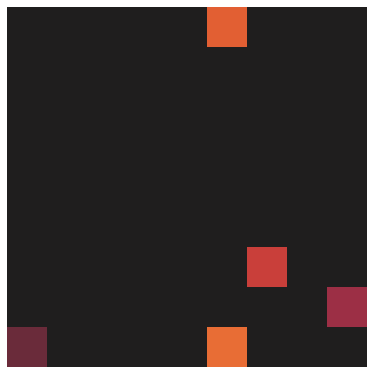

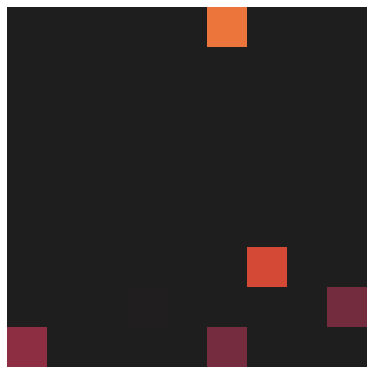

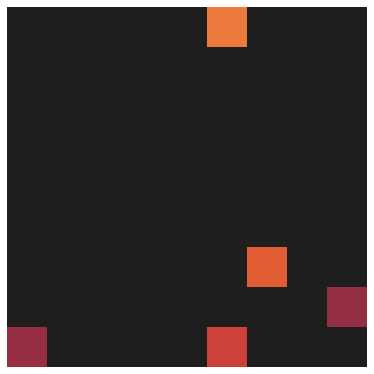

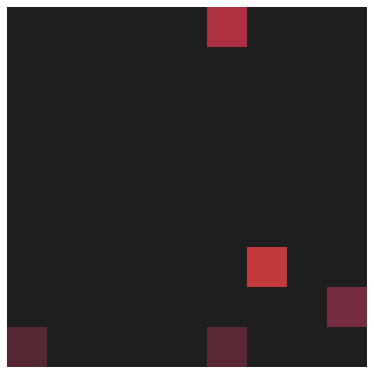

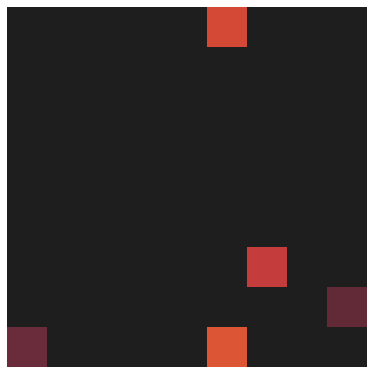

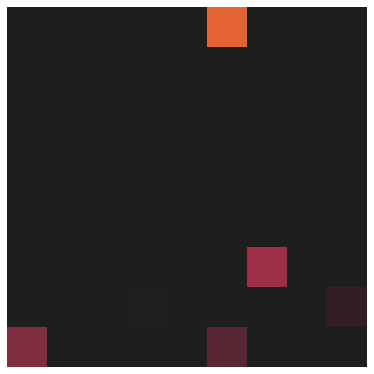

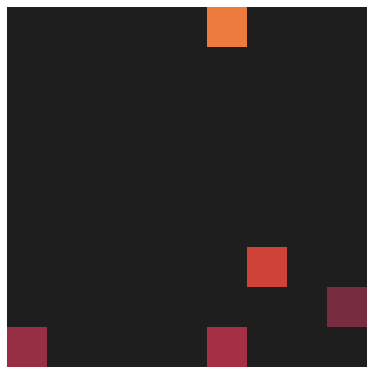

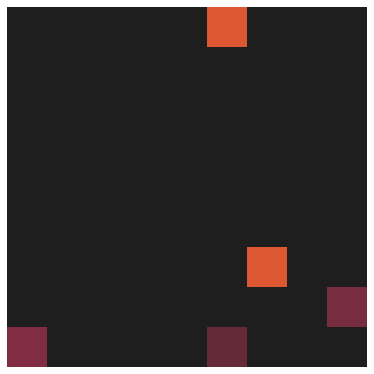

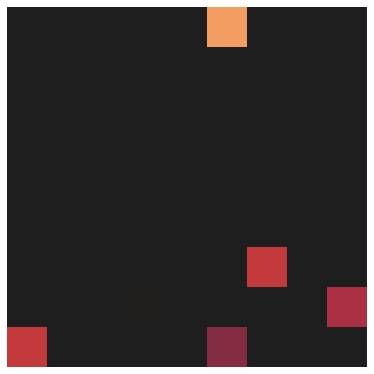

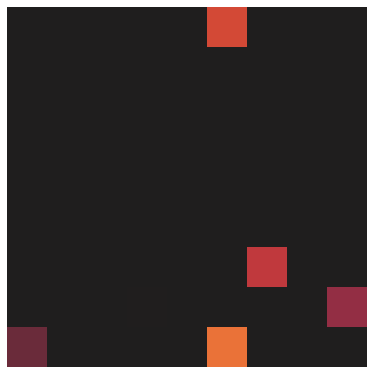

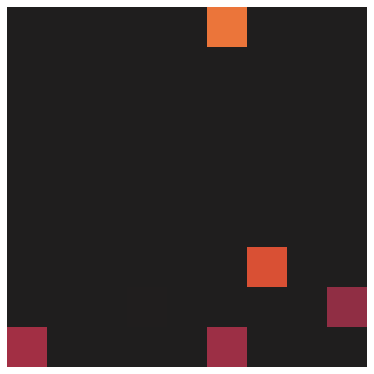

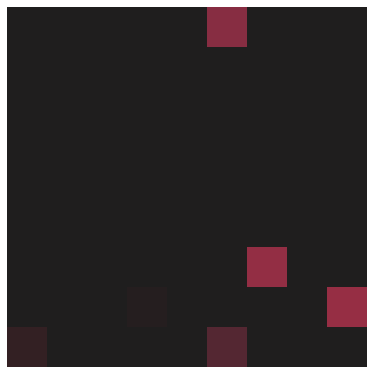

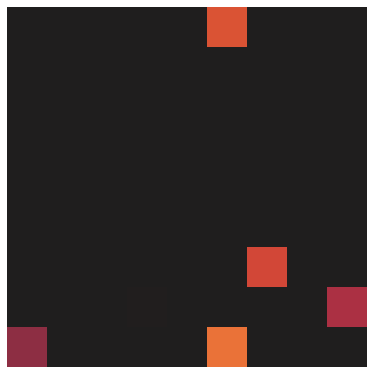

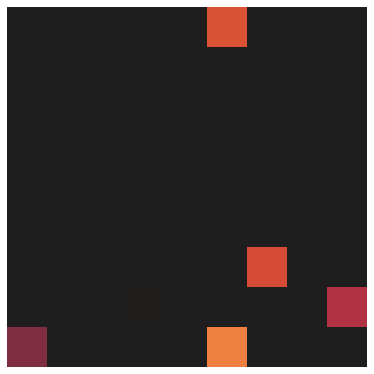

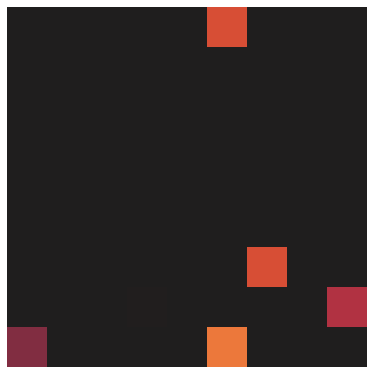

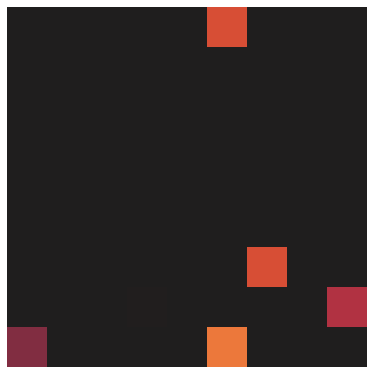

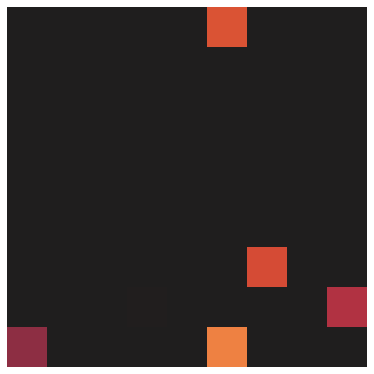

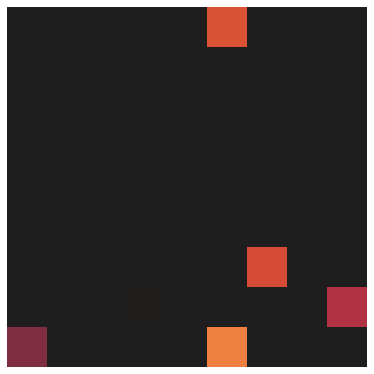

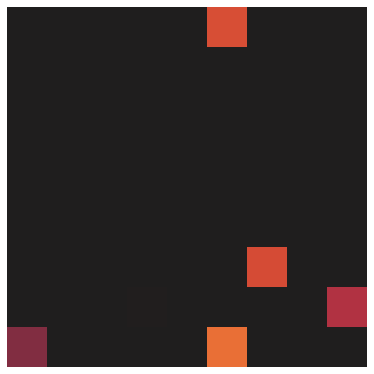

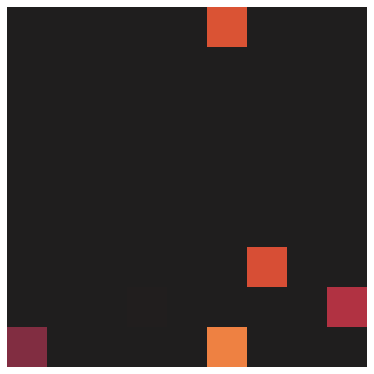

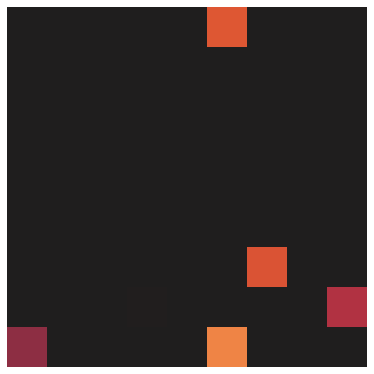

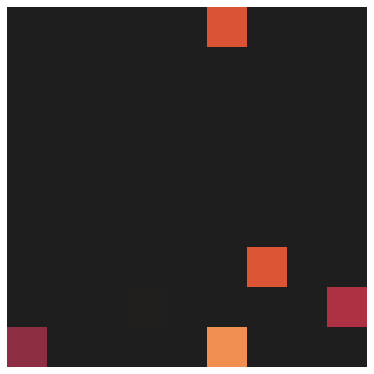

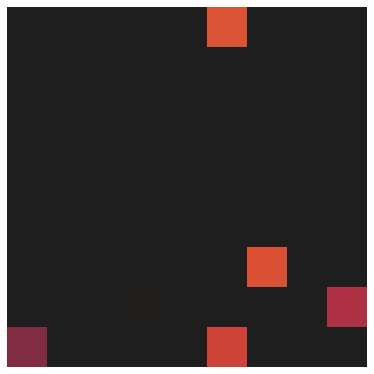

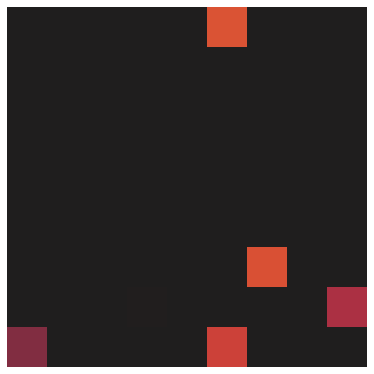

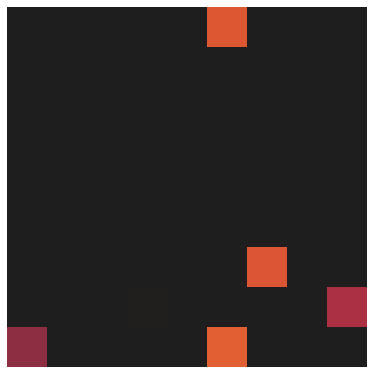

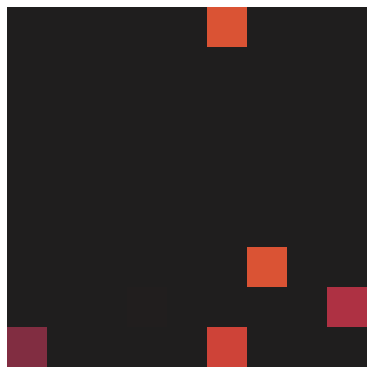

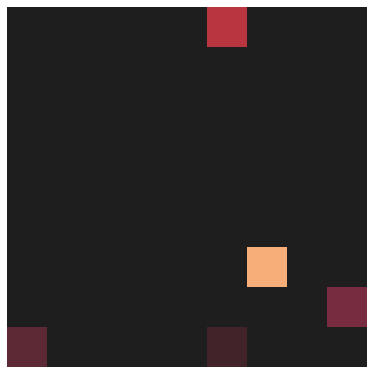

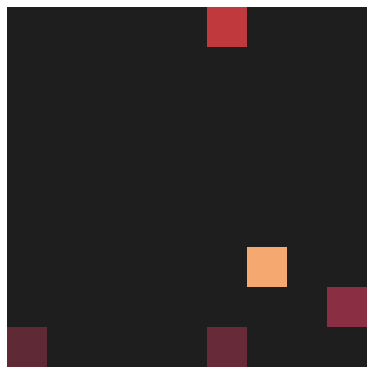

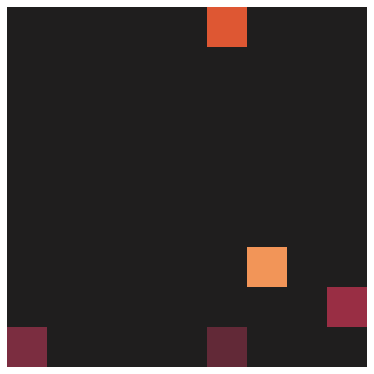

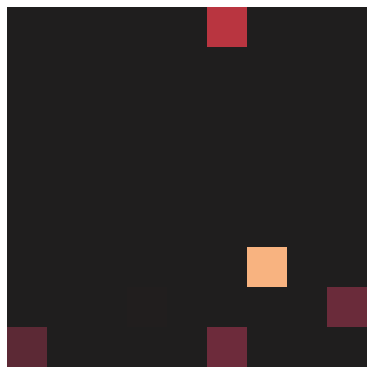

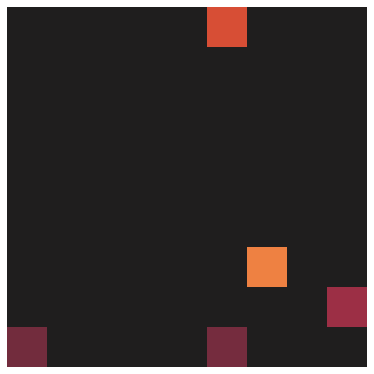

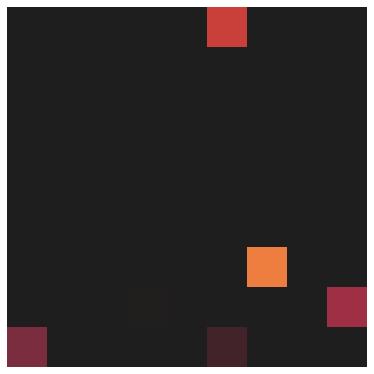

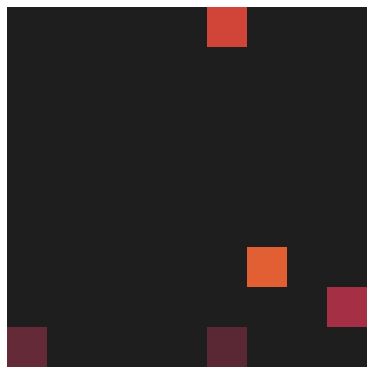

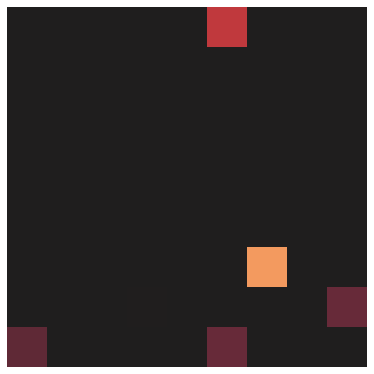

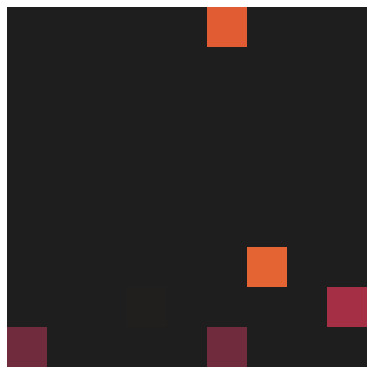

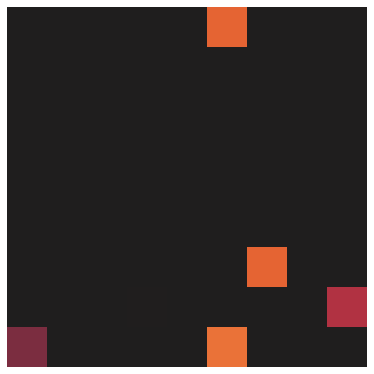

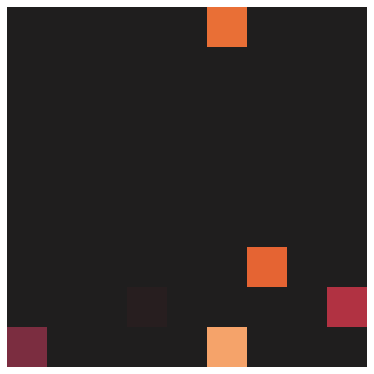

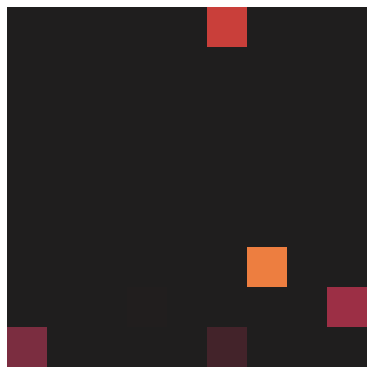

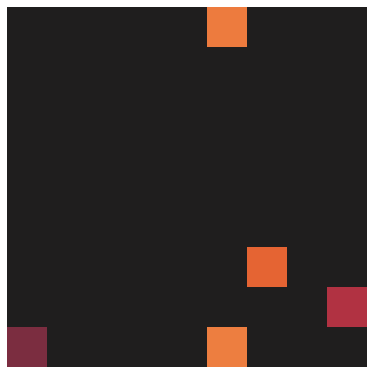

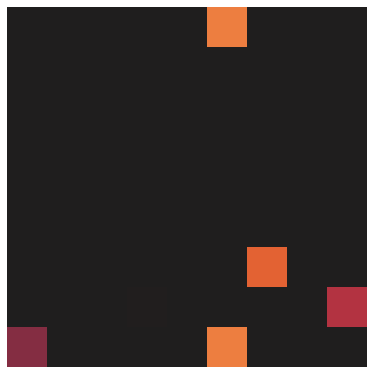

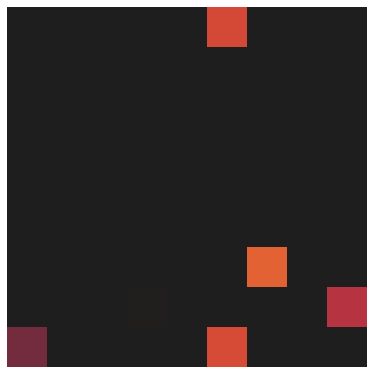

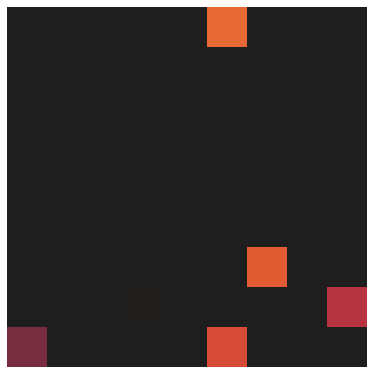

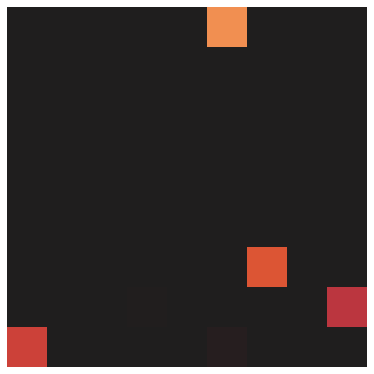

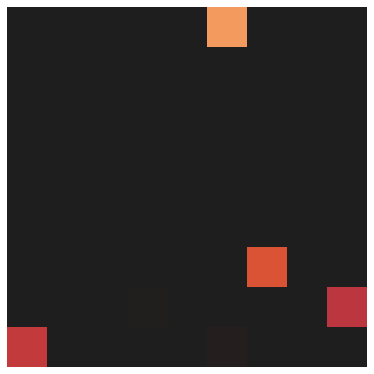

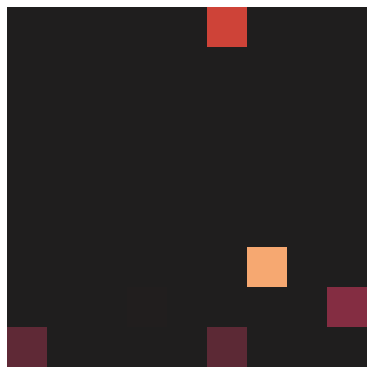

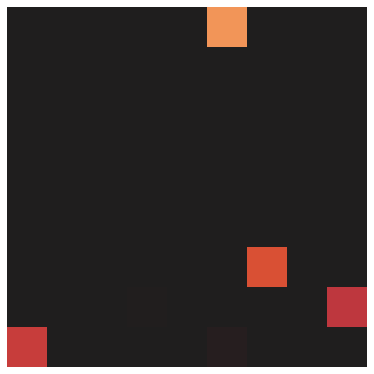

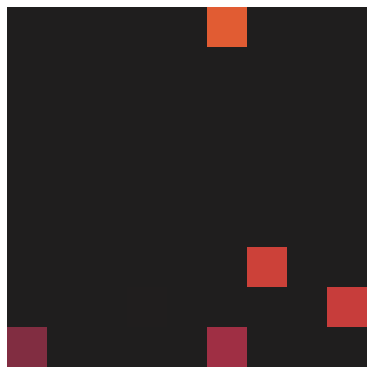

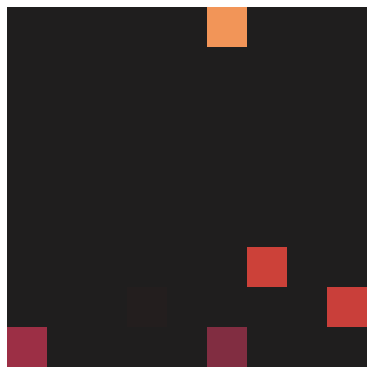

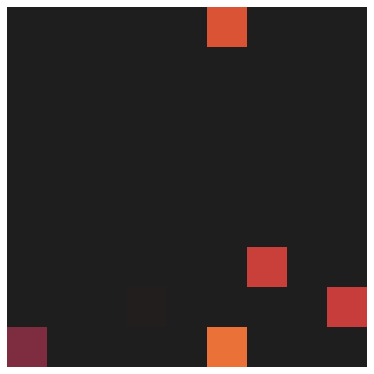

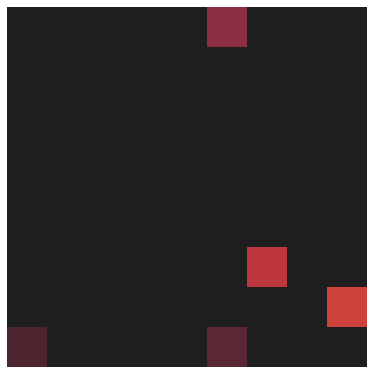

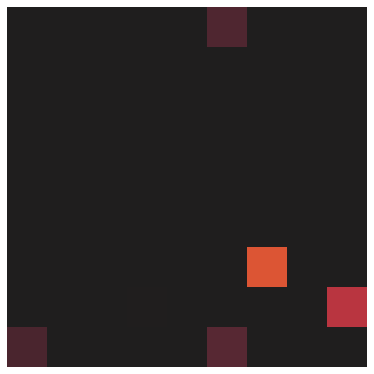

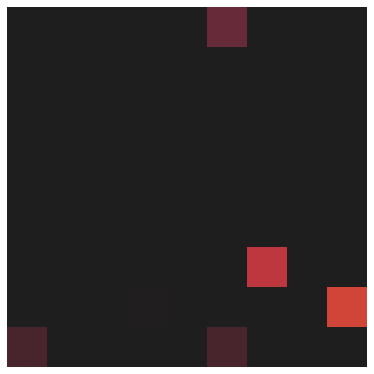

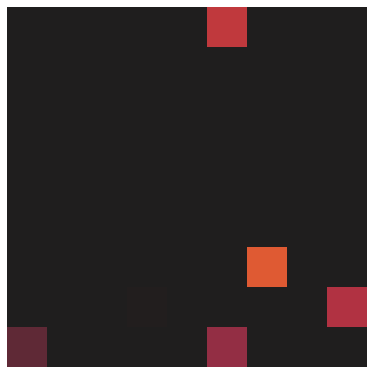

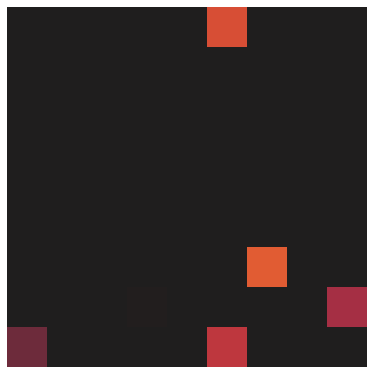

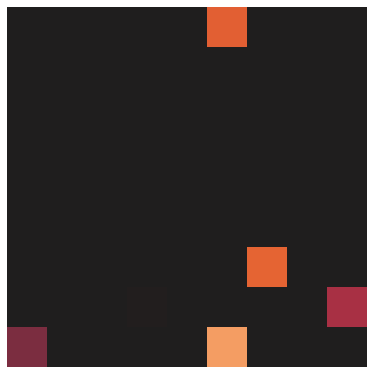

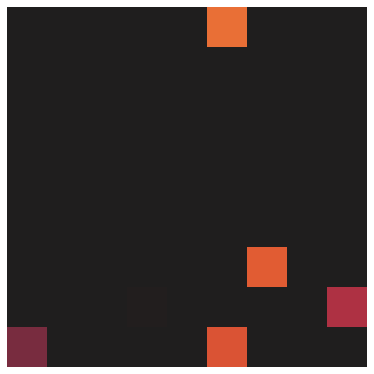

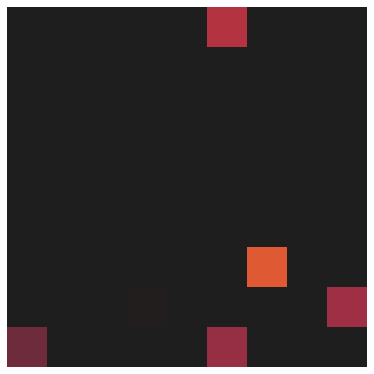

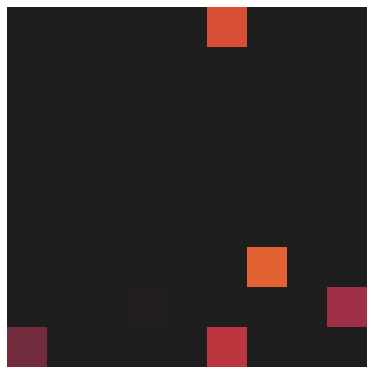

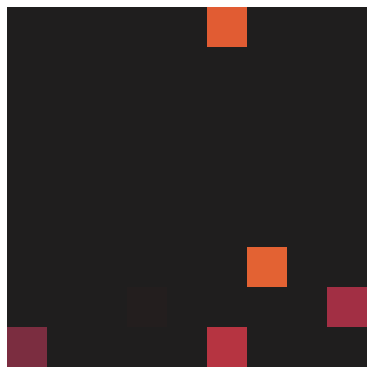

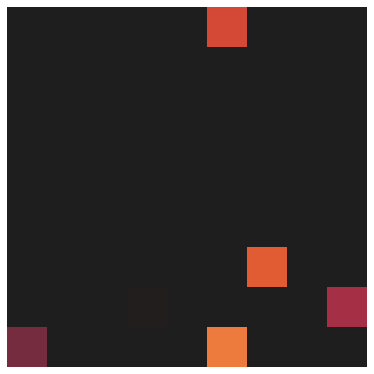

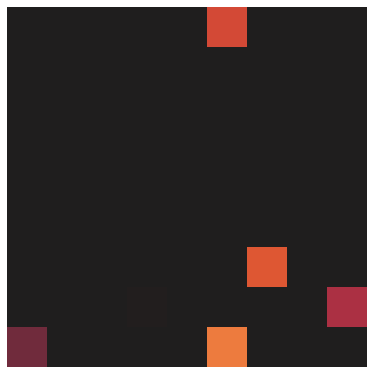

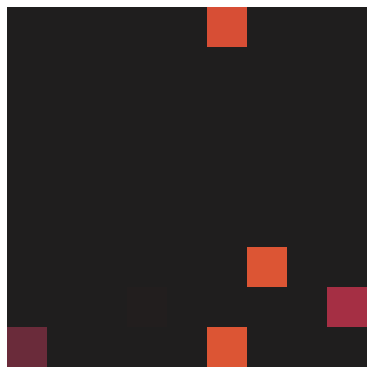

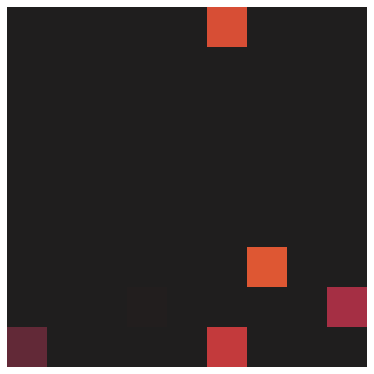

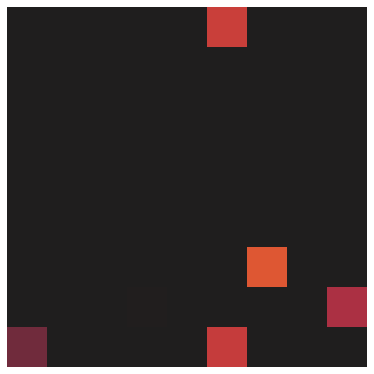

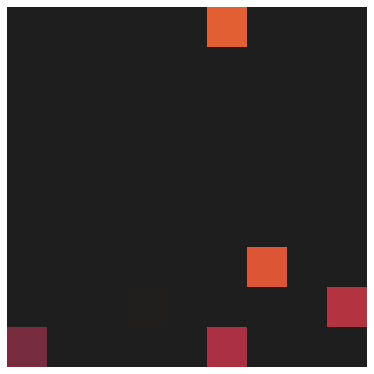

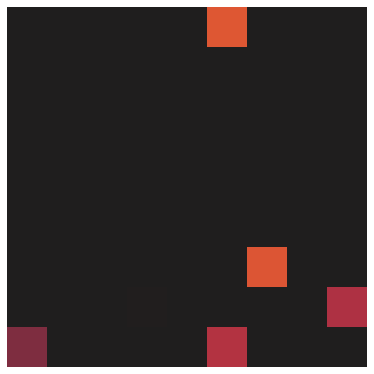

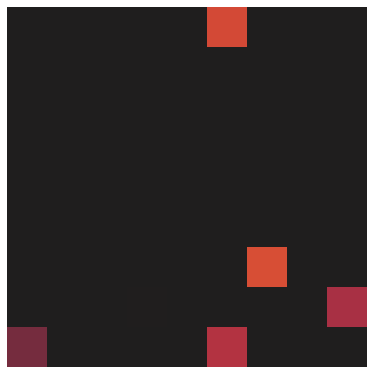

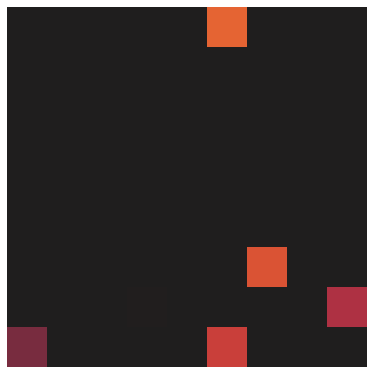

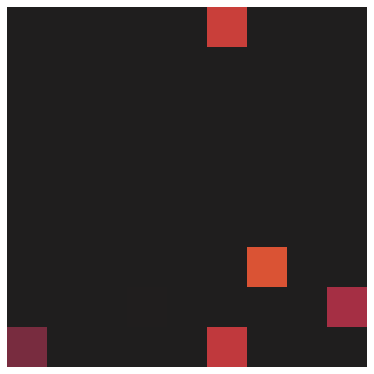

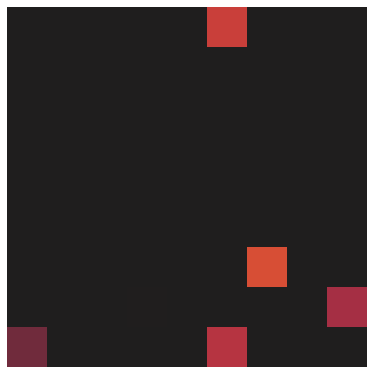

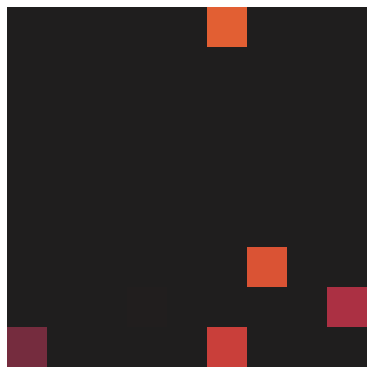

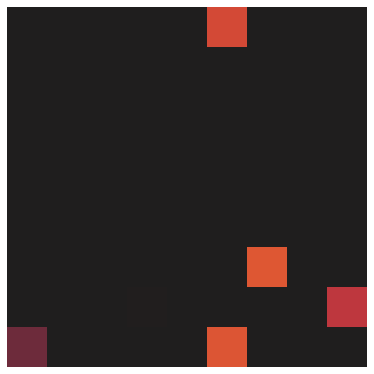

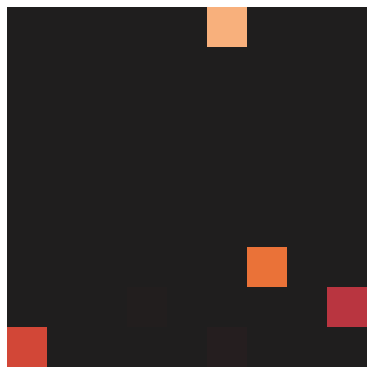

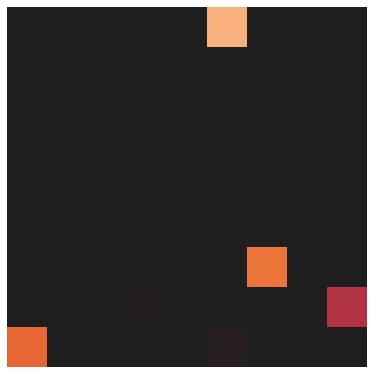

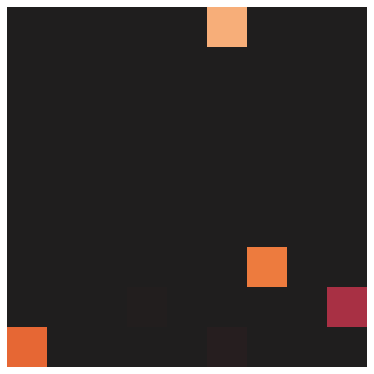

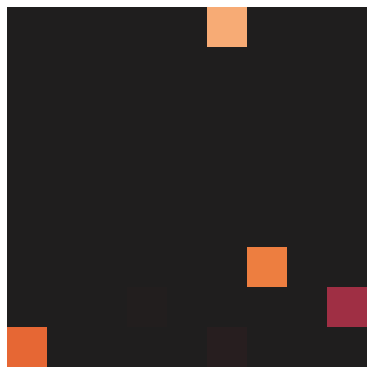

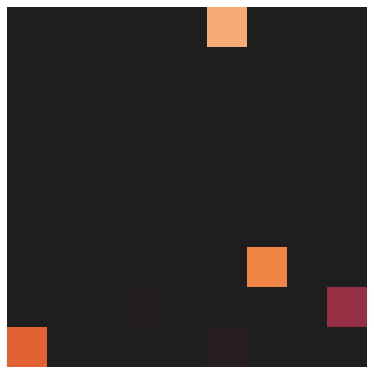

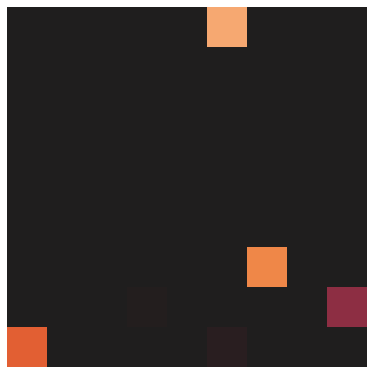

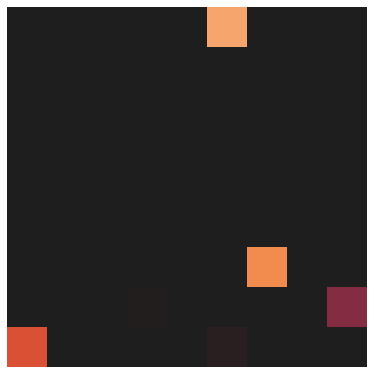

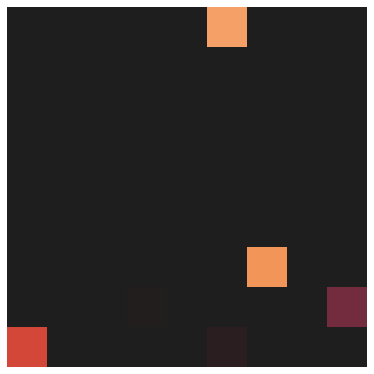

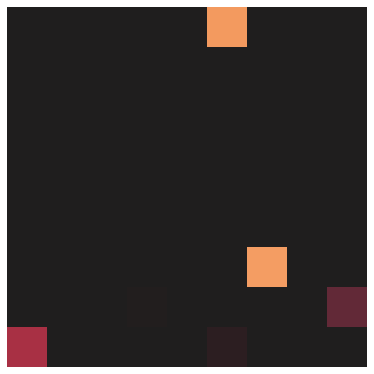

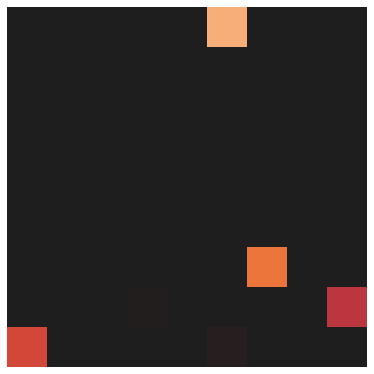

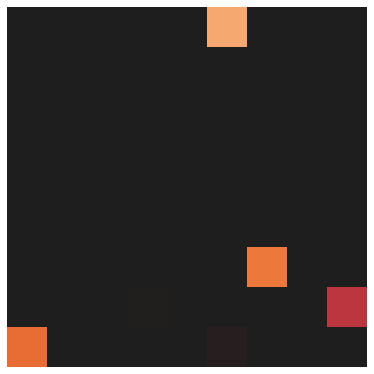

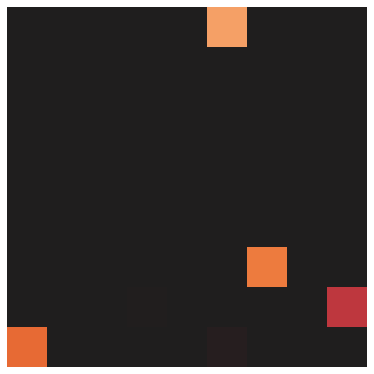

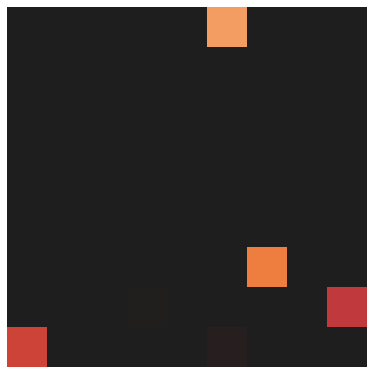

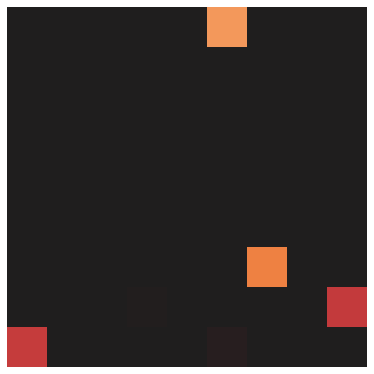

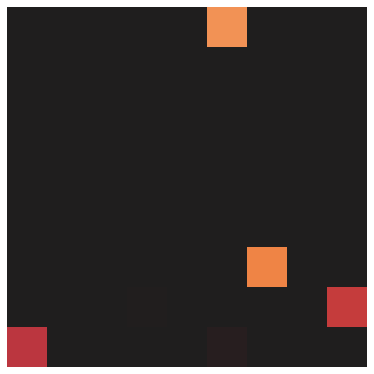

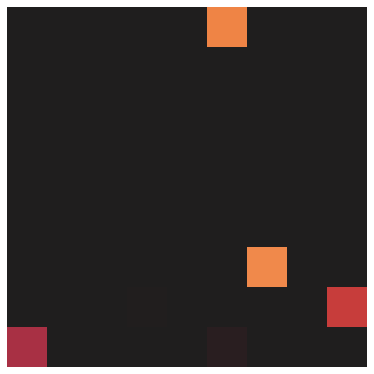

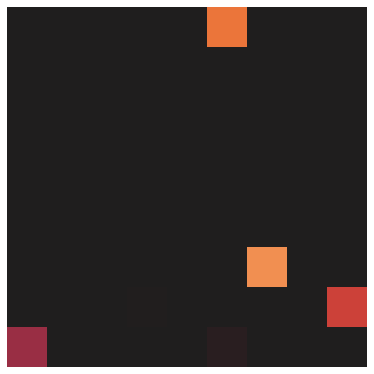

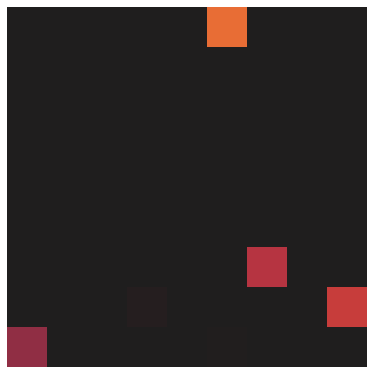

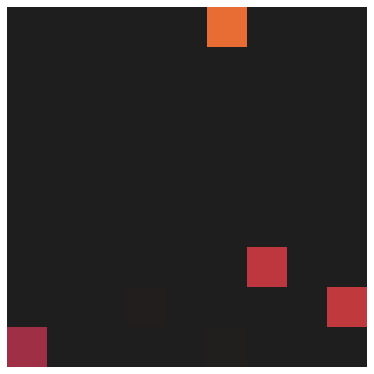

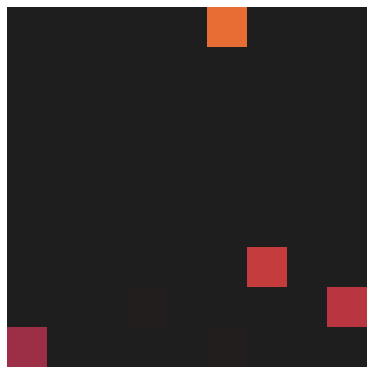

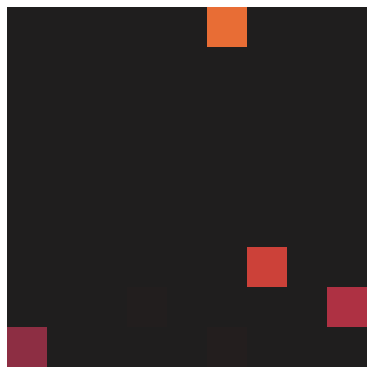

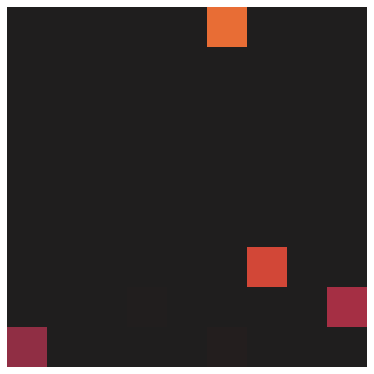

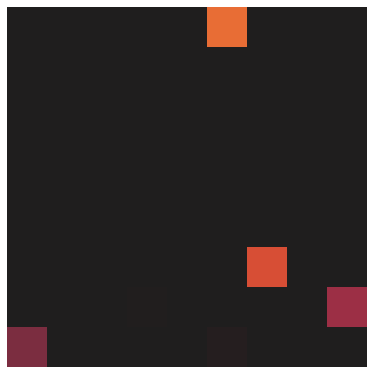

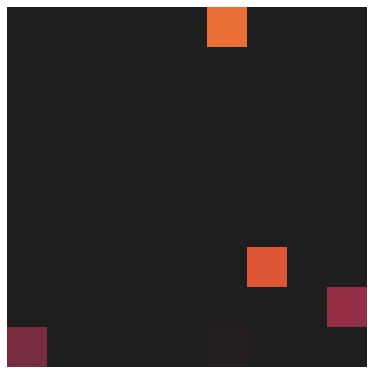

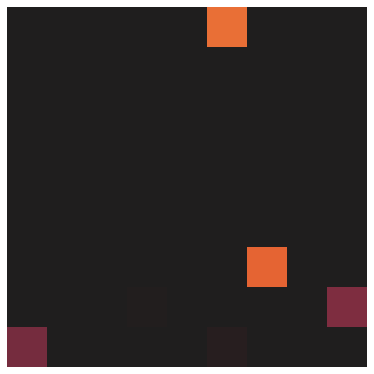

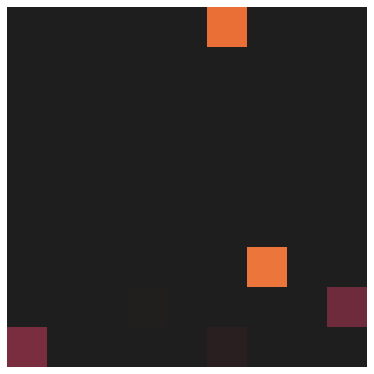

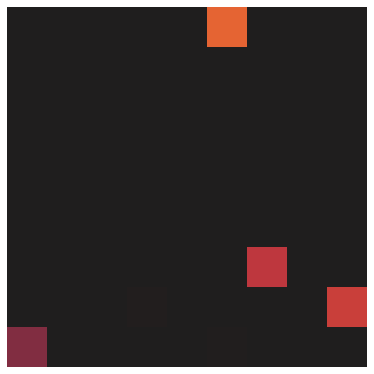

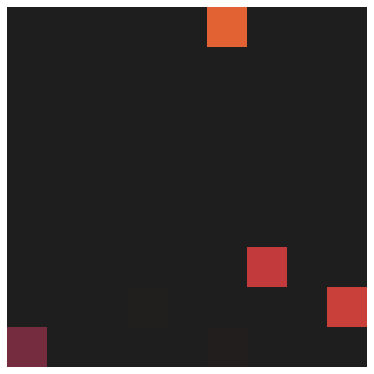

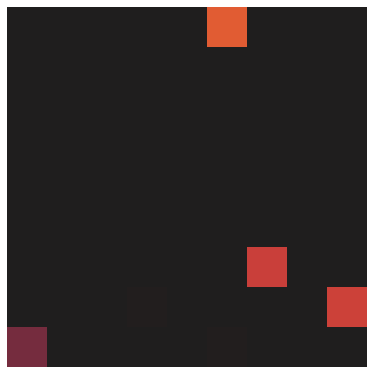

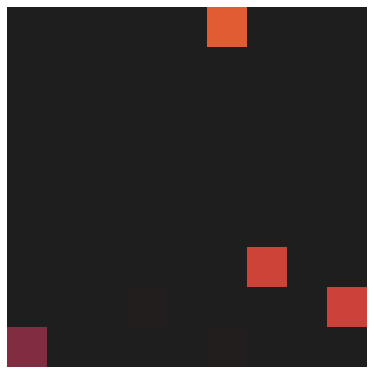

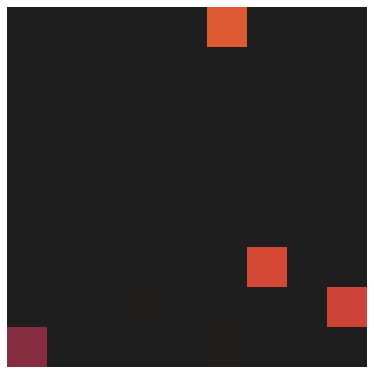

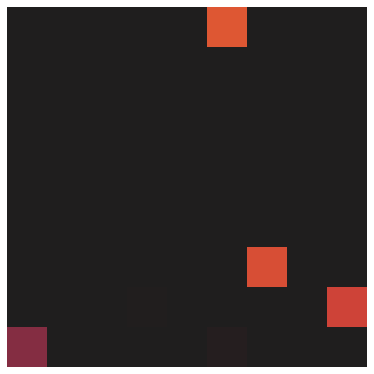

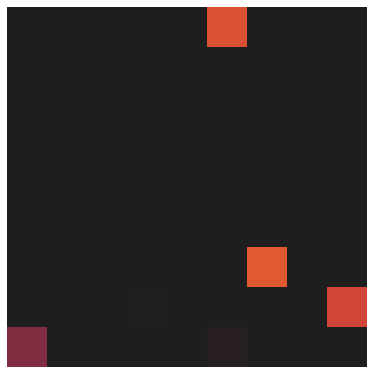

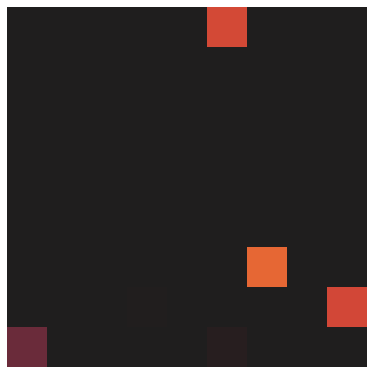

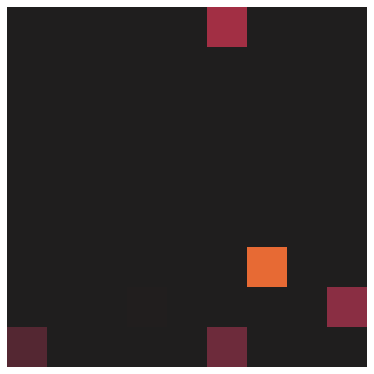

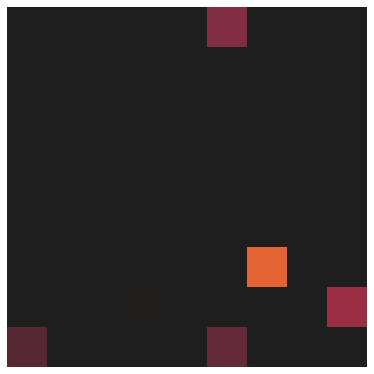

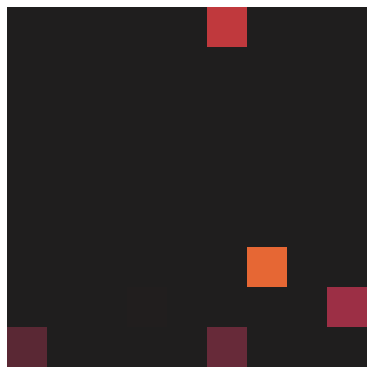

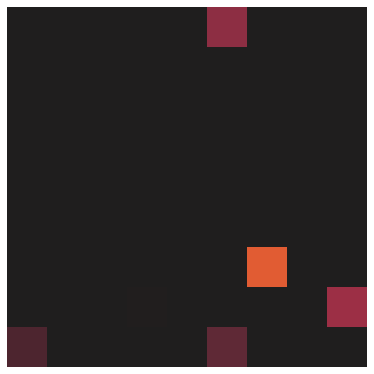

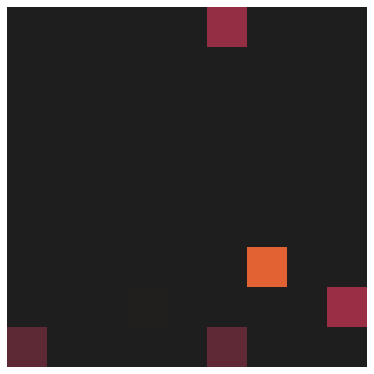

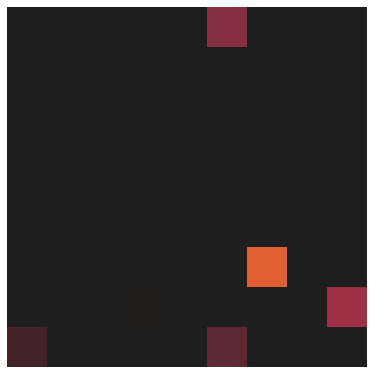

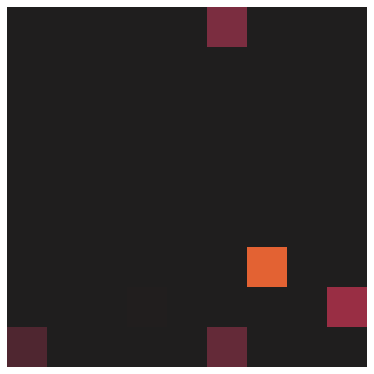

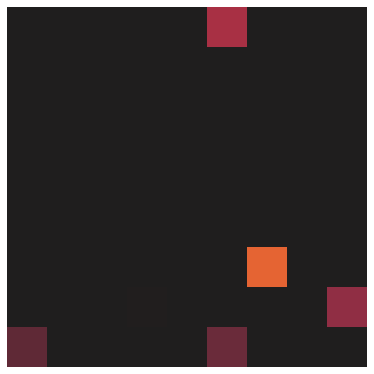

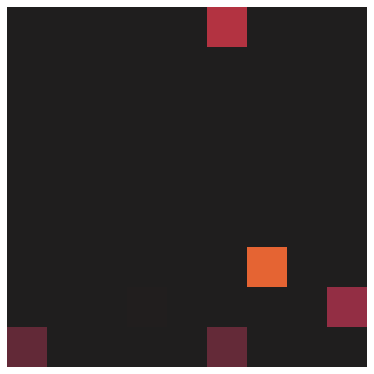

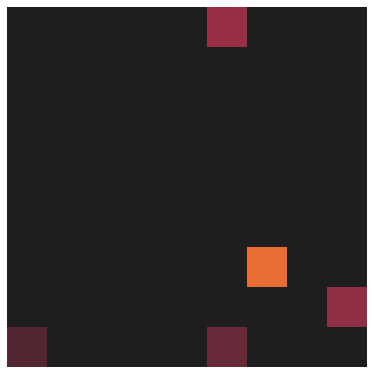

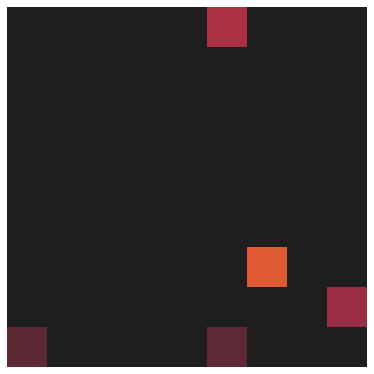

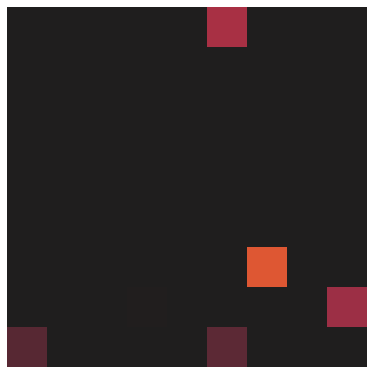

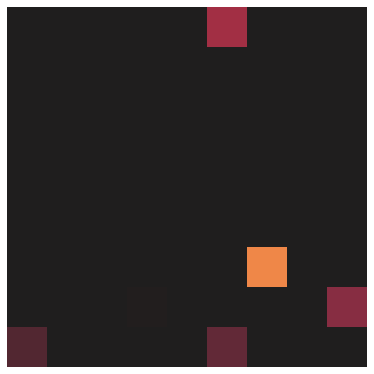

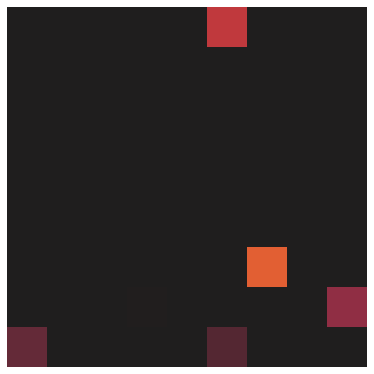

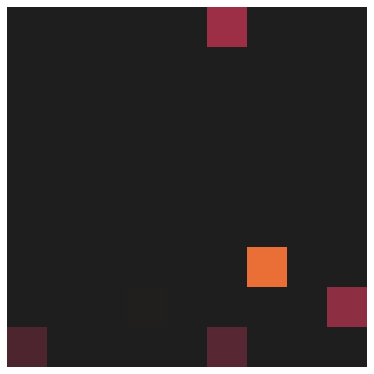

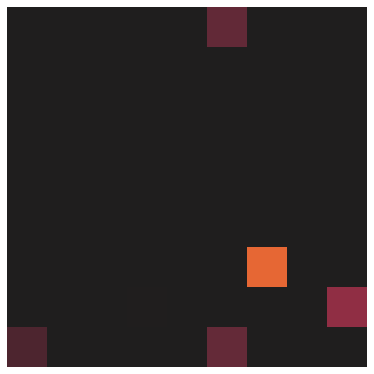

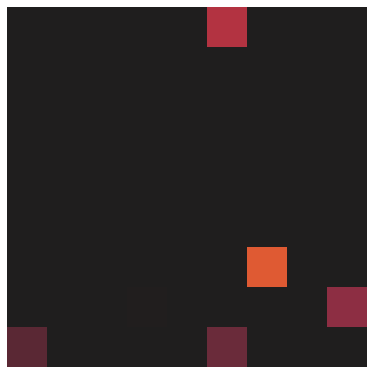

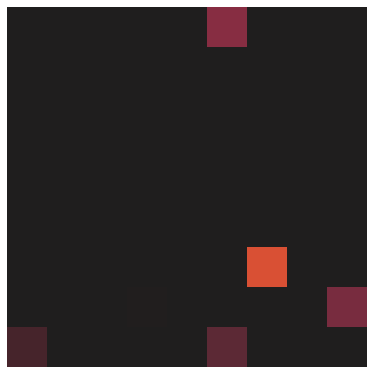

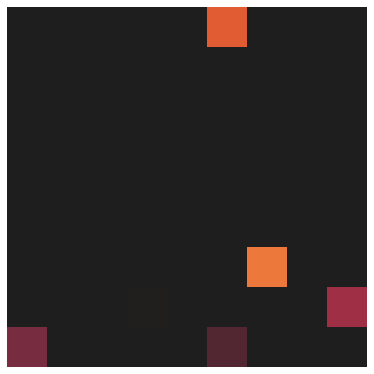

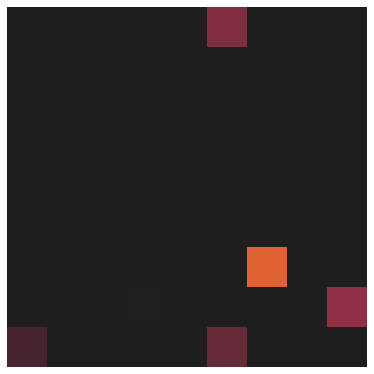

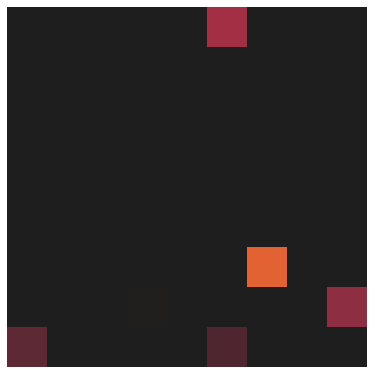

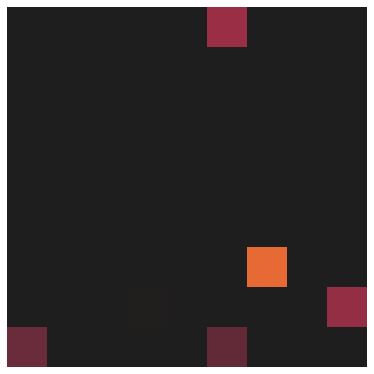

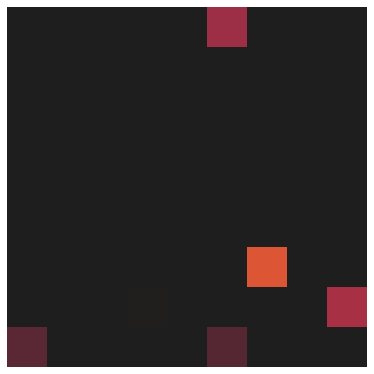

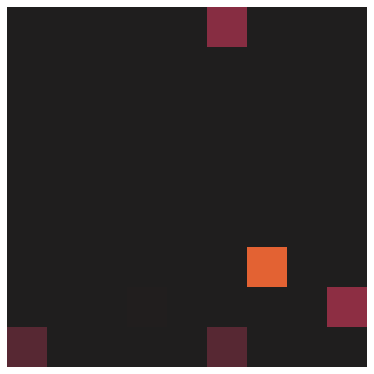

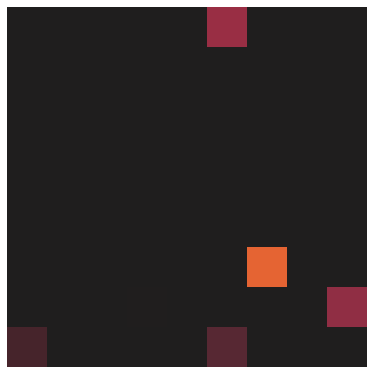

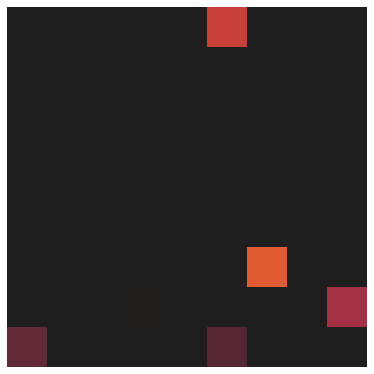

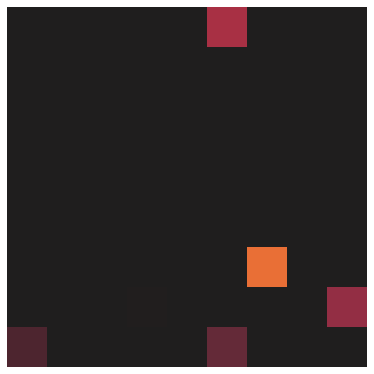

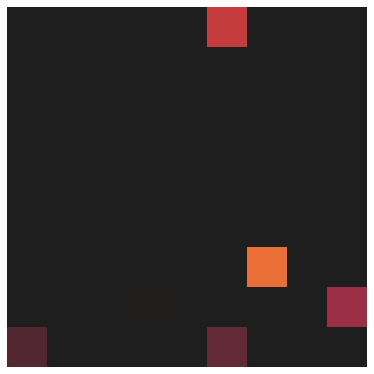

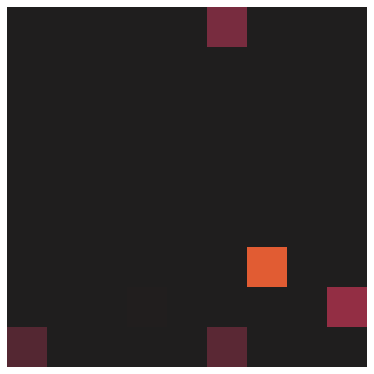

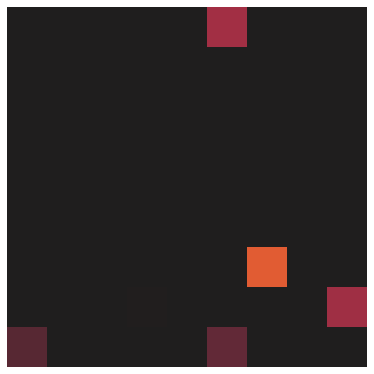

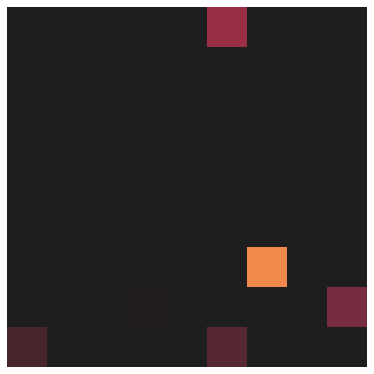

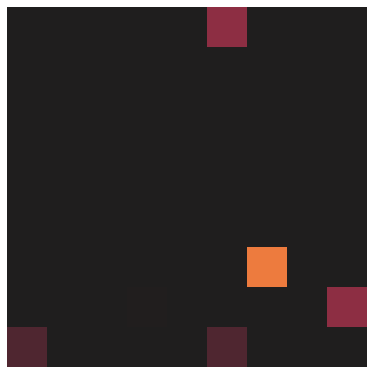

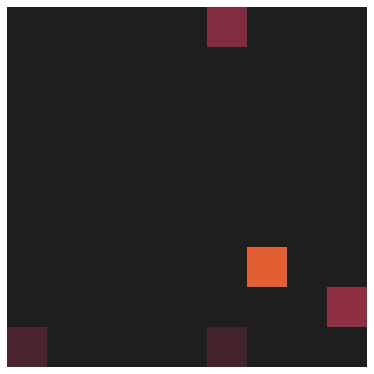

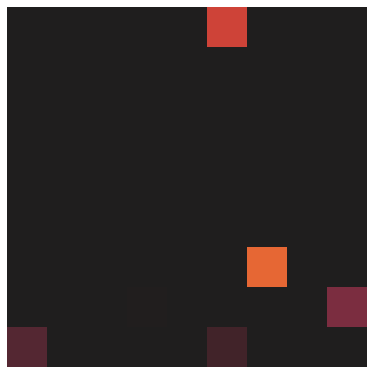

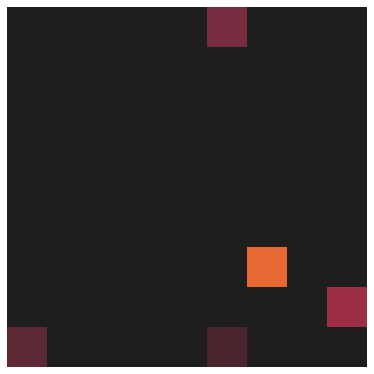

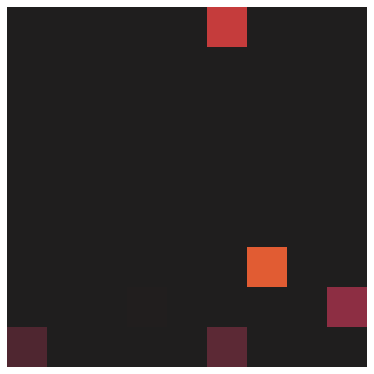

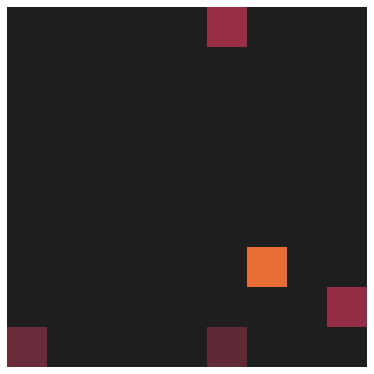

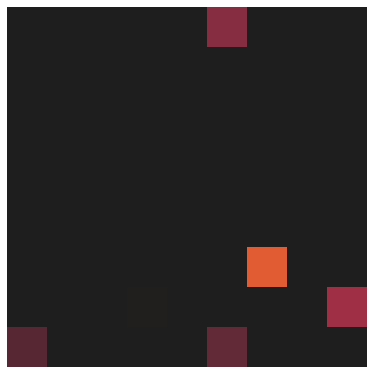

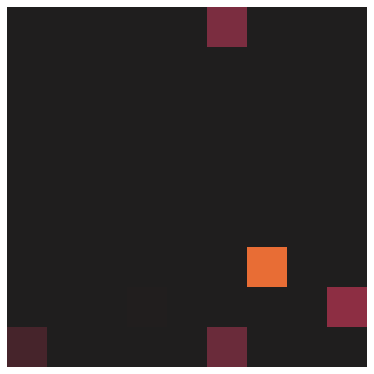

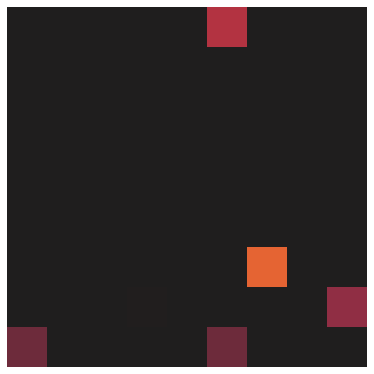

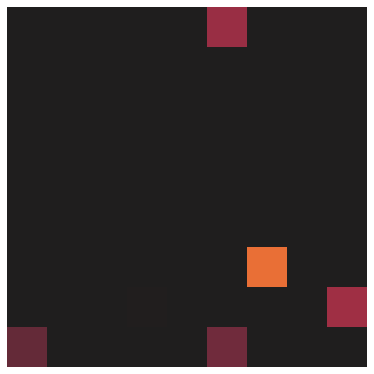

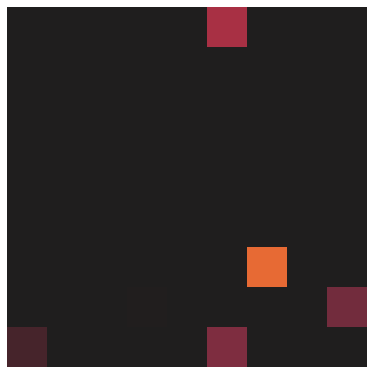

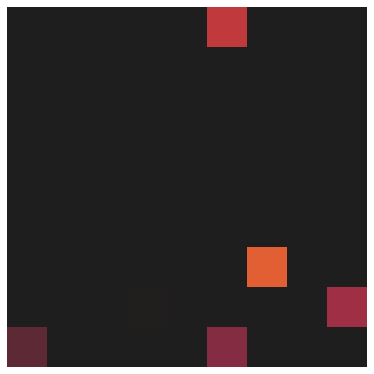

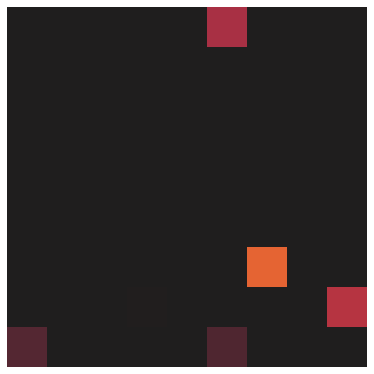

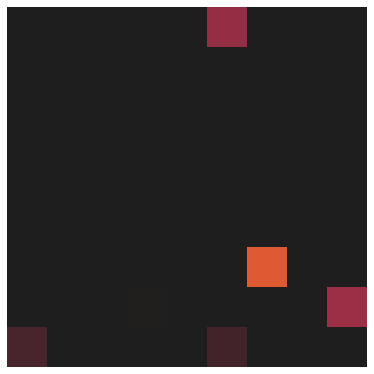

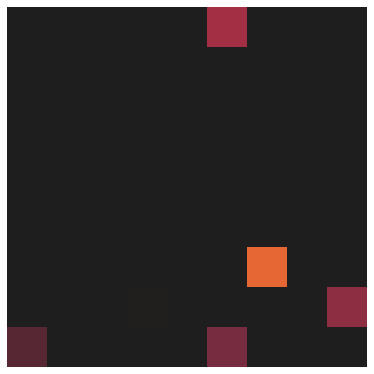

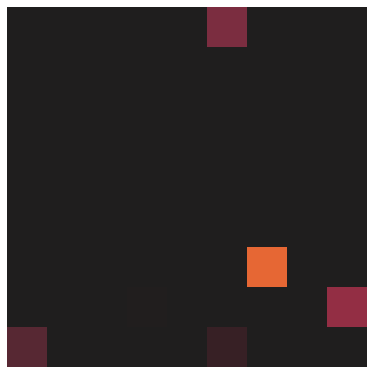

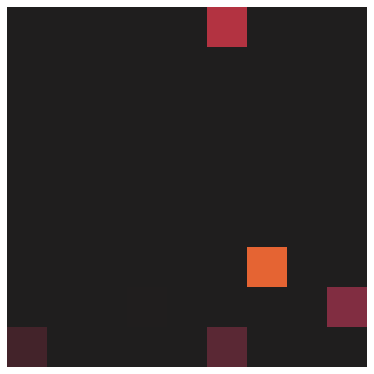

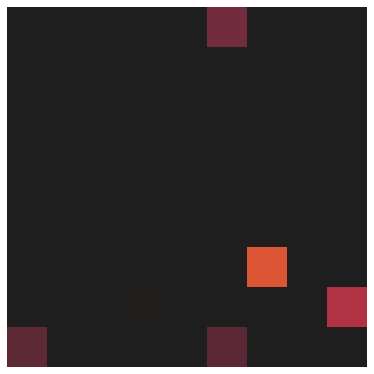

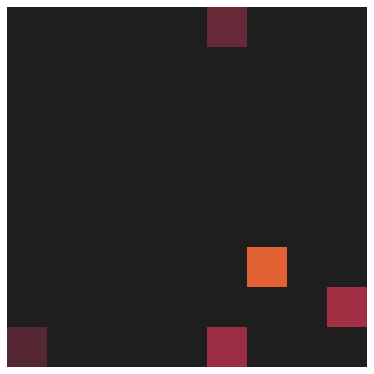

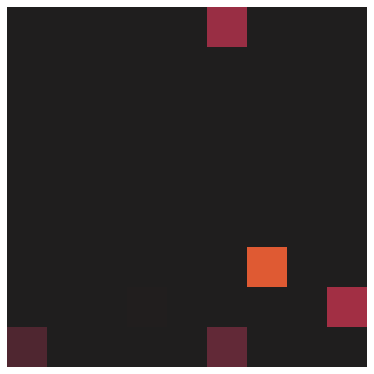

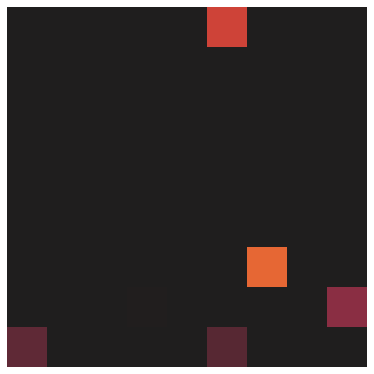

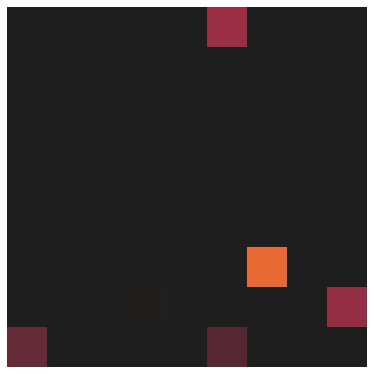

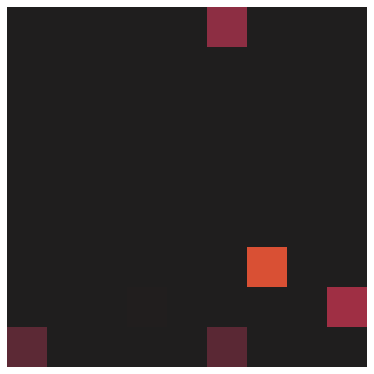

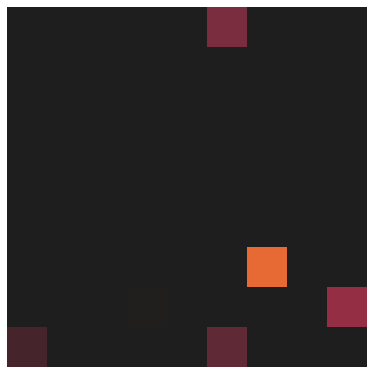

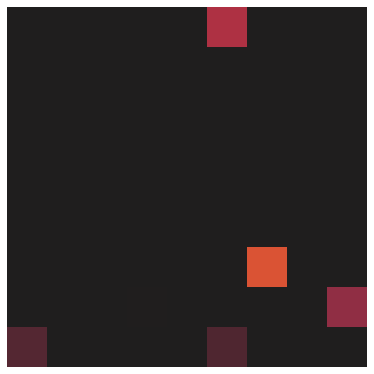

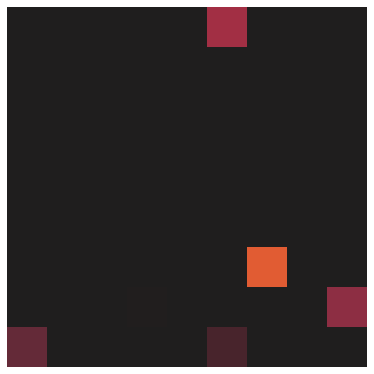

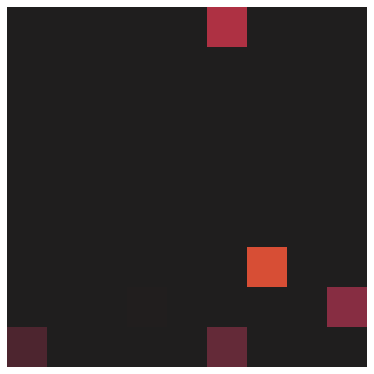

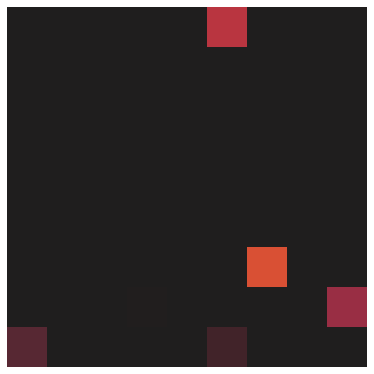

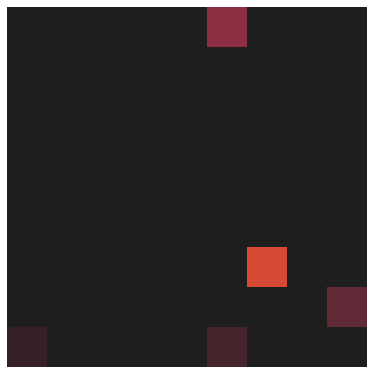

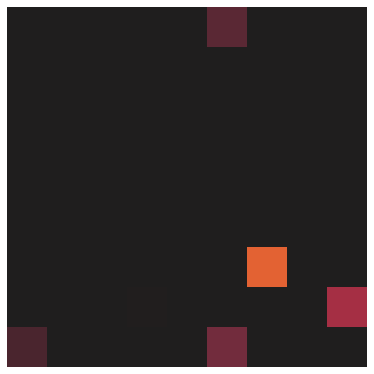

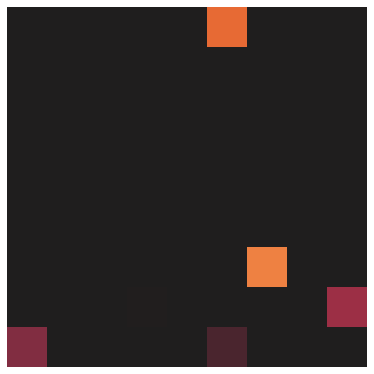

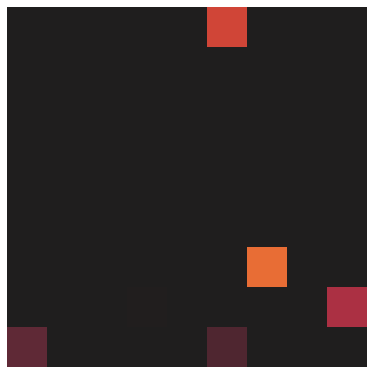

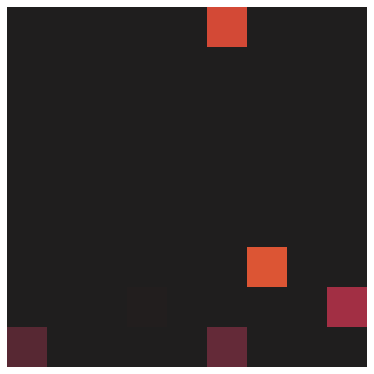

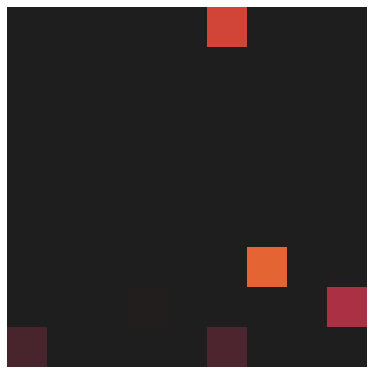

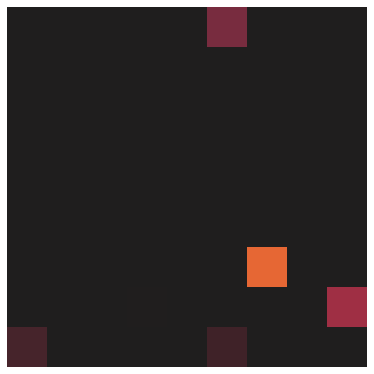

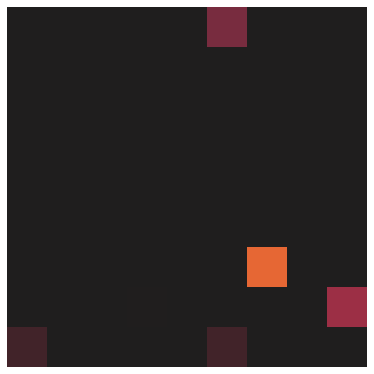

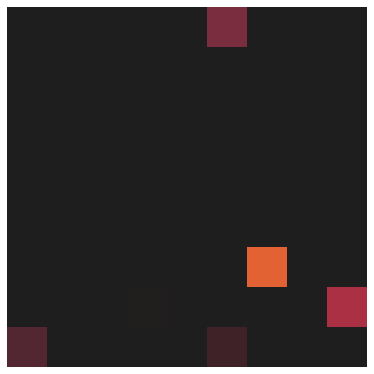

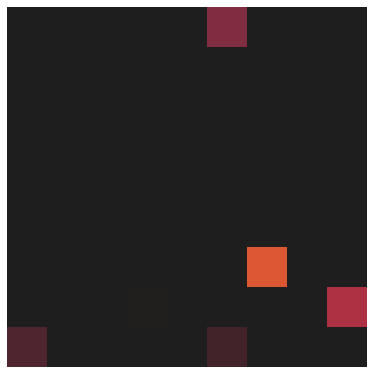

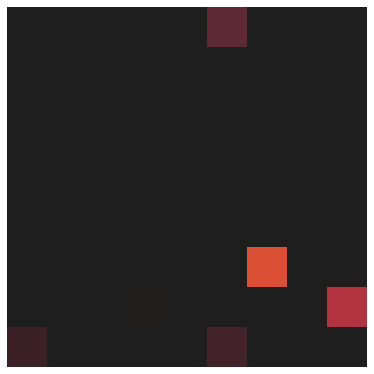

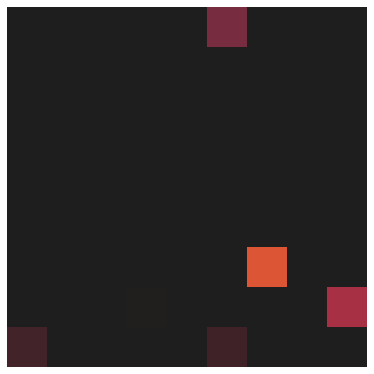

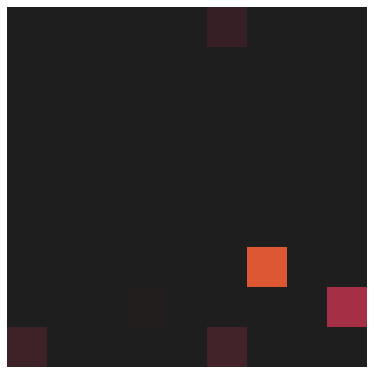

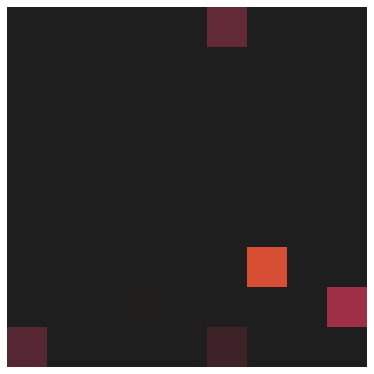

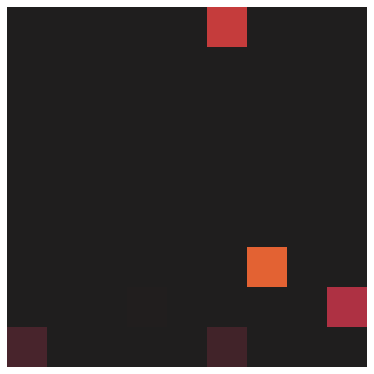

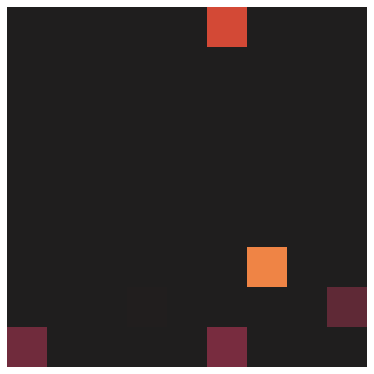

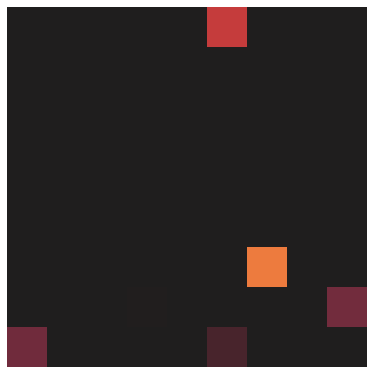

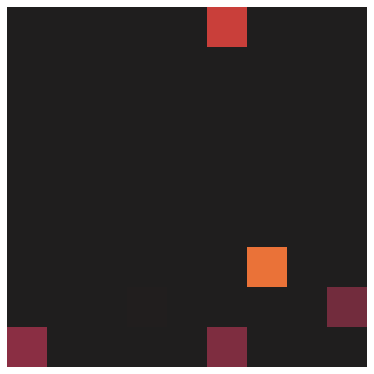

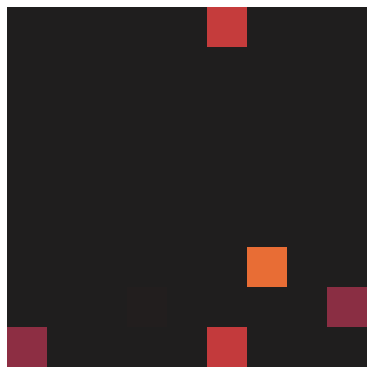

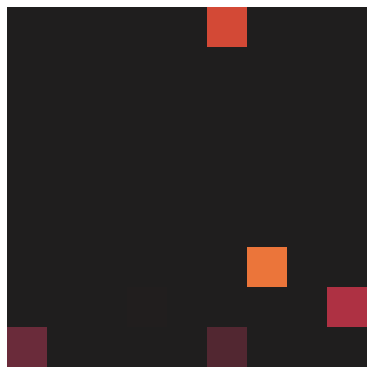

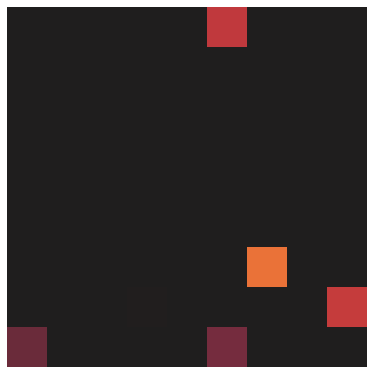

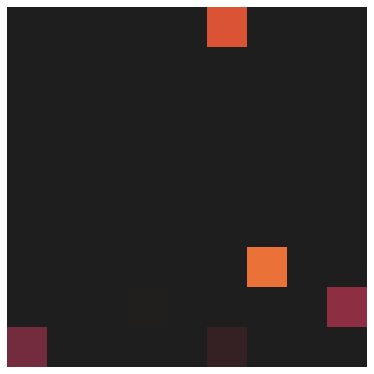

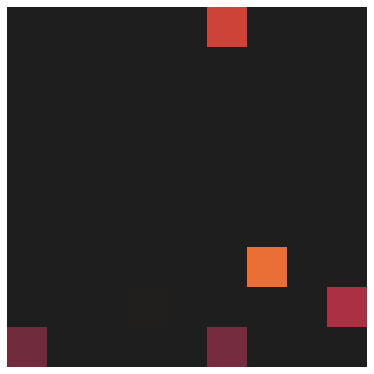

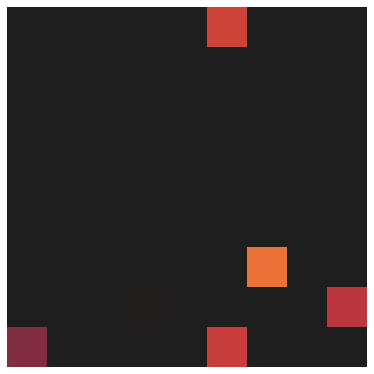

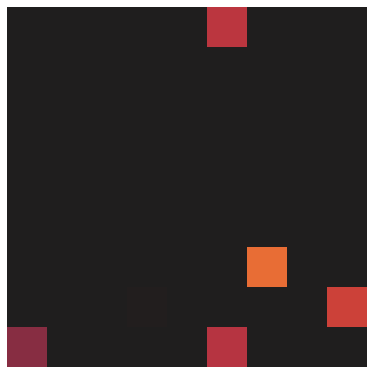

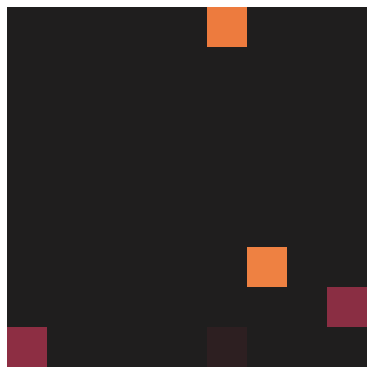

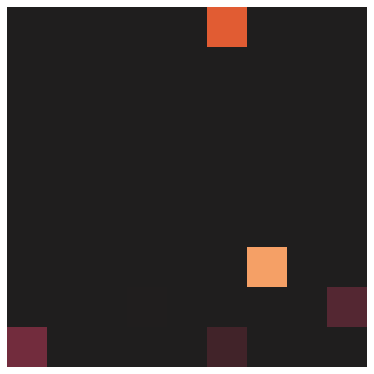

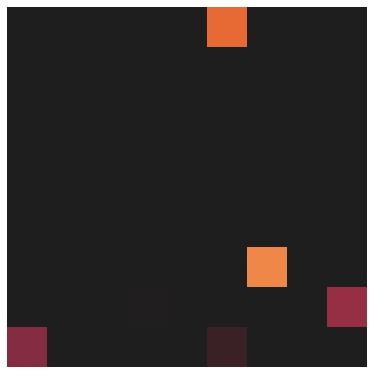

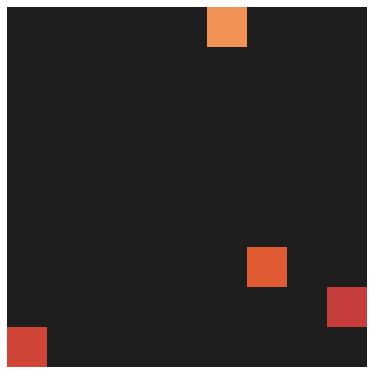

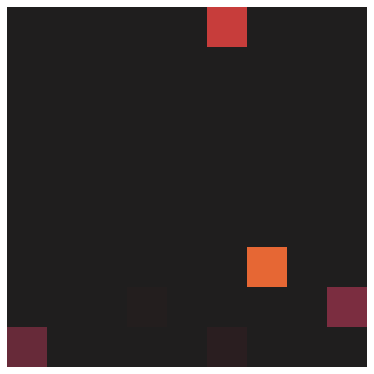

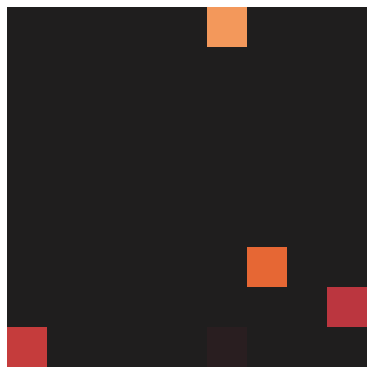

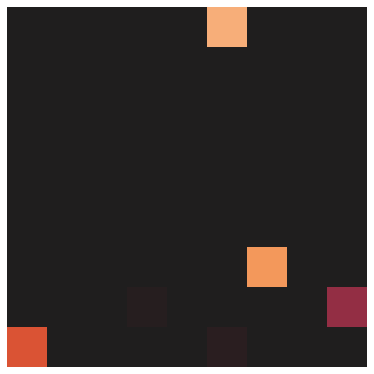

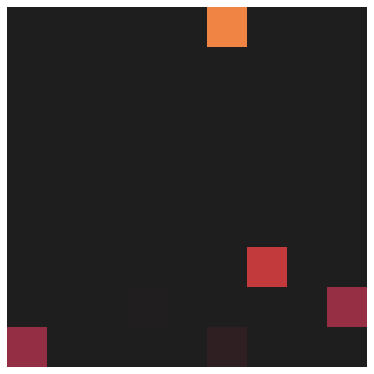

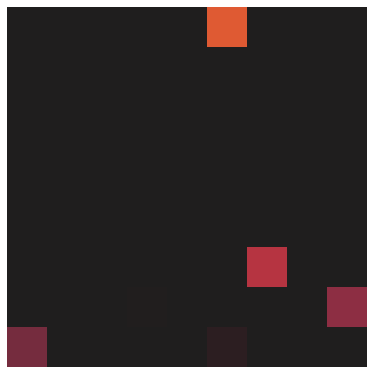

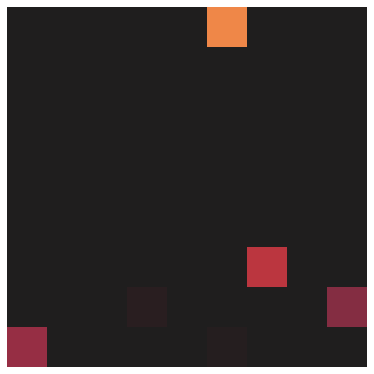

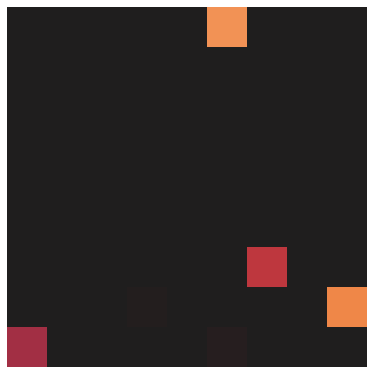

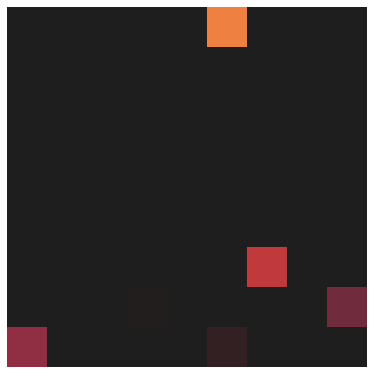

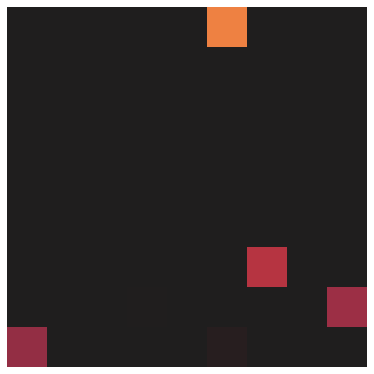

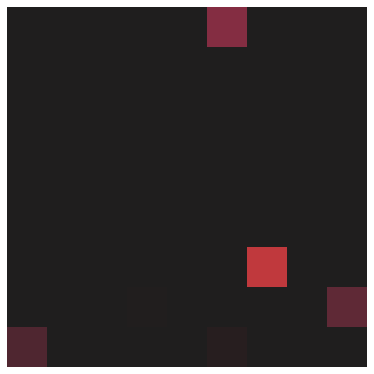

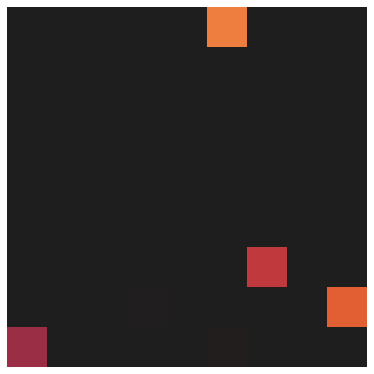

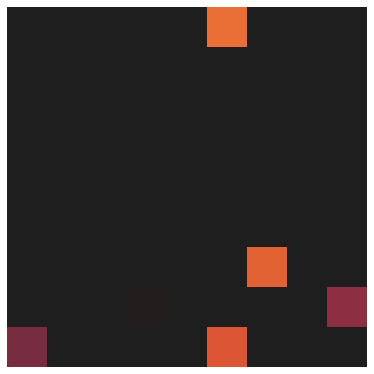

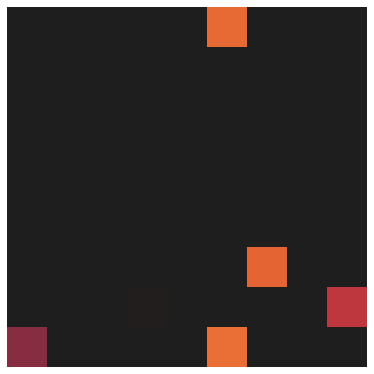

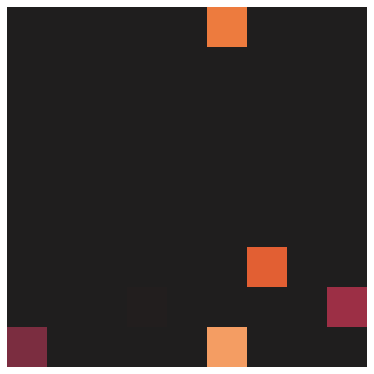

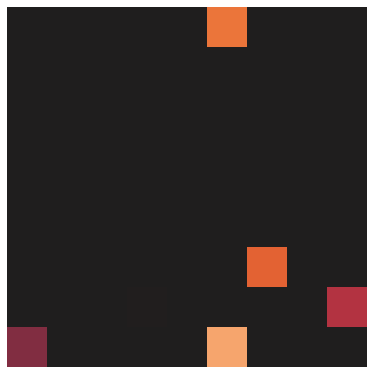

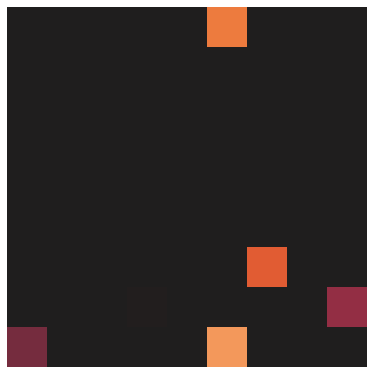

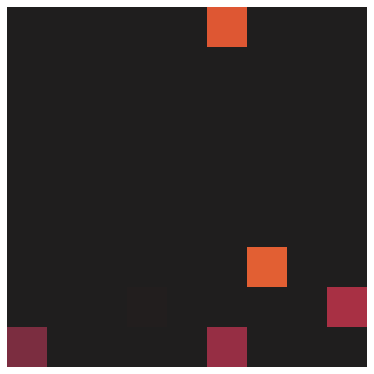

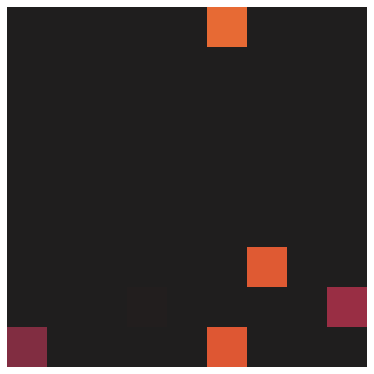

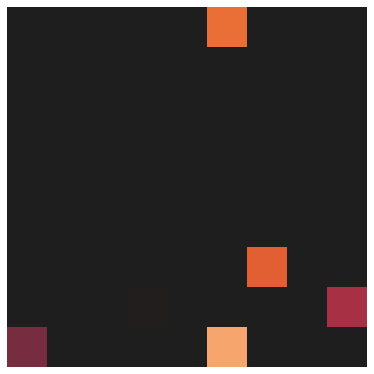

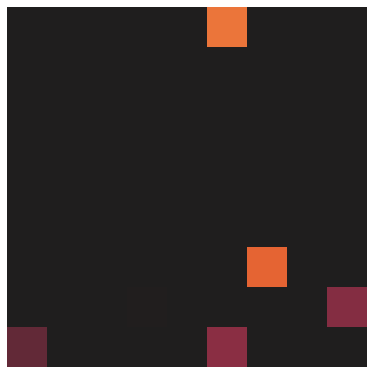

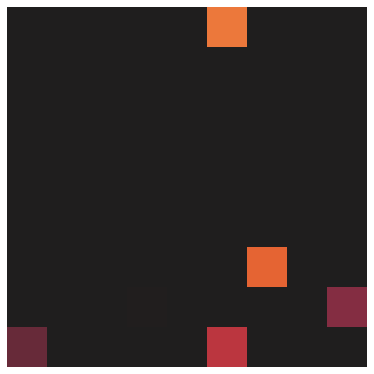

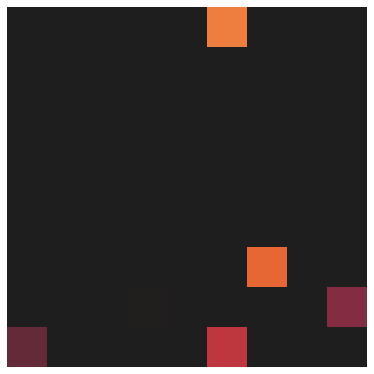

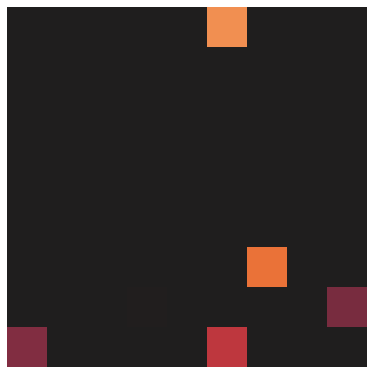

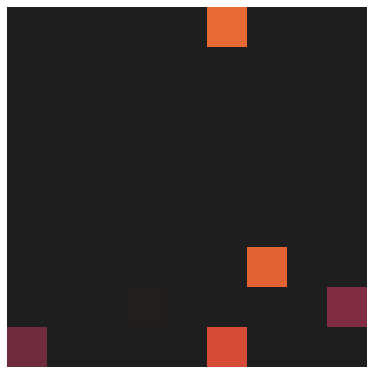

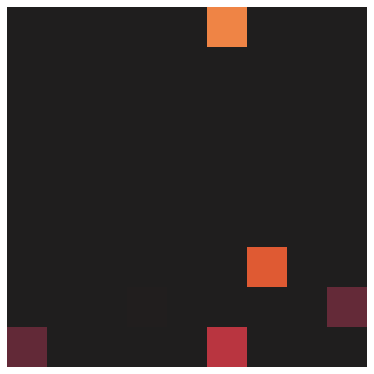

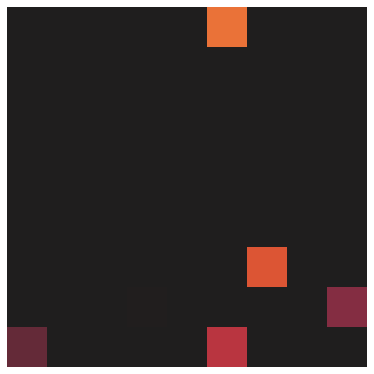

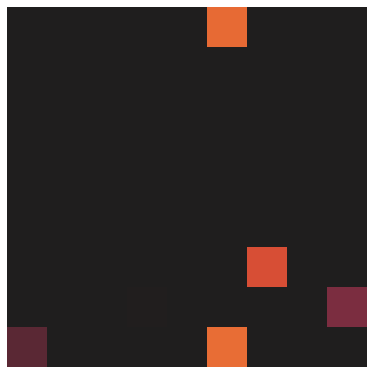

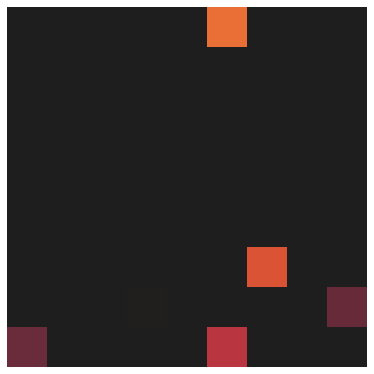

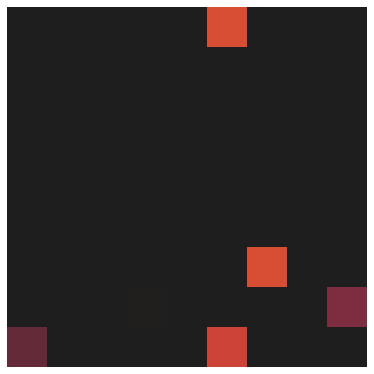

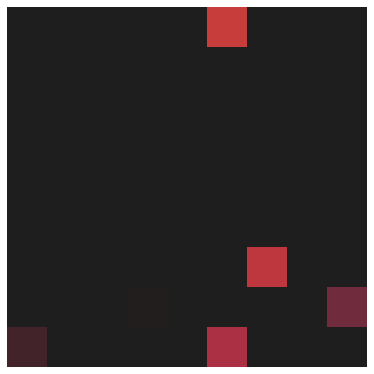

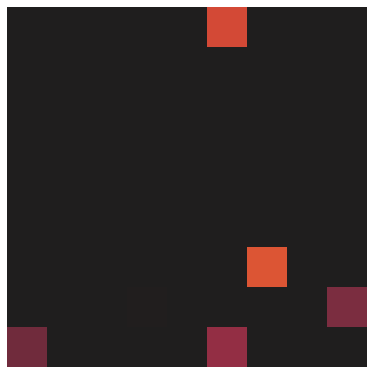

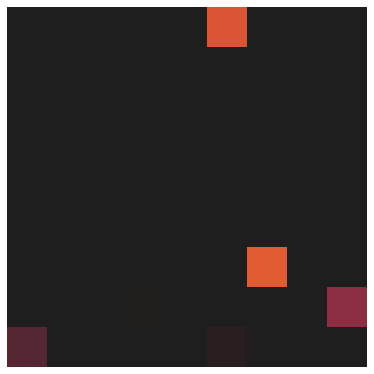

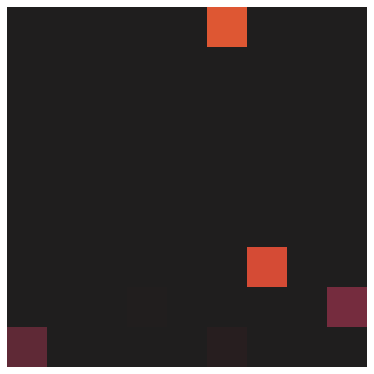

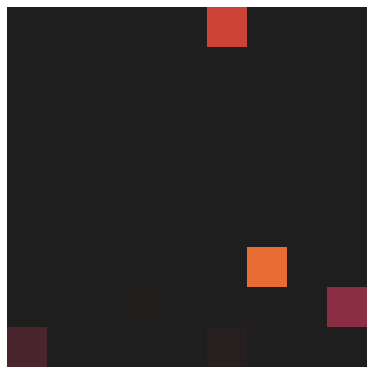

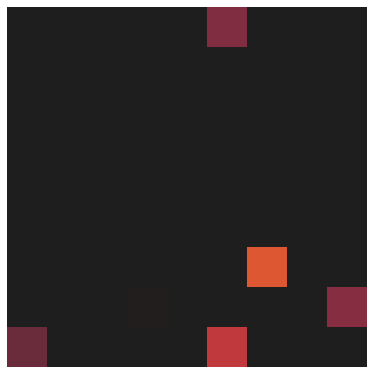

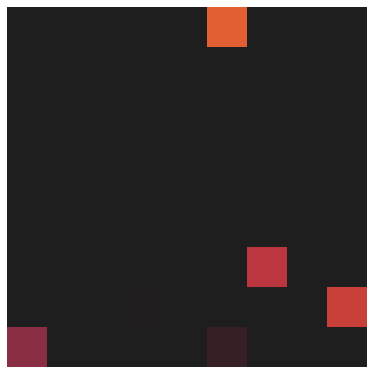

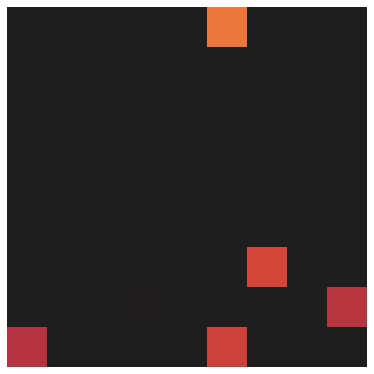

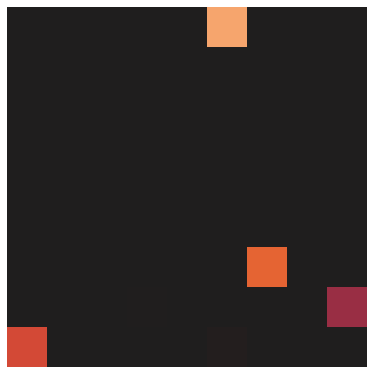

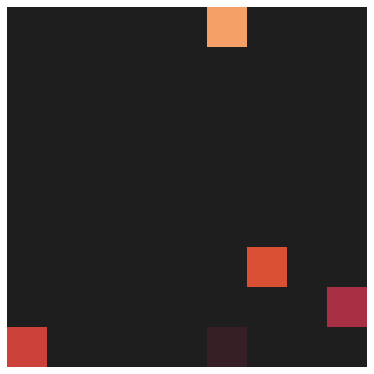

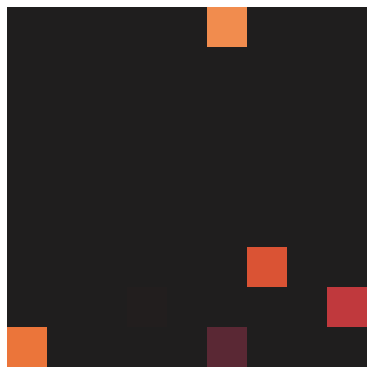

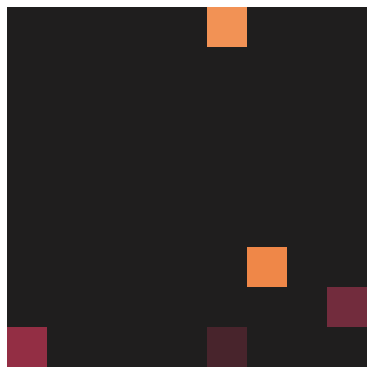

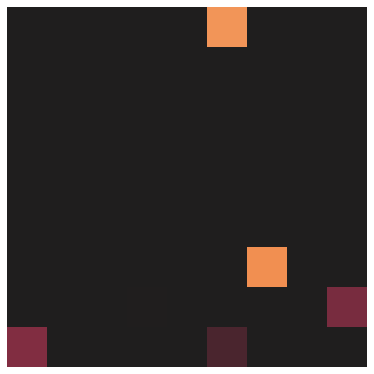

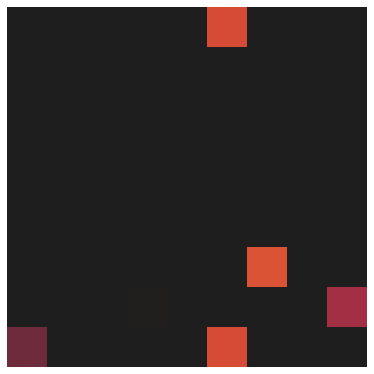

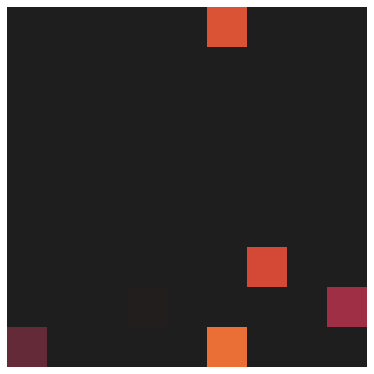

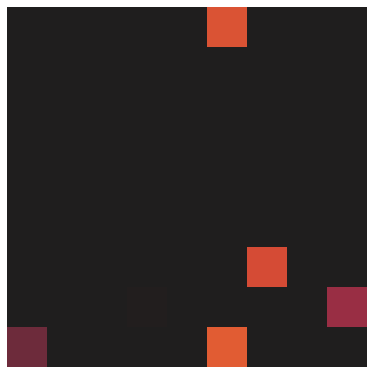

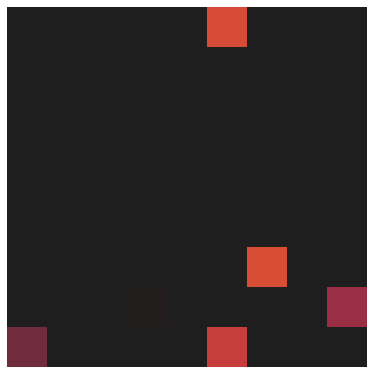

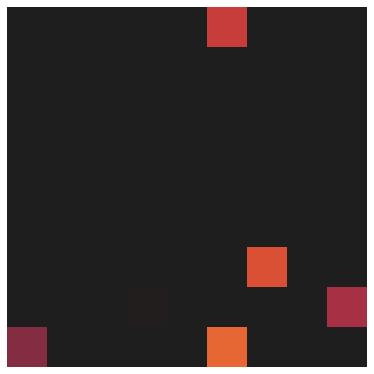

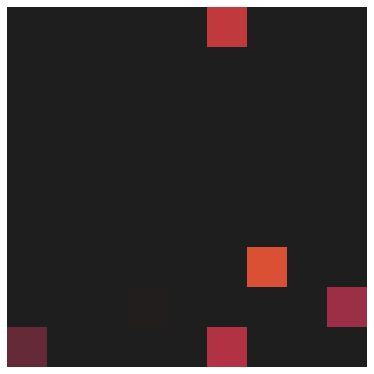

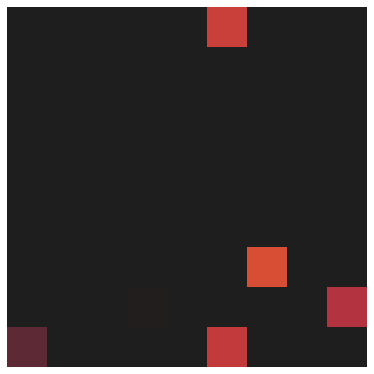

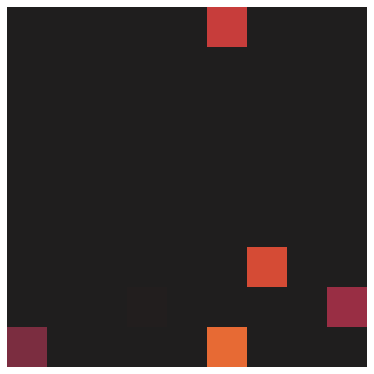

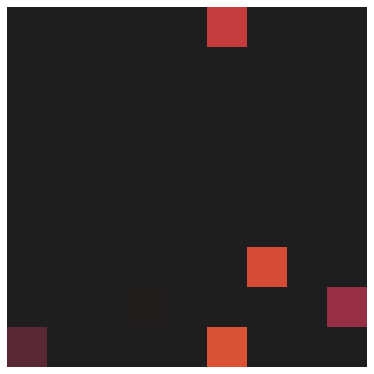

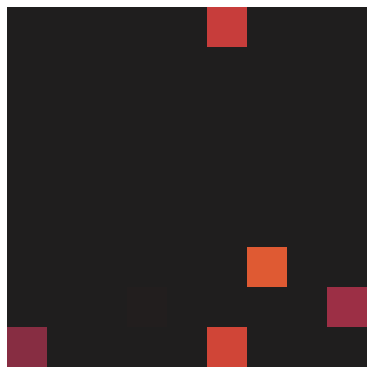

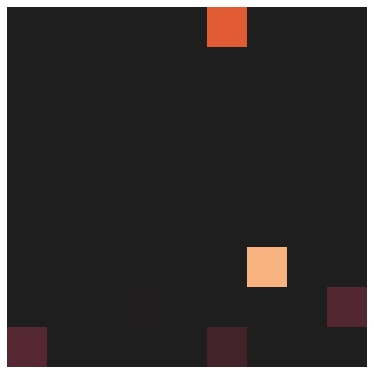

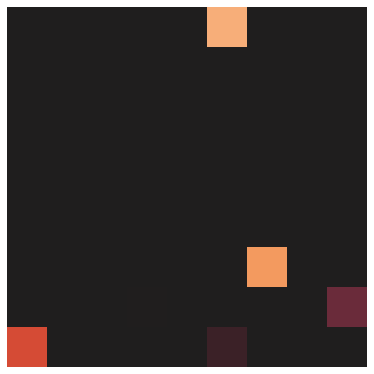

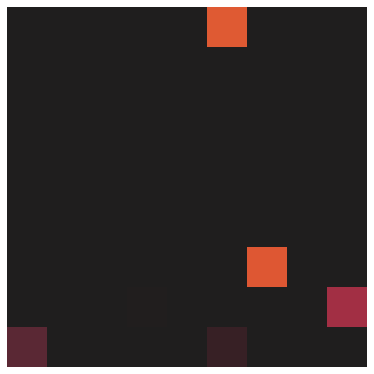

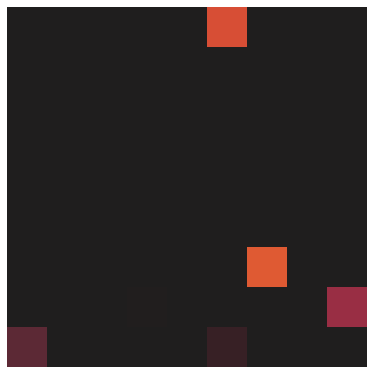

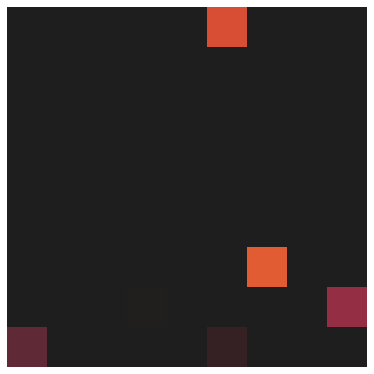

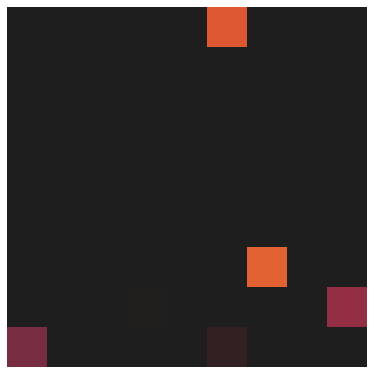

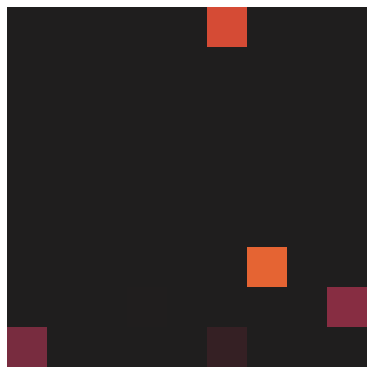

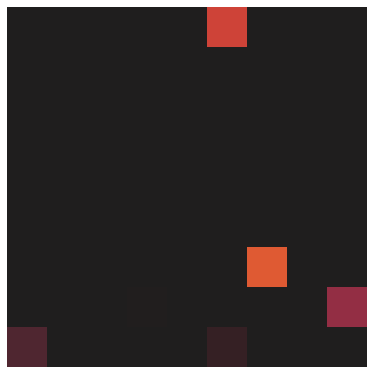

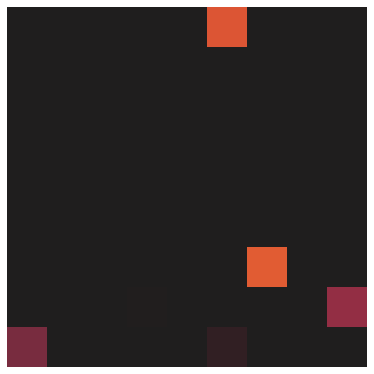

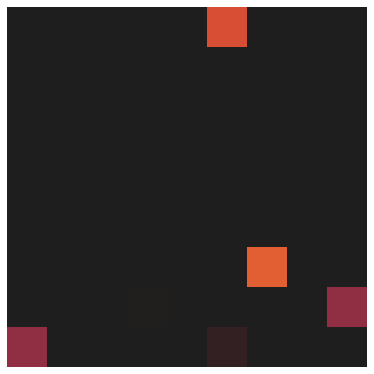

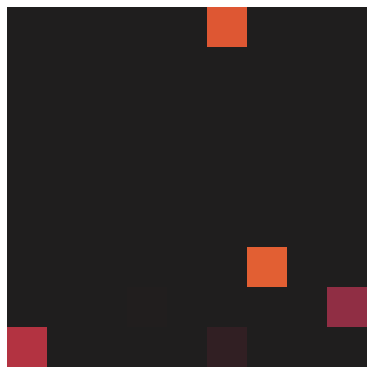

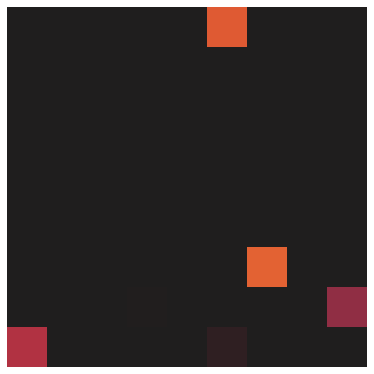

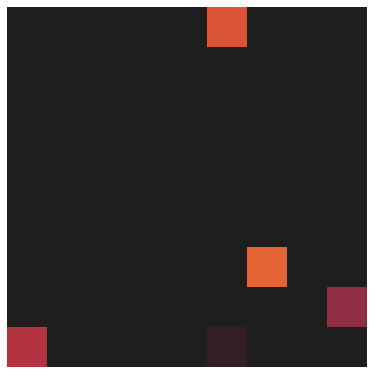

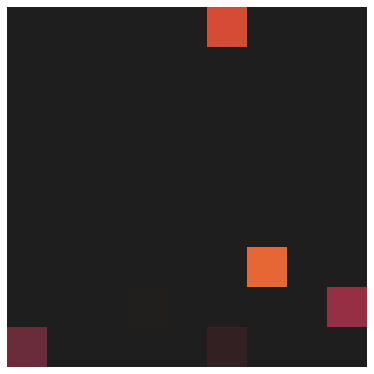

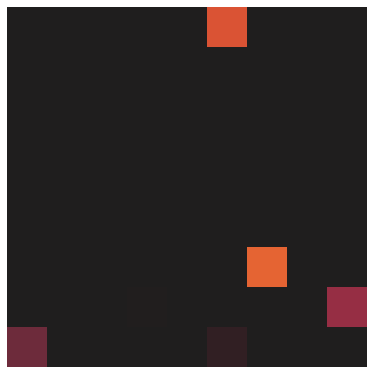

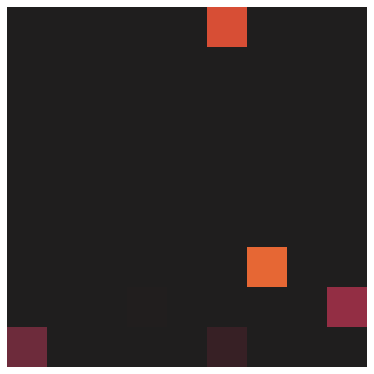

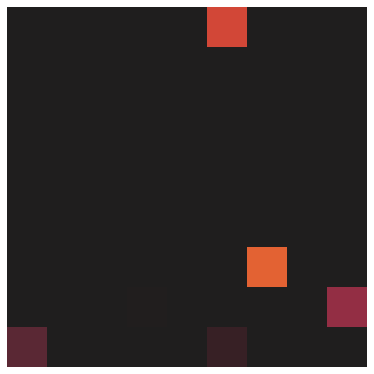

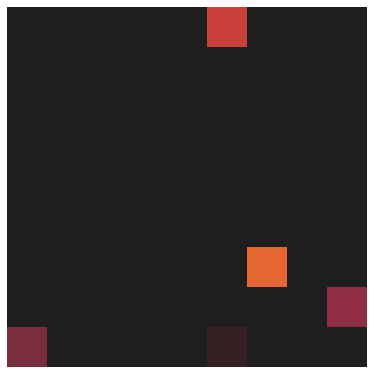

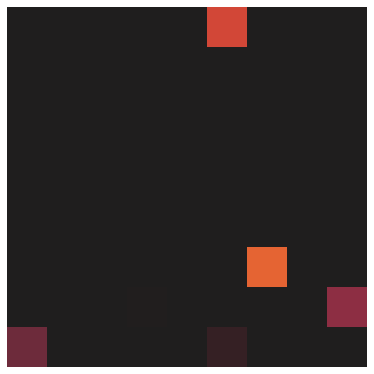

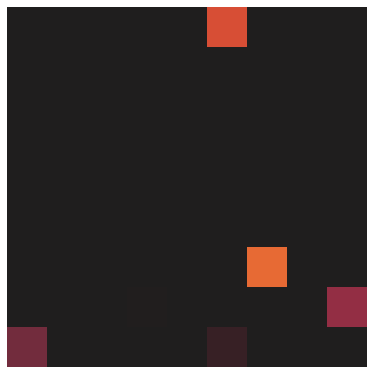

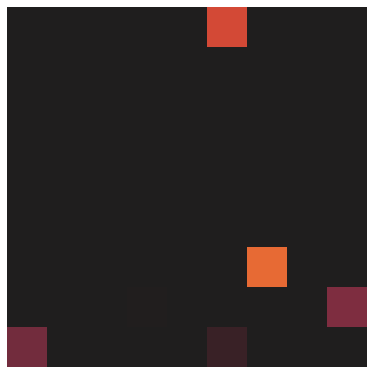

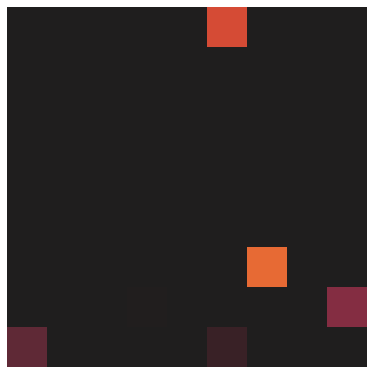

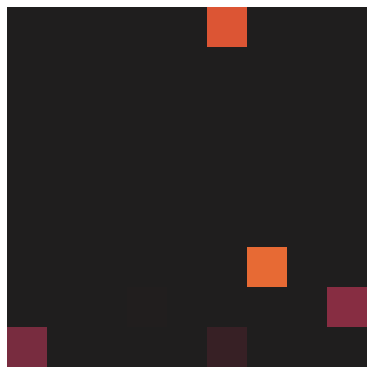

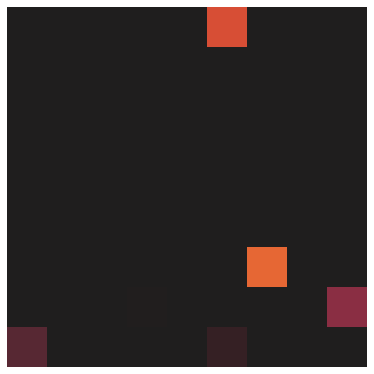

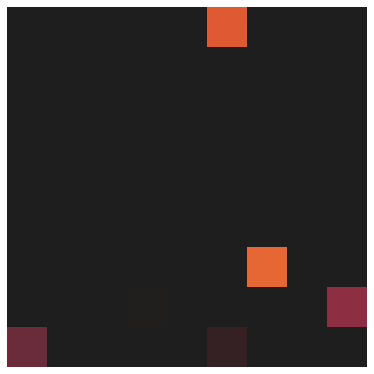

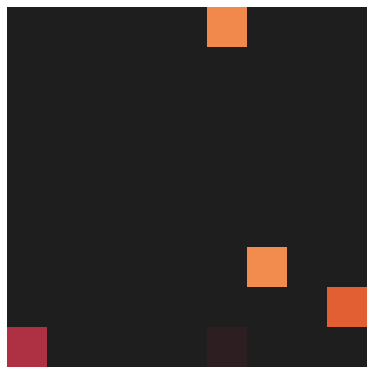

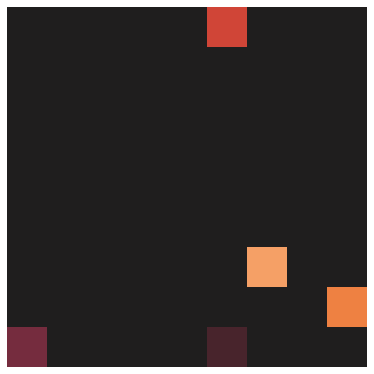

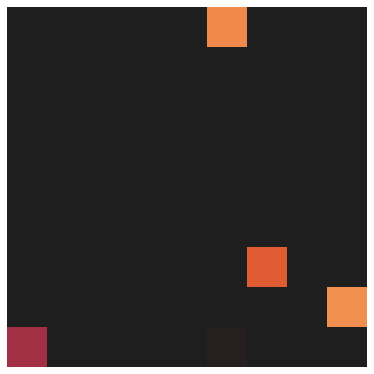

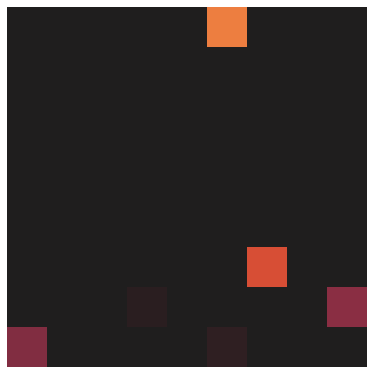

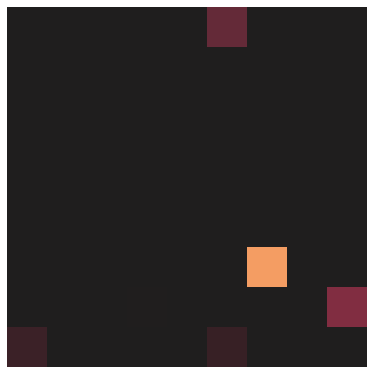

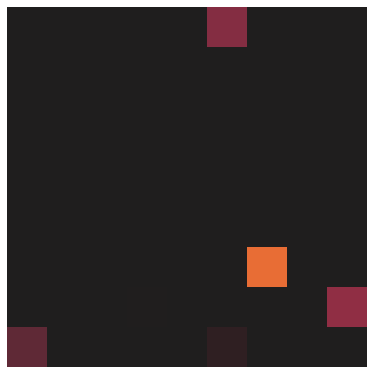

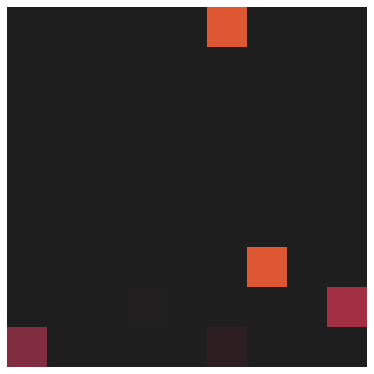

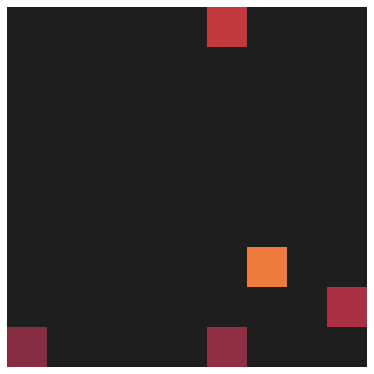

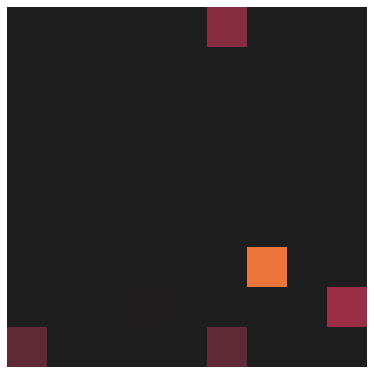

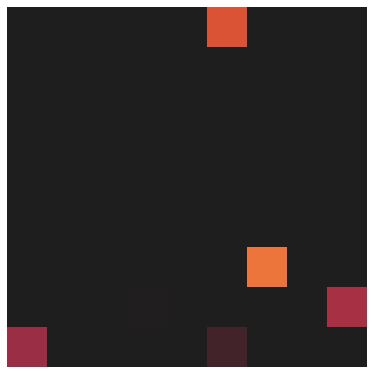

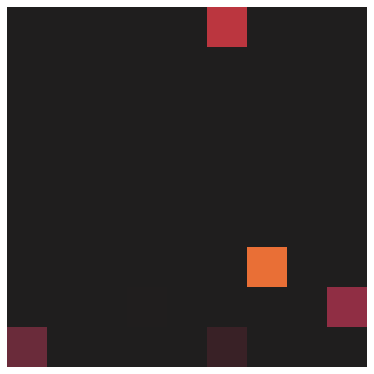

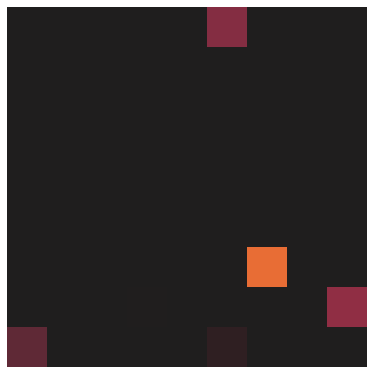

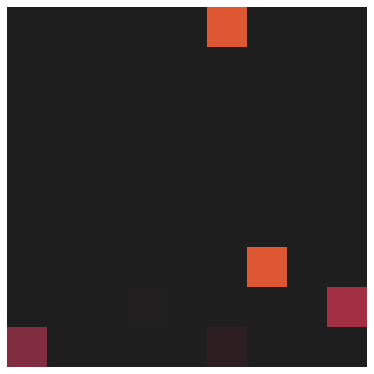

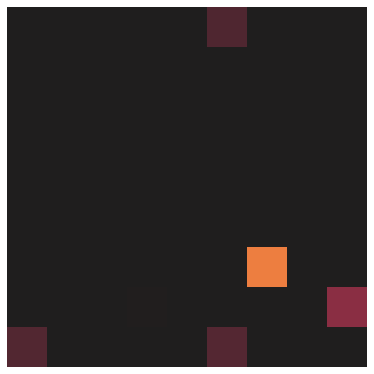

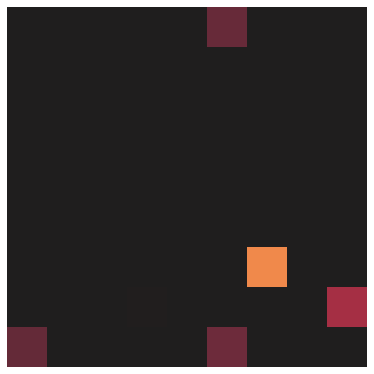

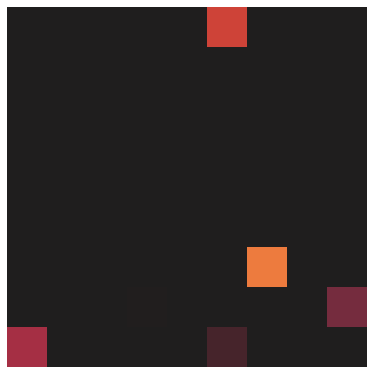

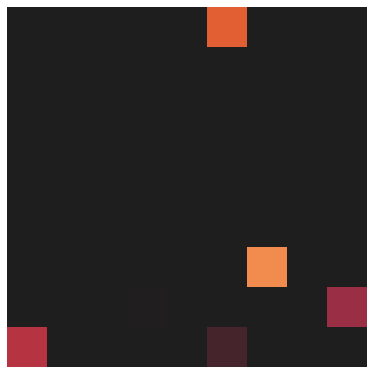

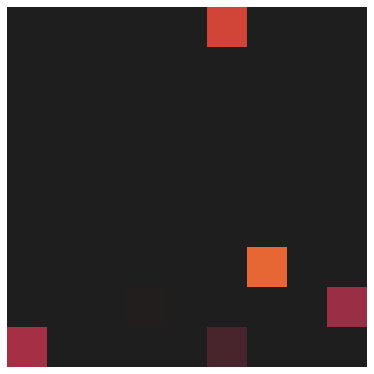

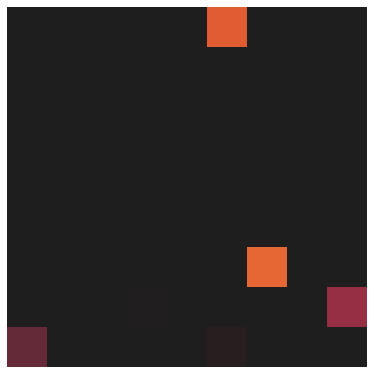

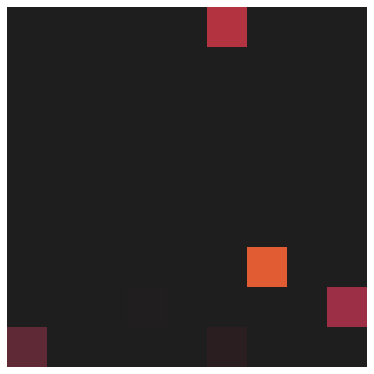

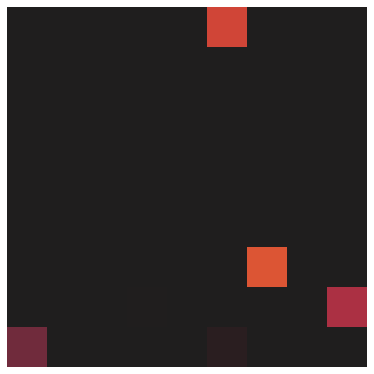

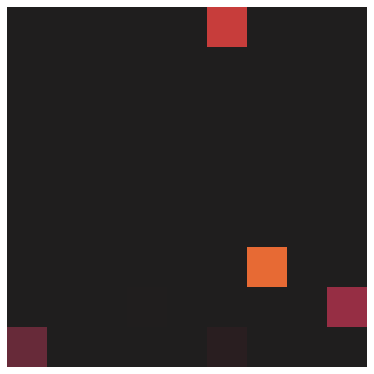

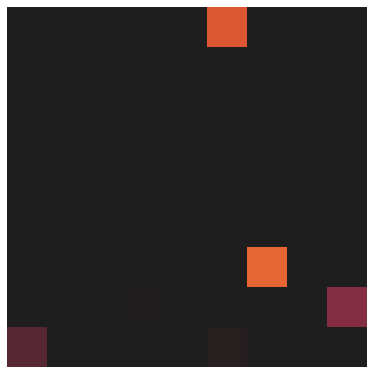

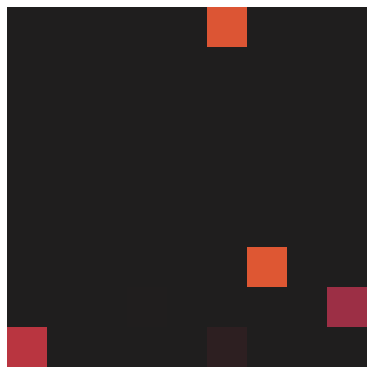

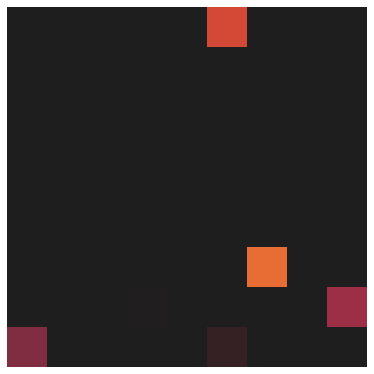

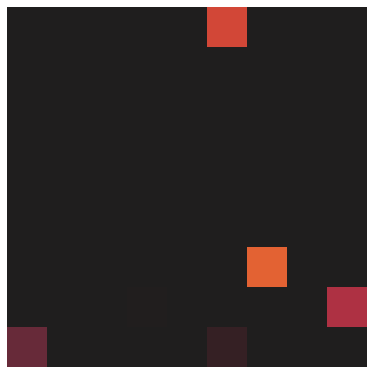

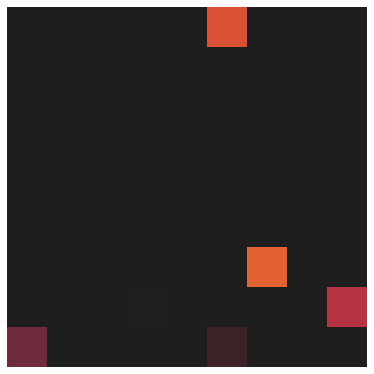

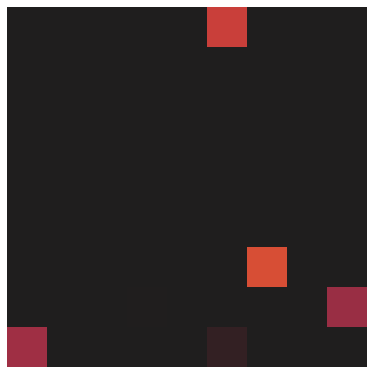

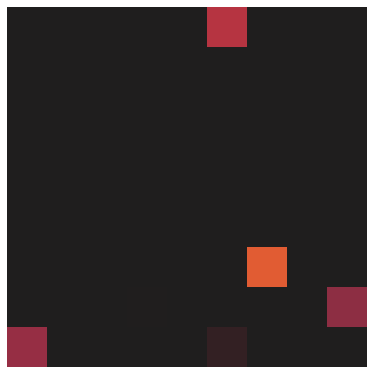

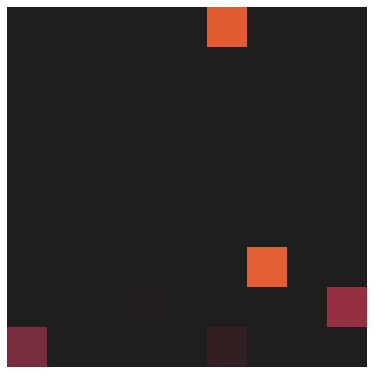

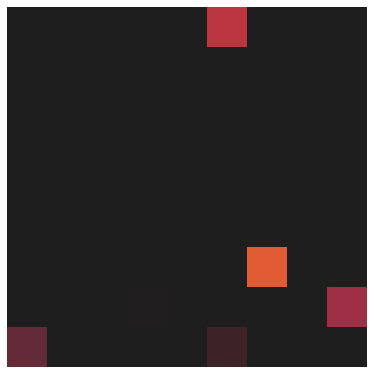

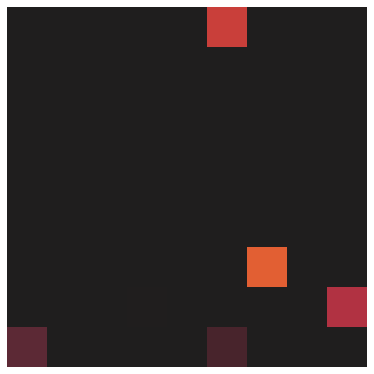

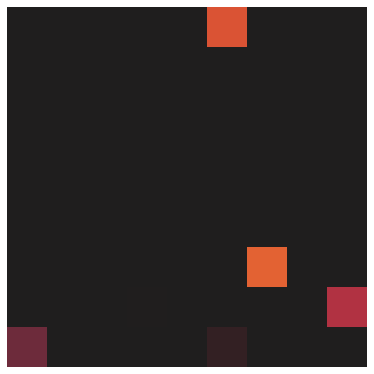

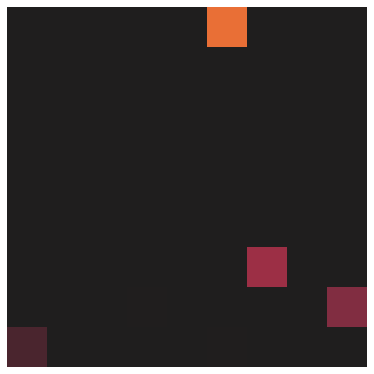

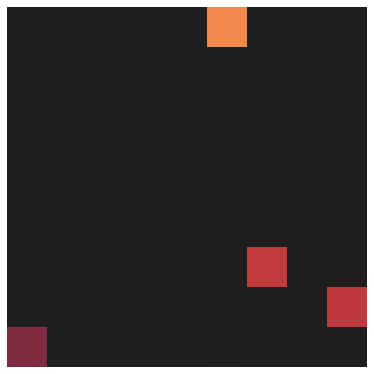

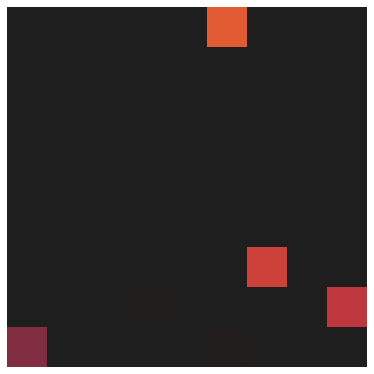

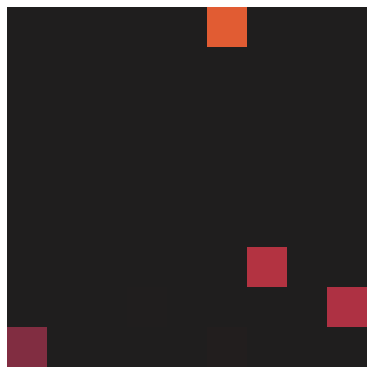

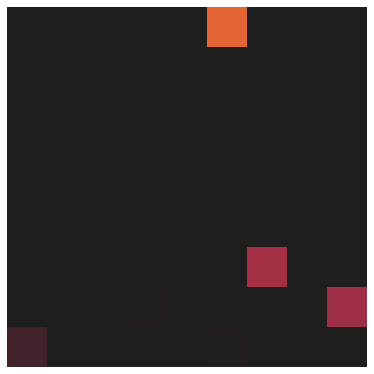

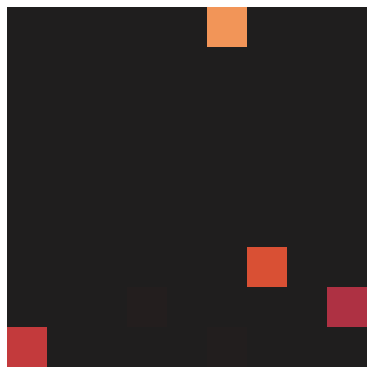

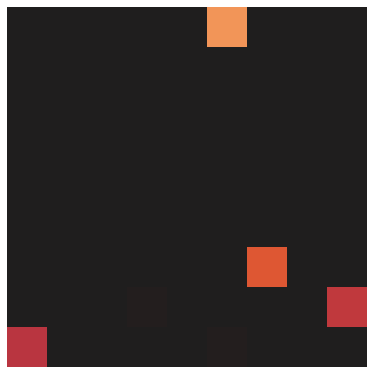

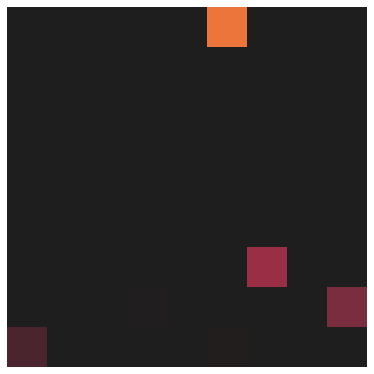

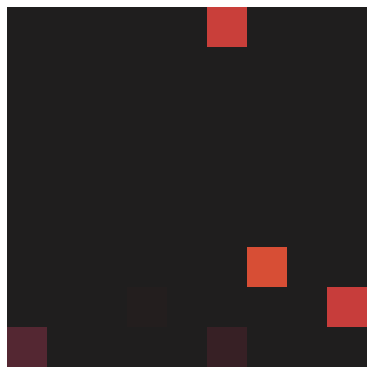

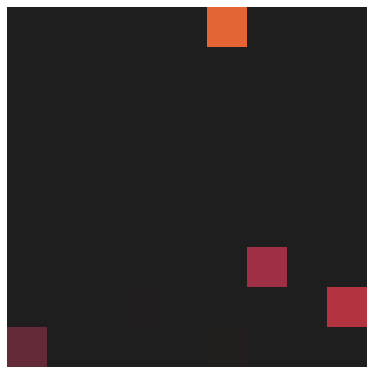

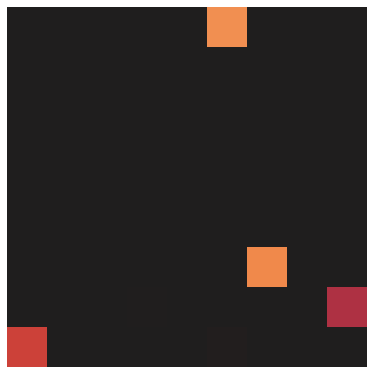

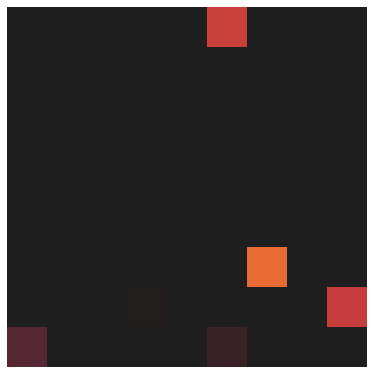

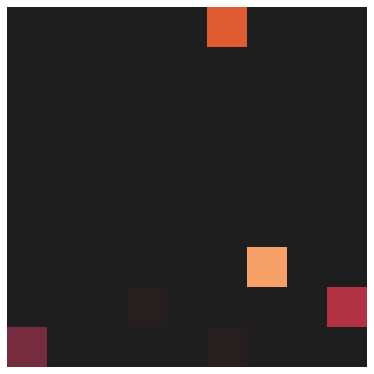

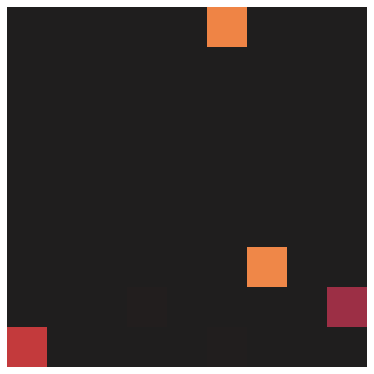

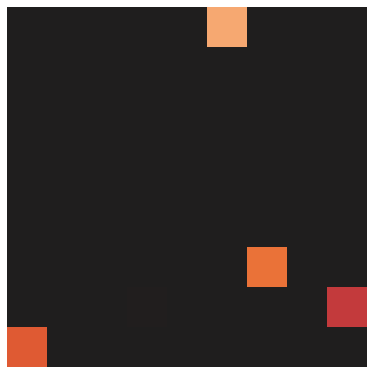

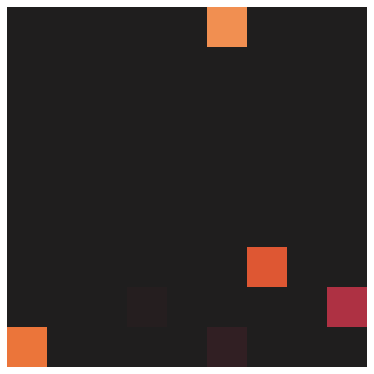

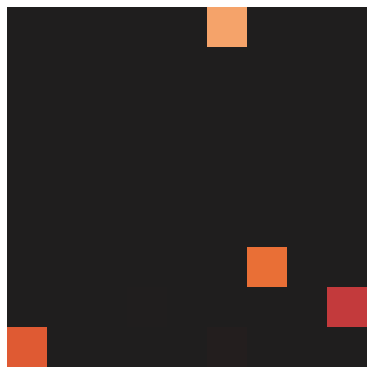

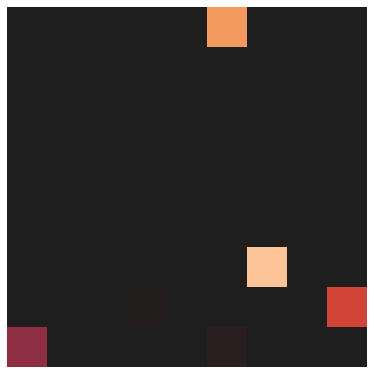

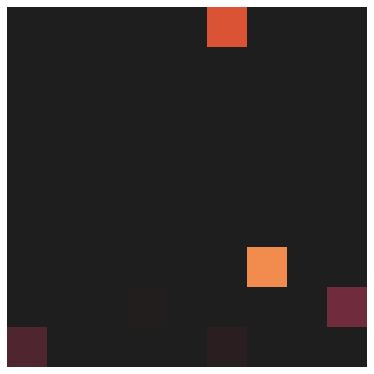

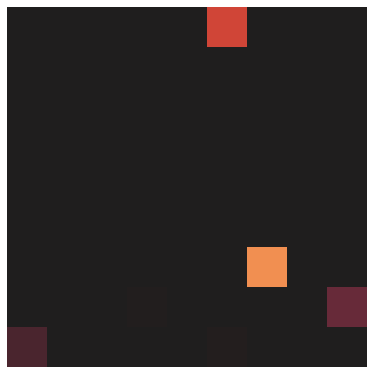

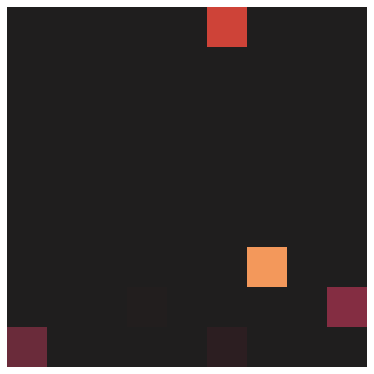

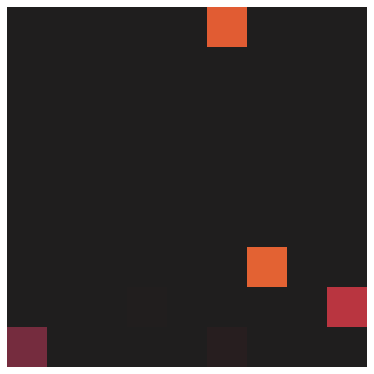

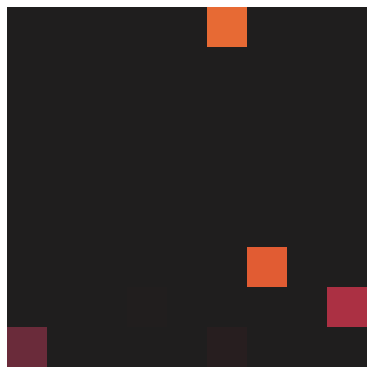

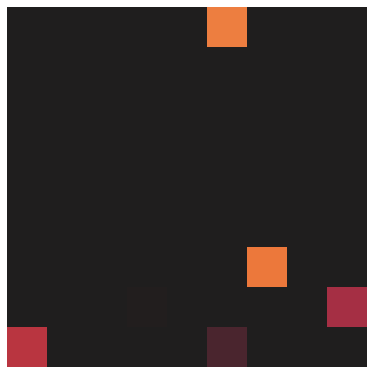

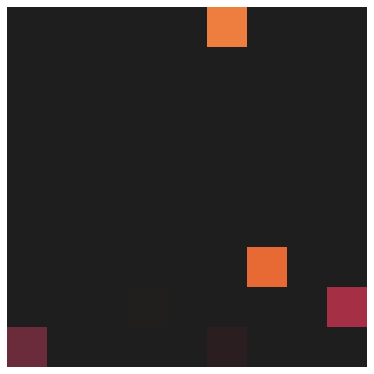

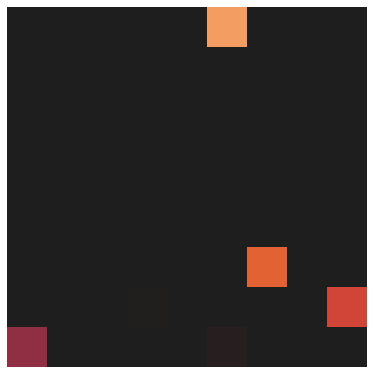

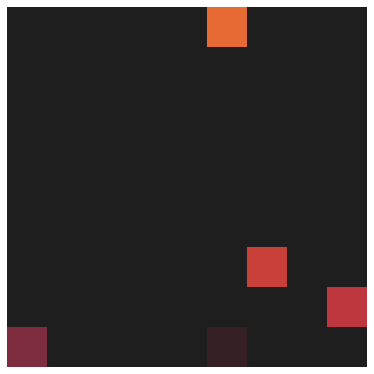

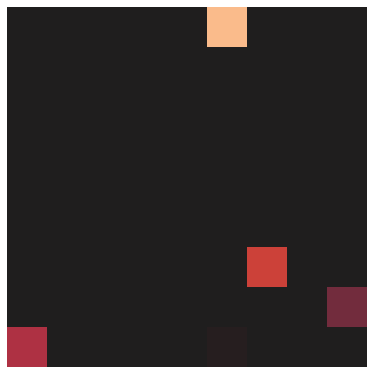

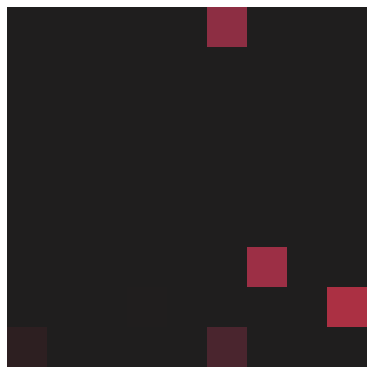

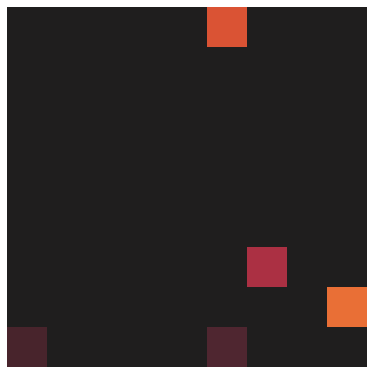

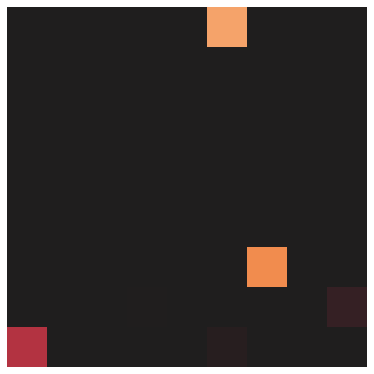

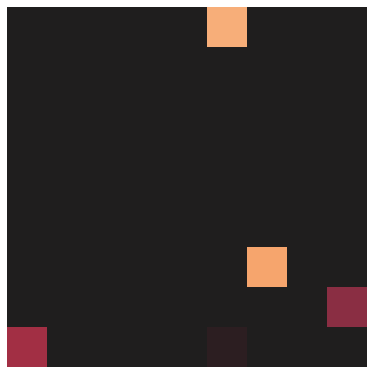

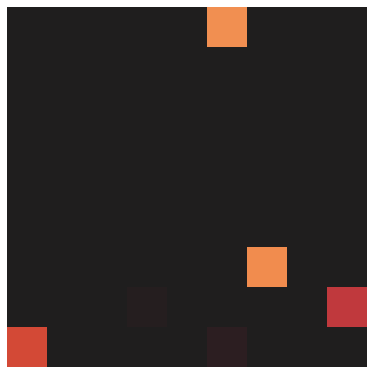

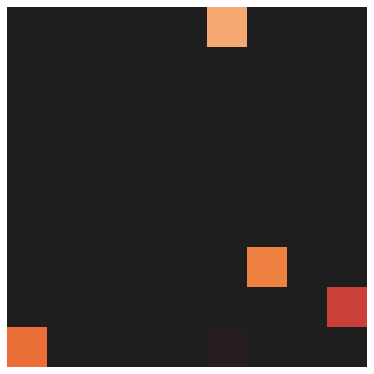

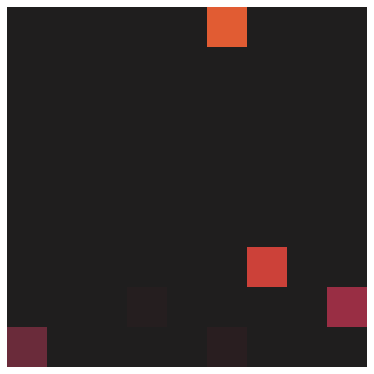

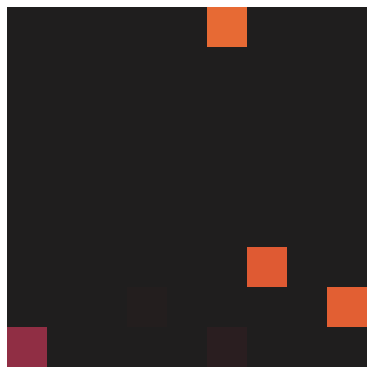

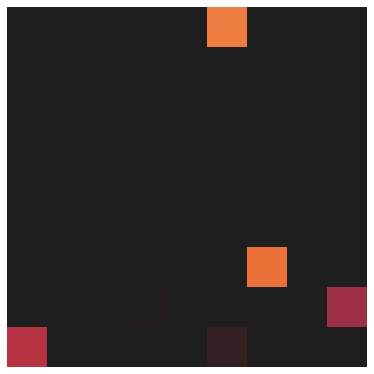

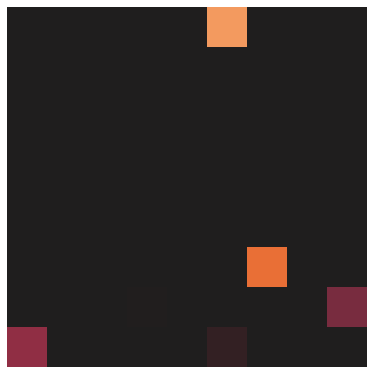

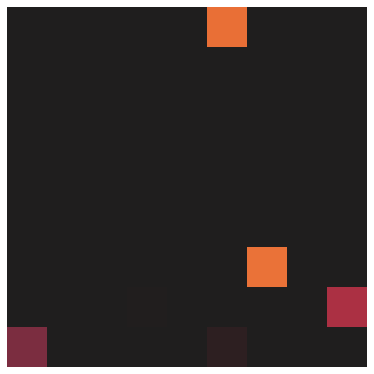

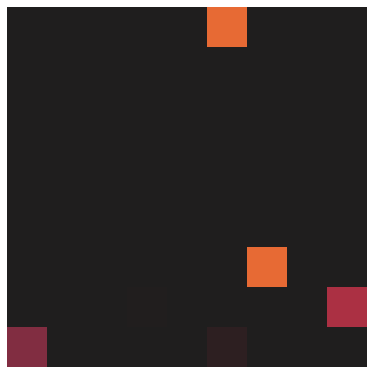

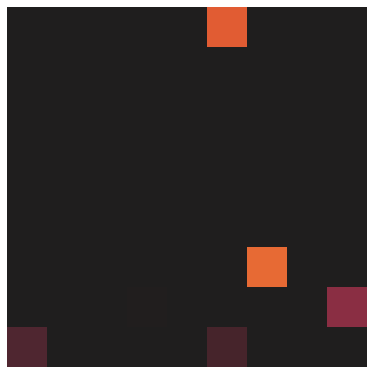

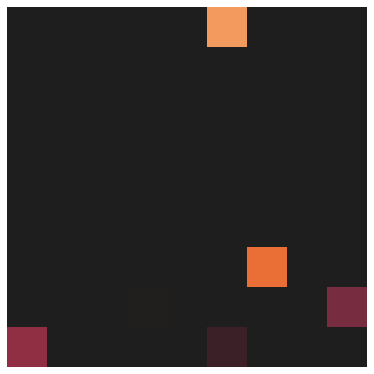

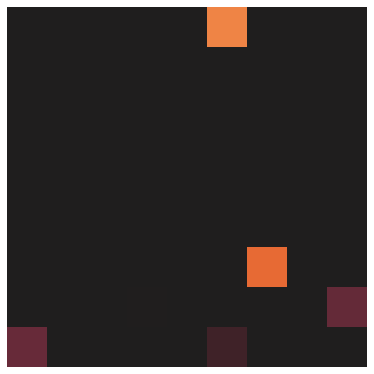

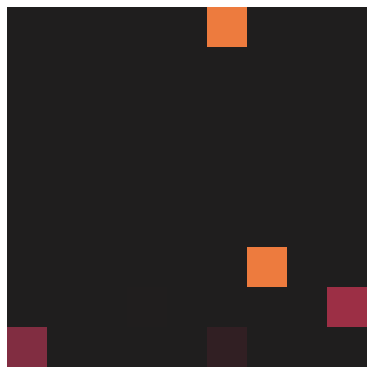

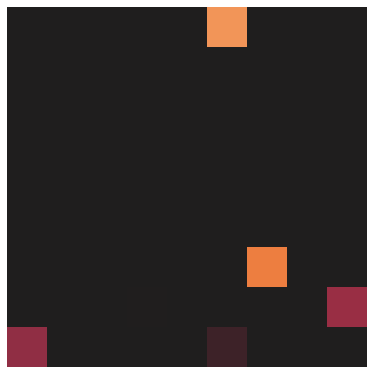

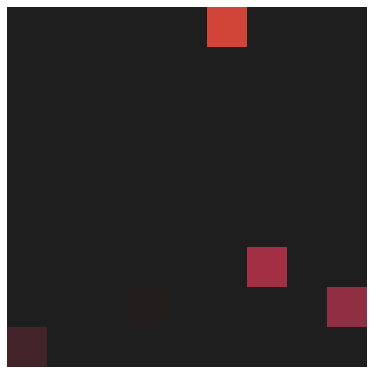

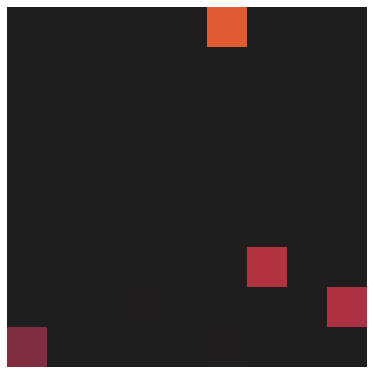

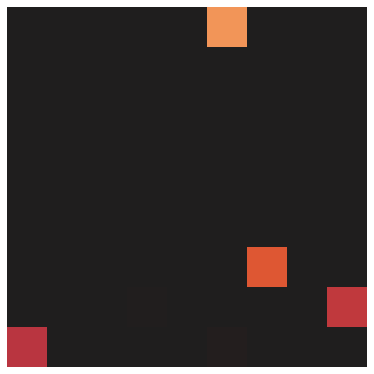

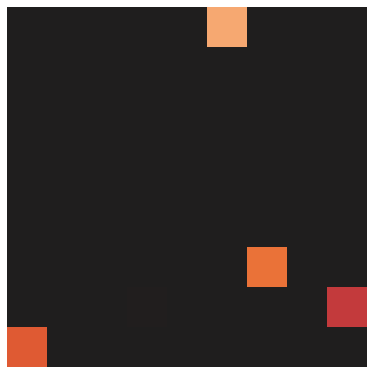

In [672]:
save_coal_image()

In [677]:
read_path = "Coal_images(2026_03_15)_coals/"
save_path = "Coal_images(2026_03_15)_coals_filpped/"
for filename in os.listdir(read_path):
    if filename != '.ipynb_checkpoints':
        img = cv2.imread(read_path+filename) 
        img = cv2.flip(img,0) #进行图像反转，和上面坐标的位置保持一致，好对应观察
        save_name = save_path + filename
        cv2.imwrite(save_name,img)